# 04 — Canonical Damaged-Image Generation

**Origin:** Existing Notebook 04  
**Refactor status:** In progress  
**Validation status:** Pending  
**Completion gate passed:** No  
**Output root:** `outputs/04_canonical_damaged_image_generation/`  
**Depends on:** Notebook 02 — Image Preprocessing; Notebook 03 — Canonical Mask Generation

## Purpose

Apply the canonical binary missing-region masks to the canonical clean images and produce the controlled damaged-image inputs used by downstream restoration experiments.

This notebook will:

- consume only the validated Notebook 02 and Notebook 03 handoffs;
- apply the configured constant-RGB canonical white fill;
- preserve every pixel outside the binary mask;
- preserve zero-control images as exact byte-for-byte copies of their clean sources;
- distinguish mask pixels from pixels that visibly change when a source pixel is already white;
- record normalized clean-image, mask, and damaged-image foreign keys;
- record fill strategy, fill parameters, paths, image metadata, and SHA-256 checksums;
- save one damaged RGB PNG per canonical case;
- reload and verify every generated output;
- reconcile observed mask and changed-pixel counts;
- detect missing, stale, duplicate, and orphaned outputs;
- produce one normalized case table and one per-case damage-integrity audit;
- produce a compact visual comparison of clean, mask, damaged, and changed-pixel panels;
- produce standardized validation, artifact-manifest, and run-manifest outputs.

## Canonical corruption strategy

The canonical baseline uses:

- strategy: `constant_rgb`;
- fill colour: RGB `(255, 255, 255)`;
- mask background value: `0`;
- mask damaged-region value: `255`;
- output mode: RGB;
- output format: PNG;
- output dimensions: 768 × 768.

For non-zero masks:

1. every unmasked output pixel must equal the clean source;
2. every masked output pixel must equal the configured white fill;
3. the observed binary-mask area must equal Notebook 03 metadata;
4. the expected visibly changed count equals the mask count minus masked source pixels that were already white.

For zero controls, the clean PNG is copied directly so pixel values and file checksums remain identical.

## Interpretation boundary

This notebook validates synthetic corruption construction. It does not calculate restoration-quality metrics such as PSNR, SSIM, LPIPS, feature similarity, seam quality, colour fidelity, or perceptual realism.

Those measurements belong to later restoration-evidence notebooks.

## Batch 1 — Contract, Initialization, and Output Preflight

This batch:

- initializes the notebook execution identity;
- loads the approved canonical-damage configuration;
- resolves all explicit Notebook 02 and Notebook 03 handoffs;
- loads the current project inventory and artifact registry;
- declares the complete input and output contracts;
- performs exactly 12 consolidated preflight checks;
- rejects incorrectly owned, legacy, stale, or undeclared outputs;
- creates only the required Notebook 04 output directories.

No damaged image, case table, audit, figure, validation CSV, or manifest is written in this batch.

In [1]:
from pathlib import Path
import json
import platform
import re
import sys

import pandas as pd
import PIL
import yaml


# ---------------------------------------------------------------------------
# Minimal import bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_CANDIDATES = [
    CURRENT_DIRECTORY,
    *CURRENT_DIRECTORY.parents,
]

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in PROJECT_ROOT_CANDIDATES
    if (
        (candidate / ".git").exists()
        and (candidate / "src" / "restoration_eval").is_dir()
        and (candidate / "notebooks").is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration repository root "
        f"from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import __version__ as PACKAGE_VERSION

from restoration_eval.damage import (
    CANONICAL_DAMAGE_CONFIG_SCHEMA_VERSION,
    DAMAGE_MODULE_VERSION,
    GENERATOR_VERSION,
    SUPPORTED_MASK_TYPES,
    load_damage_config,
    resolve_damage_inputs,
    validate_damage_config,
)

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.paths import (
    INVENTORY_RUN_PATH,
    PATHS_MODULE_VERSION,
    PROJECT_FILE_INVENTORY_PATH,
    PROJECT_PATHS_JSON_PATH,
    PROJECT_PATHS_MARKDOWN_PATH,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    require_notebook_output_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    CANONICAL_DAMAGE_AUDIT_SCHEMA,
    CANONICAL_DAMAGE_CASES_SCHEMA,
    CANONICAL_MASKS_SCHEMA,
    PREPROCESSED_IMAGES_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    VALIDATION_CHECKS_SCHEMA,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook execution identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "04"
NOTEBOOK_STEM = "04_canonical_damaged_image_generation"
NOTEBOOK_NAME = "Canonical Damaged-Image Generation"
ORIGIN = "Existing Notebook 04"

PREPROCESSING_NOTEBOOK_STEM = "02_image_preprocessing"
MASK_NOTEBOOK_STEM = "03_canonical_mask_generation"

RUN_STARTED_AT_UTC = utc_now_iso()

SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}

HELPER_VERSIONS = {
    "restoration_eval": PACKAGE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
    "damage": DAMAGE_MODULE_VERSION,
}

print("Notebook:", f"{NOTEBOOK_ID} - {NOTEBOOK_NAME}")
print("Repository root:", PROJECT_ROOT)
print("Run started:", RUN_STARTED_AT_UTC)
print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("Pillow:", PIL.__version__)
print("PyYAML:", yaml.__version__)
print("Damage generator:", GENERATOR_VERSION)

Notebook: 04 - Canonical Damaged-Image Generation
Repository root: D:\Masters\FH\Thesis\painting-restoration-eval
Run started: 2026-08-18T21:46:34.439296Z
Python: 3.12.6
pandas: 2.3.3
Pillow: 9.5.0
PyYAML: 6.0.3
Damage generator: 3.0.0


In [2]:
# ---------------------------------------------------------------------------
# Approved configuration and explicit Notebook 02/03 paths
# ---------------------------------------------------------------------------

DAMAGE_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiments"
    / "canonical_damage.yaml"
)

damage_config = load_damage_config(
    DAMAGE_CONFIG_PATH
)

damage_input_paths = resolve_damage_inputs(
    damage_config,
    PROJECT_ROOT,
    must_exist=True,
)

UPSTREAM_GEOMETRY_PATH = (
    damage_input_paths["geometry_path"]
)

UPSTREAM_CLEAN_IMAGE_DIRECTORY = (
    damage_input_paths["clean_images_path"]
)

PREPROCESSING_ARTIFACT_MANIFEST_PATH = (
    damage_input_paths[
        "preprocessing_artifacts_path"
    ]
)

PREPROCESSING_RUN_MANIFEST_PATH = (
    damage_input_paths[
        "preprocessing_run_manifest_path"
    ]
)

UPSTREAM_MASKS_PATH = (
    damage_input_paths["masks_path"]
)

UPSTREAM_MASK_IMAGE_DIRECTORY = (
    damage_input_paths["mask_images_path"]
)

MASK_ARTIFACT_MANIFEST_PATH = (
    damage_input_paths["masks_artifacts_path"]
)

MASK_RUN_MANIFEST_PATH = (
    damage_input_paths["masks_run_manifest_path"]
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "04_canonical_damaged_image_generation.ipynb"
)


# ---------------------------------------------------------------------------
# Current inventory and global artifact registry
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    PROJECT_FILE_INVENTORY_PATH,
    low_memory=False,
)

with INVENTORY_RUN_PATH.open(
    "r",
    encoding="utf-8-sig",
) as inventory_run_file:
    inventory_run = json.load(
        inventory_run_file
    )

project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)


# ---------------------------------------------------------------------------
# Notebook-owned output paths
# ---------------------------------------------------------------------------

OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

DAMAGED_IMAGE_DIRECTORY = (
    OUTPUT_ROOT
    / damage_config["output"]["image_directory"]
)

OUTPUT_PATHS = {
    "canonical_damage_cases": (
        OUTPUT_ROOT
        / damage_config["output"]["cases_path"]
    ),
    "damaged_images": DAMAGED_IMAGE_DIRECTORY,
    "damage_audit": (
        OUTPUT_ROOT
        / damage_config["output"]["audit_path"]
    ),
    "damage_examples_figure": (
        OUTPUT_ROOT
        / damage_config["output"][
            "examples_figure_path"
        ]
    ),
    "validation_checks": (
        OUTPUT_ROOT
        / "validation"
        / "checks.csv"
    ),
    "artifact_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "artifacts.csv"
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "run_manifest.json"
    ),
}

POST_GATE_PATHS = {
    "project_paths_json": (
        PROJECT_PATHS_JSON_PATH
    ),
    "project_paths_markdown": (
        PROJECT_PATHS_MARKDOWN_PATH
    ),
}


# ---------------------------------------------------------------------------
# Expected controlled-experiment cardinalities
# ---------------------------------------------------------------------------

EXPECTED_PAINTING_COUNT = int(
    damage_config["expected"]["painting_count"]
)

EXPECTED_MASK_TYPE_COUNT = int(
    damage_config["expected"]["mask_type_count"]
)

EXPECTED_CASE_COUNT = int(
    damage_config["expected"]["case_count"]
)

EXPECTED_AUDIT_ROW_COUNT = int(
    damage_config["expected"]["audit_row_count"]
)

EXPECTED_ARTIFACT_RECORD_COUNT = int(
    damage_config["expected"][
        "artifact_record_count"
    ]
)

EXPECTED_MASK_TYPES = tuple(
    damage_config["expected"]["mask_types"]
)


# ---------------------------------------------------------------------------
# Complete explicit input contract
# ---------------------------------------------------------------------------

INPUTS = {
    "canonical_damage_config": {
        "producer": "project configuration",
        "relative_path": to_repo_relative(
            DAMAGE_CONFIG_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "yaml",
        "schema_version": (
            CANONICAL_DAMAGE_CONFIG_SCHEMA_VERSION
        ),
        "expected_cardinality": 1,
    },
    "preprocessed_images": {
        "producer": PREPROCESSING_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            UPSTREAM_GEOMETRY_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            PREPROCESSED_IMAGES_SCHEMA.version
        ),
        "expected_cardinality": (
            EXPECTED_PAINTING_COUNT
        ),
    },
    "clean_images": {
        "producer": PREPROCESSING_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            UPSTREAM_CLEAN_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "png_collection",
        "schema_version": (
            "clean_image_collection.v1"
        ),
        "expected_cardinality": (
            EXPECTED_PAINTING_COUNT
        ),
    },
    "preprocessing_artifact_manifest": {
        "producer": PREPROCESSING_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            PREPROCESSING_ARTIFACT_MANIFEST_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            ARTIFACT_MANIFEST_SCHEMA.version
        ),
        "expected_cardinality": 5,
    },
    "preprocessing_run_manifest": {
        "producer": PREPROCESSING_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            PREPROCESSING_RUN_MANIFEST_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "run_manifest.v1",
        "expected_cardinality": 1,
    },
    "canonical_masks": {
        "producer": MASK_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            UPSTREAM_MASKS_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            CANONICAL_MASKS_SCHEMA.version
        ),
        "expected_cardinality": (
            EXPECTED_CASE_COUNT
        ),
    },
    "canonical_mask_images": {
        "producer": MASK_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            UPSTREAM_MASK_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "png_collection",
        "schema_version": (
            "canonical_mask_collection.v1"
        ),
        "expected_cardinality": (
            EXPECTED_CASE_COUNT
        ),
    },
    "mask_artifact_manifest": {
        "producer": MASK_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            MASK_ARTIFACT_MANIFEST_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            ARTIFACT_MANIFEST_SCHEMA.version
        ),
        "expected_cardinality": 7,
    },
    "mask_run_manifest": {
        "producer": MASK_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            MASK_RUN_MANIFEST_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "run_manifest.v1",
        "expected_cardinality": 1,
    },
    "project_inventory": {
        "producer": (
            "tools/build_project_inventory.py"
        ),
        "relative_path": to_repo_relative(
            PROJECT_FILE_INVENTORY_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            "project_file_inventory.v1"
        ),
        "expected_cardinality": len(
            inventory_df
        ),
    },
    "inventory_run": {
        "producer": (
            "tools/build_project_inventory.py"
        ),
        "relative_path": to_repo_relative(
            INVENTORY_RUN_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "inventory_run.v1",
        "expected_cardinality": 1,
    },
    "project_paths_registry": {
        "producer": (
            "validated notebook handoffs"
        ),
        "relative_path": to_repo_relative(
            PROJECT_PATHS_JSON_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "project_paths.v1",
        "expected_cardinality": 1,
    },
}


# ---------------------------------------------------------------------------
# Complete explicit output contract
# ---------------------------------------------------------------------------

OUTPUTS = {
    "canonical_damage_cases": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS[
                "canonical_damage_cases"
            ],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": (
            CANONICAL_DAMAGE_CASES_SCHEMA.version
        ),
        "expected_cardinality": (
            EXPECTED_CASE_COUNT
        ),
        "artifact_role": "primary_downstream",
    },
    "damaged_images": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["damaged_images"],
            PROJECT_ROOT,
        ),
        "format": "png_collection",
        "schema_version": (
            "canonical_damaged_image_collection.v1"
        ),
        "expected_cardinality": (
            EXPECTED_CASE_COUNT
        ),
        "artifact_role": "primary_downstream",
    },
    "damage_audit": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["damage_audit"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": (
            CANONICAL_DAMAGE_AUDIT_SCHEMA.version
        ),
        "expected_cardinality": (
            EXPECTED_AUDIT_ROW_COUNT
        ),
        "artifact_role": "audit_reporting",
    },
    "damage_examples_figure": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS[
                "damage_examples_figure"
            ],
            PROJECT_ROOT,
        ),
        "format": "png",
        "schema_version": (
            "figure.damage_examples.v1"
        ),
        "expected_cardinality": 1,
        "artifact_role": "qa_reporting",
    },
    "validation_checks": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["validation_checks"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": (
            VALIDATION_CHECKS_SCHEMA.version
        ),
        "expected_cardinality": (
            "one row per unique accumulated check"
        ),
        "artifact_role": "validation",
    },
    "artifact_manifest": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["artifact_manifest"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": (
            ARTIFACT_MANIFEST_SCHEMA.version
        ),
        "expected_cardinality": (
            EXPECTED_ARTIFACT_RECORD_COUNT
        ),
        "artifact_role": "handoff",
    },
    "run_manifest": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["run_manifest"],
            PROJECT_ROOT,
        ),
        "format": "json",
        "schema_version": "run_manifest.v1",
        "expected_cardinality": 1,
        "artifact_role": "reproducibility",
    },
}


print(
    "Dataset scope:",
    damage_config["dataset"]["dataset_scope"],
)

print(
    "Execution profile:",
    damage_config["dataset"][
        "execution_profile"
    ],
)

print(
    "Experiment:",
    damage_config["dataset"]["experiment_id"],
)

print(
    "Configuration version:",
    damage_config["config_version"],
)

print(
    "Fill strategy:",
    damage_config["generator"][
        "fill_strategy"
    ],
)

print(
    "Fill colour:",
    tuple(
        damage_config["generator"][
            "fill_color_rgb"
        ]
    ),
)

print(
    "Expected mask types:",
    EXPECTED_MASK_TYPES,
)

print(
    "Expected paintings:",
    EXPECTED_PAINTING_COUNT,
)

print(
    "Expected canonical cases:",
    EXPECTED_CASE_COUNT,
)

print(
    "Inventory run:",
    inventory_run["inventory_run_id"],
)

print(
    "Inventory records:",
    len(inventory_df),
)

print(
    "Registered artifacts:",
    len(
        project_paths_registry["artifacts"]
    ),
)

print(
    "Notebook output root:",
    OUTPUT_ROOT,
)

Dataset scope: controlled_50
Execution profile: controlled_50
Experiment: canonical_missing_region
Configuration version: 1.0.0
Fill strategy: constant_rgb
Fill colour: (255, 255, 255)
Expected mask types: ('zero_control', 'scratch_thin', 'loss_small', 'loss_large', 'mixed_damage')
Expected paintings: 50
Expected canonical cases: 250
Inventory run: inventory_20260818T214112Z_e0bf0c0a
Inventory records: 10772
Registered artifacts: 17
Notebook output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\04_canonical_damaged_image_generation


In [3]:
# ---------------------------------------------------------------------------
# Batch 1 preflight validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()


# 1. Repository root and notebook identity

root_passed = (
    (PROJECT_ROOT / ".git").exists()
    and (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
    ).is_dir()
    and (PROJECT_ROOT / "notebooks").is_dir()
    and NOTEBOOK_PATH.is_file()
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="project_root",
    check_description=(
        "Repository root and the correctly named "
        "Notebook 04 file exist."
    ),
    severity="blocking",
    expected=True,
    observed=root_passed,
    passed=root_passed,
    details=to_repo_relative(
        NOTEBOOK_PATH,
        PROJECT_ROOT,
    ),
)


# 2. Python version

python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

python_version_passed = (
    python_minor in SUPPORTED_PYTHON_MINORS
)

python_version_details = (
    "Python 3.11 is the provisional project default."
    if python_minor == (3, 11)
    else (
        "Python 3.12 is conditionally permitted; "
        "compatibility remains under validation."
        if python_minor == (3, 12)
        else "Unsupported Python minor version."
    )
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="python_version",
    check_description=(
        "Python minor version is supported for "
        "Notebook 04."
    ),
    severity=(
        "warning"
        if python_minor == (3, 12)
        else "blocking"
    ),
    expected=(
        "3.11 provisional; "
        "3.12 conditionally permitted"
    ),
    observed=platform.python_version(),
    passed=python_version_passed,
    details=python_version_details,
)


# 3. Canonical-damage configuration

damage_config_errors = (
    validate_damage_config(
        damage_config
    )
)

damage_config_passed = (
    not damage_config_errors
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="canonical_damage_config",
    check_description=(
        "Canonical damaged-image configuration "
        "satisfies canonical_damage_config.v1."
    ),
    severity="blocking",
    expected="zero configuration errors",
    observed=len(damage_config_errors),
    passed=damage_config_passed,
    details=damage_config_errors,
)


# 4. Inventory run and schema consistency

required_inventory_columns = {
    "inventory_schema_version",
    "inventory_run_id",
    "relative_path",
    "file_kind",
    "format",
    "size_bytes",
    "hash_mode",
    "hash_algorithm",
    "hash_value",
    "read_error_count",
}

missing_inventory_columns = sorted(
    required_inventory_columns
    - set(inventory_df.columns)
)

inventory_run_ids = (
    set(
        inventory_df["inventory_run_id"]
        .dropna()
        .astype(str)
    )
    if "inventory_run_id"
    in inventory_df.columns
    else set()
)

inventory_read_error_count = int(
    pd.to_numeric(
        inventory_df.get(
            "read_error_count",
            pd.Series(dtype="float64"),
        ),
        errors="coerce",
    )
    .fillna(0)
    .sum()
)

inventory_run_passed = (
    inventory_run.get("status")
    == "completed"
    and inventory_run.get(
        "inventory_schema_version"
    )
    == "project_file_inventory.v1"
    and inventory_run.get(
        "run_schema_version"
    )
    == "inventory_run.v1"
    and inventory_run_ids
    == {
        inventory_run[
            "inventory_run_id"
        ]
    }
    and not missing_inventory_columns
    and inventory_read_error_count == 0
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_run",
    check_description=(
        "Inventory run is completed, internally "
        "consistent, and contains no read errors."
    ),
    severity="blocking",
    expected={
        "status": "completed",
        "inventory_schema": (
            "project_file_inventory.v1"
        ),
        "run_schema": "inventory_run.v1",
        "read_errors": 0,
    },
    observed={
        "status": inventory_run.get(
            "status"
        ),
        "inventory_schema": (
            inventory_run.get(
                "inventory_schema_version"
            )
        ),
        "run_schema": inventory_run.get(
            "run_schema_version"
        ),
        "inventory_run_ids": sorted(
            inventory_run_ids
        ),
        "missing_columns": (
            missing_inventory_columns
        ),
        "read_errors": (
            inventory_read_error_count
        ),
    },
    passed=inventory_run_passed,
)


# 5. Inventory checksum

observed_inventory_checksum = (
    sha256_file(
        PROJECT_FILE_INVENTORY_PATH
    )
)

expected_inventory_checksum = (
    inventory_run.get(
        "inventory_sha256",
        "",
    )
)

inventory_checksum_passed = (
    observed_inventory_checksum
    == expected_inventory_checksum
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_checksum",
    check_description=(
        "Inventory CSV checksum matches its "
        "run manifest."
    ),
    severity="blocking",
    expected=expected_inventory_checksum,
    observed=observed_inventory_checksum,
    passed=inventory_checksum_passed,
)


# 6. Declared input and preparation coverage

known_inventory_paths = set(
    inventory_df["relative_path"]
    .dropna()
    .astype(str)
)

declared_inventory_files = {
    to_repo_relative(
        DAMAGE_CONFIG_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        UPSTREAM_GEOMETRY_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        PREPROCESSING_ARTIFACT_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        PREPROCESSING_RUN_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        UPSTREAM_MASKS_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        MASK_ARTIFACT_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        MASK_RUN_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        PROJECT_PATHS_JSON_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        NOTEBOOK_PATH,
        PROJECT_ROOT,
    ),
    "src/restoration_eval/damage.py",
    "src/restoration_eval/schemas.py",
    "src/restoration_eval/paths.py",
    "src/restoration_eval/manifests.py",
    "src/restoration_eval/validation.py",
    "tests/test_damage.py",
}

missing_declared_inventory_files = sorted(
    declared_inventory_files
    - known_inventory_paths
)

clean_image_prefix = (
    to_repo_relative(
        UPSTREAM_CLEAN_IMAGE_DIRECTORY,
        PROJECT_ROOT,
    ).rstrip("/")
    + "/"
)

mask_image_prefix = (
    to_repo_relative(
        UPSTREAM_MASK_IMAGE_DIRECTORY,
        PROJECT_ROOT,
    ).rstrip("/")
    + "/"
)

inventory_clean_image_paths = sorted(
    path
    for path in known_inventory_paths
    if (
        path.startswith(
            clean_image_prefix
        )
        and path.lower().endswith(
            ".png"
        )
    )
)

inventory_mask_image_paths = sorted(
    path
    for path in known_inventory_paths
    if (
        path.startswith(
            mask_image_prefix
        )
        and path.lower().endswith(
            ".png"
        )
    )
)

legacy_inventory_hits = sorted(
    path
    for path in known_inventory_paths
    if (
        path
        == "notebooks/04_damage_creation.ipynb"
        or path.startswith(
            "outputs/04_damage_creation/"
        )
        or path.startswith(
            "outputs/figures/damage_creation/"
        )
        or path.startswith(
            "outputs/reports/damage_creation_"
        )
        or path.startswith(
            "data/processed/masked/"
        )
        or path
        == (
            "data/processed/metadata/"
            "metadata_damaged_images.csv"
        )
    )
)

inventory_coverage_passed = (
    not missing_declared_inventory_files
    and len(
        inventory_clean_image_paths
    )
    == EXPECTED_PAINTING_COUNT
    and len(
        inventory_mask_image_paths
    )
    == EXPECTED_CASE_COUNT
    and not legacy_inventory_hits
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_input_coverage",
    check_description=(
        "Inventory contains every declared input, "
        "preparation file, clean image, and mask "
        "while excluding targeted Notebook 04 "
        "legacy artifacts."
    ),
    severity="blocking",
    expected={
        "missing_declared_files": 0,
        "clean_images": (
            EXPECTED_PAINTING_COUNT
        ),
        "mask_images": (
            EXPECTED_CASE_COUNT
        ),
        "legacy_hits": 0,
    },
    observed={
        "missing_declared_files": (
            missing_declared_inventory_files
        ),
        "clean_images": len(
            inventory_clean_image_paths
        ),
        "mask_images": len(
            inventory_mask_image_paths
        ),
        "legacy_hits": (
            legacy_inventory_hits
        ),
    },
    passed=inventory_coverage_passed,
    details=(
        "The generated inventory CSV and its run "
        "manifest are intentionally excluded from "
        "inventory self-indexing and are validated "
        "directly."
    ),
)


# 7. Project paths registry structure

registry_errors = (
    validate_project_paths_registry(
        project_paths_registry
    )
)

registry_passed = (
    not registry_errors
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="registry_schema",
    check_description=(
        "Global project paths registry satisfies "
        "project_paths.v1."
    ),
    severity="blocking",
    expected="zero registry errors",
    observed=len(registry_errors),
    passed=registry_passed,
    details=registry_errors,
)


# Shared ownership-check utility

def collect_ownership_errors(
    named_paths,
    expected_root,
):
    errors = []

    for input_key, input_path in (
        named_paths.items()
    ):
        try:
            input_path.resolve().relative_to(
                expected_root.resolve()
            )
        except ValueError:
            errors.append(
                {
                    "input_key": input_key,
                    "path": str(input_path),
                    "expected_parent": str(
                        expected_root
                    ),
                }
            )

    return errors


# 8. Notebook 02 input ownership

PREPROCESSING_OUTPUT_ROOT = (
    notebook_output_root(
        PREPROCESSING_NOTEBOOK_STEM,
        PROJECT_ROOT,
        create=False,
    )
)

preprocessing_ownership_errors = (
    collect_ownership_errors(
        {
            "preprocessed_images": (
                UPSTREAM_GEOMETRY_PATH
            ),
            "clean_images": (
                UPSTREAM_CLEAN_IMAGE_DIRECTORY
            ),
            "artifact_manifest": (
                PREPROCESSING_ARTIFACT_MANIFEST_PATH
            ),
            "run_manifest": (
                PREPROCESSING_RUN_MANIFEST_PATH
            ),
        },
        PREPROCESSING_OUTPUT_ROOT,
    )
)

VALIDATION.add(
    validation_stage="preflight",
    check_id=(
        "preprocessing_output_ownership"
    ),
    check_description=(
        "Every Notebook 02 handoff remains inside "
        "the Notebook 02 output root."
    ),
    severity="blocking",
    expected="zero ownership violations",
    observed=len(
        preprocessing_ownership_errors
    ),
    passed=(
        not preprocessing_ownership_errors
    ),
    details=preprocessing_ownership_errors,
)


# 9. Notebook 03 input ownership

MASK_OUTPUT_ROOT = notebook_output_root(
    MASK_NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

mask_ownership_errors = (
    collect_ownership_errors(
        {
            "canonical_masks": (
                UPSTREAM_MASKS_PATH
            ),
            "mask_images": (
                UPSTREAM_MASK_IMAGE_DIRECTORY
            ),
            "artifact_manifest": (
                MASK_ARTIFACT_MANIFEST_PATH
            ),
            "run_manifest": (
                MASK_RUN_MANIFEST_PATH
            ),
        },
        MASK_OUTPUT_ROOT,
    )
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="mask_output_ownership",
    check_description=(
        "Every Notebook 03 handoff remains inside "
        "the Notebook 03 output root."
    ),
    severity="blocking",
    expected="zero ownership violations",
    observed=len(mask_ownership_errors),
    passed=not mask_ownership_errors,
    details=mask_ownership_errors,
)


# 10. Required registered upstream artifacts

registry_records_by_key = {
    record["artifact_key"]: record
    for record in (
        project_paths_registry[
            "artifacts"
        ]
    )
}

required_registry_expectations = {
    "preprocessing.geometry": {
        "relative_path": to_repo_relative(
            UPSTREAM_GEOMETRY_PATH,
            PROJECT_ROOT,
        ),
        "schema_version": (
            PREPROCESSED_IMAGES_SCHEMA.version
        ),
        "row_count": (
            EXPECTED_PAINTING_COUNT
        ),
        "file_count": 1,
    },
    "preprocessing.clean_images": {
        "relative_path": to_repo_relative(
            UPSTREAM_CLEAN_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "schema_version": (
            "clean_image_collection.v1"
        ),
        "row_count": (
            EXPECTED_PAINTING_COUNT
        ),
        "file_count": (
            EXPECTED_PAINTING_COUNT
        ),
    },
    "masks.canonical": {
        "relative_path": to_repo_relative(
            UPSTREAM_MASKS_PATH,
            PROJECT_ROOT,
        ),
        "schema_version": (
            CANONICAL_MASKS_SCHEMA.version
        ),
        "row_count": EXPECTED_CASE_COUNT,
        "file_count": 1,
    },
    "masks.canonical_images": {
        "relative_path": to_repo_relative(
            UPSTREAM_MASK_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "schema_version": (
            "canonical_mask_collection.v1"
        ),
        "row_count": EXPECTED_CASE_COUNT,
        "file_count": EXPECTED_CASE_COUNT,
    },
}

registry_handoff_errors = []

for (
    artifact_key,
    expectation,
) in required_registry_expectations.items():
    record = registry_records_by_key.get(
        artifact_key
    )

    if record is None:
        registry_handoff_errors.append(
            {
                "artifact_key": artifact_key,
                "issue": "missing_registry_record",
            }
        )
        continue

    mismatches = {}

    for field_name in (
        "relative_path",
        "schema_version",
        "row_count",
        "file_count",
    ):
        if record.get(field_name) != (
            expectation[field_name]
        ):
            mismatches[field_name] = {
                "expected": (
                    expectation[field_name]
                ),
                "observed": record.get(
                    field_name
                ),
            }

    if (
        record.get("validation_status")
        != "passed"
    ):
        mismatches[
            "validation_status"
        ] = {
            "expected": "passed",
            "observed": record.get(
                "validation_status"
            ),
        }

    if mismatches:
        registry_handoff_errors.append(
            {
                "artifact_key": artifact_key,
                "mismatches": mismatches,
            }
        )

VALIDATION.add(
    validation_stage="preflight",
    check_id="registered_upstream_handoffs",
    check_description=(
        "The registry contains exactly the four "
        "passed Notebook 02/03 handoffs required "
        "by Notebook 04."
    ),
    severity="blocking",
    expected={
        "required_keys": sorted(
            required_registry_expectations
        ),
        "error_count": 0,
    },
    observed={
        "present_keys": sorted(
            set(
                required_registry_expectations
            )
            & set(
                registry_records_by_key
            )
        ),
        "error_count": len(
            registry_handoff_errors
        ),
    },
    passed=not registry_handoff_errors,
    details=registry_handoff_errors,
)


# 11. Notebook 04 output ownership

output_ownership_errors = []

for (
    artifact_key,
    output_path,
) in OUTPUT_PATHS.items():
    try:
        require_notebook_output_path(
            output_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )
    except ValueError as exception:
        output_ownership_errors.append(
            {
                "artifact_key": artifact_key,
                "error": str(exception),
            }
        )

VALIDATION.add(
    validation_stage="preflight",
    check_id="output_ownership",
    check_description=(
        "Every declared canonical output belongs "
        "to the exact Notebook 04 output root."
    ),
    severity="blocking",
    expected="zero ownership violations",
    observed=len(output_ownership_errors),
    passed=not output_ownership_errors,
    details=output_ownership_errors,
)


# 12. Unexpected, stale, or legacy existing outputs

declared_output_files = {
    path.resolve()
    for output_key, path in (
        OUTPUT_PATHS.items()
    )
    if output_key != "damaged_images"
}

painting_directory_pattern = (
    re.compile(r"^p\d{3}$")
)

expected_damaged_filenames = {
    f"{mask_type}.png"
    for mask_type in EXPECTED_MASK_TYPES
}

existing_output_files = (
    {
        path.resolve()
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    }
    if OUTPUT_ROOT.exists()
    else set()
)

unexpected_existing_files = []

for existing_path in sorted(
    existing_output_files
):
    if existing_path in declared_output_files:
        continue

    is_declared_damaged_image = False

    try:
        relative_image_path = (
            existing_path.relative_to(
                DAMAGED_IMAGE_DIRECTORY.resolve()
            )
        )

        is_declared_damaged_image = (
            len(
                relative_image_path.parts
            )
            == 2
            and painting_directory_pattern.fullmatch(
                relative_image_path.parts[0]
            )
            is not None
            and relative_image_path.parts[1]
            in expected_damaged_filenames
        )
    except ValueError:
        is_declared_damaged_image = False

    if not is_declared_damaged_image:
        unexpected_existing_files.append(
            to_repo_relative(
                existing_path,
                PROJECT_ROOT,
            )
        )

VALIDATION.add(
    validation_stage="preflight",
    check_id="stale_outputs",
    check_description=(
        "Notebook 04 output root contains no "
        "undeclared, legacy-named, incorrectly "
        "nested, or temporary files."
    ),
    severity="blocking",
    expected=(
        "zero undeclared existing files"
    ),
    observed=len(
        unexpected_existing_files
    ),
    passed=not unexpected_existing_files,
    details=unexpected_existing_files,
)


# ---------------------------------------------------------------------------
# Stop before folder creation if a blocking check failed
# ---------------------------------------------------------------------------

VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Create only the required Notebook 04 directories
# ---------------------------------------------------------------------------

OUTPUT_DIRECTORIES = ensure_output_subdirs(
    NOTEBOOK_STEM,
    (
        "data",
        "images",
        "metrics",
        "figures",
        "manifests",
        "validation",
    ),
    PROJECT_ROOT,
)

require_notebook_output_path(
    DAMAGED_IMAGE_DIRECTORY,
    NOTEBOOK_STEM,
    PROJECT_ROOT,
).mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_DIRECTORIES[
    "damaged_images"
] = DAMAGED_IMAGE_DIRECTORY


# ---------------------------------------------------------------------------
# Concise preflight and contract summaries
# ---------------------------------------------------------------------------

preflight_checks_df = (
    VALIDATION.to_dataframe()
)

if len(preflight_checks_df) != 12:
    raise RuntimeError(
        "Batch 1 should produce exactly 12 "
        "preflight checks; found "
        f"{len(preflight_checks_df)}."
    )

print("Batch 1 preflight checks:")

display(
    preflight_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

input_contract_df = (
    pd.DataFrame.from_dict(
        INPUTS,
        orient="index",
    )
    .reset_index(
        names="input_key"
    )
)

output_contract_df = (
    pd.DataFrame.from_dict(
        OUTPUTS,
        orient="index",
    )
    .reset_index(
        names="output_key"
    )
)

print("\nDeclared inputs:")

display(
    input_contract_df[
        [
            "input_key",
            "relative_path",
            "format",
            "schema_version",
            "expected_cardinality",
        ]
    ]
)

print("\nDeclared outputs:")

display(
    output_contract_df[
        [
            "output_key",
            "relative_path",
            "format",
            "schema_version",
            "expected_cardinality",
            "artifact_role",
        ]
    ]
)

print(
    "\nCreated/verified output directories:"
)

for (
    directory_key,
    directory_path,
) in OUTPUT_DIRECTORIES.items():
    print(
        f"  {directory_key}: "
        f"{to_repo_relative(directory_path, PROJECT_ROOT)}"
    )

print(
    "\nBatch 1 completed successfully."
)

print(
    "Preflight checks:",
    len(preflight_checks_df),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Expected mask types:",
    EXPECTED_MASK_TYPE_COUNT,
)

print(
    "Expected canonical cases:",
    EXPECTED_CASE_COUNT,
)

print(
    "No canonical scientific artifact "
    "has been written yet."
)

print(
    "Next approved stage: Batch 2 - "
    "upstream manifest, table, and "
    "foreign-key validation."
)

Batch 1 preflight checks:


,check_id,severity,expected,observed,passed
0,project_root,blocking,True,True,True
1,python_version,warning,3.11 provisional; 3.12 conditionally permitted,3.12.6,True
2,canonical_damage_config,blocking,zero configuration errors,0,True
3,inventory_run,blocking,"{""inventory_schema"": ""project_file_inventory.v...","{""inventory_run_ids"": [""inventory_20260818T214...",True
4,inventory_checksum,blocking,906367faefce0a61edf69380d1f75682178947e4c83103...,906367faefce0a61edf69380d1f75682178947e4c83103...,True
5,inventory_input_coverage,blocking,"{""clean_images"": 50, ""legacy_hits"": 0, ""mask_i...","{""clean_images"": 50, ""legacy_hits"": [], ""mask_...",True
6,registry_schema,blocking,zero registry errors,0,True
7,preprocessing_output_ownership,blocking,zero ownership violations,0,True
8,mask_output_ownership,blocking,zero ownership violations,0,True
9,registered_upstream_handoffs,blocking,"{""error_count"": 0, ""required_keys"": [""masks.ca...","{""error_count"": 0, ""present_keys"": [""masks.can...",True



Declared inputs:


,input_key,relative_path,format,schema_version,expected_cardinality
0,canonical_damage_config,config/experiments/canonical_damage.yaml,yaml,canonical_damage_config.v1,1
1,preprocessed_images,outputs/02_image_preprocessing/data/preprocess...,csv,preprocessed_images.v1,50
2,clean_images,outputs/02_image_preprocessing/images/clean,png_collection,clean_image_collection.v1,50
3,preprocessing_artifact_manifest,outputs/02_image_preprocessing/manifests/artif...,csv,artifact_manifest.v1,5
4,preprocessing_run_manifest,outputs/02_image_preprocessing/manifests/run_m...,json,run_manifest.v1,1
5,canonical_masks,outputs/03_canonical_mask_generation/data/mask...,csv,canonical_masks.v1,250
6,canonical_mask_images,outputs/03_canonical_mask_generation/images/masks,png_collection,canonical_mask_collection.v1,250
7,mask_artifact_manifest,outputs/03_canonical_mask_generation/manifests...,csv,artifact_manifest.v1,7
8,mask_run_manifest,outputs/03_canonical_mask_generation/manifests...,json,run_manifest.v1,1
9,project_inventory,outputs/inventory/project_file_inventory.csv,csv,project_file_inventory.v1,10772



Declared outputs:


,output_key,relative_path,format,schema_version,expected_cardinality,artifact_role
0,canonical_damage_cases,outputs/04_canonical_damaged_image_generation/...,csv,canonical_damage_cases.v1,250,primary_downstream
1,damaged_images,outputs/04_canonical_damaged_image_generation/...,png_collection,canonical_damaged_image_collection.v1,250,primary_downstream
2,damage_audit,outputs/04_canonical_damaged_image_generation/...,csv,canonical_damage_audit.v1,250,audit_reporting
3,damage_examples_figure,outputs/04_canonical_damaged_image_generation/...,png,figure.damage_examples.v1,1,qa_reporting
4,validation_checks,outputs/04_canonical_damaged_image_generation/...,csv,validation_checks.v1,one row per unique accumulated check,validation
5,artifact_manifest,outputs/04_canonical_damaged_image_generation/...,csv,artifact_manifest.v1,5,handoff
6,run_manifest,outputs/04_canonical_damaged_image_generation/...,json,run_manifest.v1,1,reproducibility



Created/verified output directories:
  data: outputs/04_canonical_damaged_image_generation/data
  images: outputs/04_canonical_damaged_image_generation/images
  metrics: outputs/04_canonical_damaged_image_generation/metrics
  figures: outputs/04_canonical_damaged_image_generation/figures
  manifests: outputs/04_canonical_damaged_image_generation/manifests
  validation: outputs/04_canonical_damaged_image_generation/validation
  damaged_images: outputs/04_canonical_damaged_image_generation/images/damaged

Batch 1 completed successfully.
Preflight checks: 12
Blocking failures: 0
Expected mask types: 5
Expected canonical cases: 250
No canonical scientific artifact has been written yet.
Next approved stage: Batch 2 - upstream manifest, table, and foreign-key validation.


## Batch 2 — Upstream Manifests, Tables, and Foreign-Key Validation

This batch validates the complete Notebook 02 and Notebook 03 handoff before any damaged image is generated.

It will:

- load both upstream artifact manifests and run manifests;
- require both upstream completion gates to have passed;
- validate both artifact manifests against `artifact_manifest.v1`;
- verify the four required primary handoff records;
- recompute checksums for both tables and both image collections;
- load the normalized preprocessing and mask tables;
- validate them against `preprocessed_images.v1` and `canonical_masks.v1`;
- validate painting, processed-image, mask, and case foreign keys;
- verify exact painting, mask-family, and case cardinalities;
- verify all declared source files exist;
- select the deterministic representative painting used by the smoke test and final example figure.

No Notebook 04 artifact is written in this batch.

In [4]:
# ---------------------------------------------------------------------------
# Additional handoff helpers
# ---------------------------------------------------------------------------

from restoration_eval.damage import (
    select_representative_cases,
    validate_canonical_damage_handoff,
)

from restoration_eval.manifests import (
    sha256_path,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
    validate_dataframe,
)


# ---------------------------------------------------------------------------
# Load upstream artifact manifests
# ---------------------------------------------------------------------------

preprocessing_artifacts_df = pd.read_csv(
    PREPROCESSING_ARTIFACT_MANIFEST_PATH
)

mask_artifacts_df = pd.read_csv(
    MASK_ARTIFACT_MANIFEST_PATH
)


# ---------------------------------------------------------------------------
# Load upstream run manifests
# ---------------------------------------------------------------------------

with PREPROCESSING_RUN_MANIFEST_PATH.open(
    "r",
    encoding="utf-8-sig",
) as manifest_file:
    preprocessing_run_manifest = json.load(
        manifest_file
    )

with MASK_RUN_MANIFEST_PATH.open(
    "r",
    encoding="utf-8-sig",
) as manifest_file:
    mask_run_manifest = json.load(
        manifest_file
    )


# ---------------------------------------------------------------------------
# Load normalized upstream tables
# ---------------------------------------------------------------------------

preprocessed_df = pd.read_csv(
    UPSTREAM_GEOMETRY_PATH
)

masks_df = pd.read_csv(
    UPSTREAM_MASKS_PATH
)


print("Loaded Notebook 02 handoff")
print("---------------------------")
print(
    "Artifact records:",
    len(preprocessing_artifacts_df),
)
print(
    "Preprocessed rows:",
    len(preprocessed_df),
)
print(
    "Run status:",
    preprocessing_run_manifest.get(
        "run_status"
    ),
)

print("\nLoaded Notebook 03 handoff")
print("---------------------------")
print(
    "Artifact records:",
    len(mask_artifacts_df),
)
print(
    "Canonical mask rows:",
    len(masks_df),
)
print(
    "Run status:",
    mask_run_manifest.get(
        "run_status"
    ),
)

Loaded Notebook 02 handoff
---------------------------
Artifact records: 5
Preprocessed rows: 50
Run status: completed

Loaded Notebook 03 handoff
---------------------------
Artifact records: 7
Canonical mask rows: 250
Run status: completed


In [5]:
# ---------------------------------------------------------------------------
# Batch 2 validation
# ---------------------------------------------------------------------------

BATCH_2_START_CHECK_COUNT = len(
    VALIDATION.checks
)


# 1. Notebook 02 artifact-manifest schema

preprocessing_artifact_schema_result = (
    validate_dataframe(
        preprocessing_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

preprocessing_artifact_schema_passed = (
    preprocessing_artifact_schema_result.passed
    and not (
        preprocessing_artifact_schema_result
        .unexpected_columns
    )
    and len(preprocessing_artifacts_df) == 5
)

VALIDATION.add(
    validation_stage="upstream_handoff",
    check_id=(
        "preprocessing_artifact_manifest_schema"
    ),
    check_description=(
        "Notebook 02 artifact manifest satisfies "
        "artifact_manifest.v1 and contains five "
        "declared records."
    ),
    severity="blocking",
    expected={
        "schema": (
            ARTIFACT_MANIFEST_SCHEMA.version
        ),
        "row_count": 5,
        "schema_errors": 0,
    },
    observed={
        "row_count": len(
            preprocessing_artifacts_df
        ),
        "schema_result": (
            preprocessing_artifact_schema_result
            .to_dict()
        ),
    },
    passed=(
        preprocessing_artifact_schema_passed
    ),
)


# 2. Notebook 03 artifact-manifest schema

mask_artifact_schema_result = (
    validate_dataframe(
        mask_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

mask_artifact_schema_passed = (
    mask_artifact_schema_result.passed
    and not (
        mask_artifact_schema_result
        .unexpected_columns
    )
    and len(mask_artifacts_df) == 7
)

VALIDATION.add(
    validation_stage="upstream_handoff",
    check_id="mask_artifact_manifest_schema",
    check_description=(
        "Notebook 03 artifact manifest satisfies "
        "artifact_manifest.v1 and contains seven "
        "declared records."
    ),
    severity="blocking",
    expected={
        "schema": (
            ARTIFACT_MANIFEST_SCHEMA.version
        ),
        "row_count": 7,
        "schema_errors": 0,
    },
    observed={
        "row_count": len(
            mask_artifacts_df
        ),
        "schema_result": (
            mask_artifact_schema_result
            .to_dict()
        ),
    },
    passed=mask_artifact_schema_passed,
)


# Shared upstream run-manifest validator

def validate_upstream_run_manifest(
    manifest,
    *,
    expected_notebook_id,
    expected_notebook_name,
):
    missing_keys = sorted(
        (
            set(RUN_MANIFEST_REQUIRED_KEYS)
            | {
                "manifest_schema_version",
                "refactor_status",
                "validation_status",
                "completion_gate_passed",
            }
        )
        - set(manifest)
    )

    observed = {
        "manifest_schema_version": (
            manifest.get(
                "manifest_schema_version"
            )
        ),
        "notebook_id": manifest.get(
            "notebook_id"
        ),
        "notebook_name": manifest.get(
            "notebook_name"
        ),
        "run_status": manifest.get(
            "run_status"
        ),
        "refactor_status": manifest.get(
            "refactor_status"
        ),
        "validation_status": manifest.get(
            "validation_status"
        ),
        "completion_gate_passed": (
            manifest.get(
                "completion_gate_passed"
            )
        ),
        "missing_keys": missing_keys,
    }

    passed = (
        not missing_keys
        and manifest.get(
            "manifest_schema_version"
        )
        == "run_manifest.v1"
        and str(
            manifest.get("notebook_id")
        )
        == expected_notebook_id
        and manifest.get(
            "notebook_name"
        )
        == expected_notebook_name
        and manifest.get(
            "run_status"
        )
        == "completed"
        and manifest.get(
            "refactor_status"
        )
        == "complete"
        and manifest.get(
            "validation_status"
        )
        == "passed"
        and manifest.get(
            "completion_gate_passed"
        )
        is True
    )

    return passed, observed


# 3. Notebook 02 completed run manifest

(
    preprocessing_run_passed,
    preprocessing_run_observed,
) = validate_upstream_run_manifest(
    preprocessing_run_manifest,
    expected_notebook_id="02",
    expected_notebook_name=(
        "Image Preprocessing"
    ),
)

VALIDATION.add(
    validation_stage="upstream_handoff",
    check_id=(
        "preprocessing_run_manifest"
    ),
    check_description=(
        "Notebook 02 run manifest records a "
        "completed, validated refactor with a "
        "passed completion gate."
    ),
    severity="blocking",
    expected={
        "manifest_schema_version": (
            "run_manifest.v1"
        ),
        "notebook_id": "02",
        "run_status": "completed",
        "refactor_status": "complete",
        "validation_status": "passed",
        "completion_gate_passed": True,
        "missing_keys": [],
    },
    observed=preprocessing_run_observed,
    passed=preprocessing_run_passed,
)


# 4. Notebook 03 completed run manifest

(
    mask_run_passed,
    mask_run_observed,
) = validate_upstream_run_manifest(
    mask_run_manifest,
    expected_notebook_id="03",
    expected_notebook_name=(
        "Canonical Mask Generation"
    ),
)

VALIDATION.add(
    validation_stage="upstream_handoff",
    check_id="mask_run_manifest",
    check_description=(
        "Notebook 03 run manifest records a "
        "completed, validated refactor with a "
        "passed completion gate."
    ),
    severity="blocking",
    expected={
        "manifest_schema_version": (
            "run_manifest.v1"
        ),
        "notebook_id": "03",
        "run_status": "completed",
        "refactor_status": "complete",
        "validation_status": "passed",
        "completion_gate_passed": True,
        "missing_keys": [],
    },
    observed=mask_run_observed,
    passed=mask_run_passed,
)


# ---------------------------------------------------------------------------
# Required primary artifact records
# ---------------------------------------------------------------------------

required_artifact_expectations = {
    "preprocessed_images": {
        "manifest": preprocessing_artifacts_df,
        "producer_notebook": (
            PREPROCESSING_NOTEBOOK_STEM
        ),
        "relative_path": to_repo_relative(
            UPSTREAM_GEOMETRY_PATH,
            PROJECT_ROOT,
        ),
        "schema_version": (
            PREPROCESSED_IMAGES_SCHEMA.version
        ),
        "dataset_scope": (
            damage_config["dataset"][
                "dataset_scope"
            ]
        ),
        "experiment_id": "",
        "row_count": EXPECTED_PAINTING_COUNT,
        "file_count": 1,
    },
    "clean_images": {
        "manifest": preprocessing_artifacts_df,
        "producer_notebook": (
            PREPROCESSING_NOTEBOOK_STEM
        ),
        "relative_path": to_repo_relative(
            UPSTREAM_CLEAN_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "schema_version": (
            "clean_image_collection.v1"
        ),
        "dataset_scope": (
            damage_config["dataset"][
                "dataset_scope"
            ]
        ),
        "experiment_id": "",
        "row_count": EXPECTED_PAINTING_COUNT,
        "file_count": EXPECTED_PAINTING_COUNT,
    },
    "canonical_masks": {
        "manifest": mask_artifacts_df,
        "producer_notebook": (
            MASK_NOTEBOOK_STEM
        ),
        "relative_path": to_repo_relative(
            UPSTREAM_MASKS_PATH,
            PROJECT_ROOT,
        ),
        "schema_version": (
            CANONICAL_MASKS_SCHEMA.version
        ),
        "dataset_scope": (
            damage_config["dataset"][
                "dataset_scope"
            ]
        ),
        "experiment_id": (
            damage_config["dataset"][
                "experiment_id"
            ]
        ),
        "row_count": EXPECTED_CASE_COUNT,
        "file_count": 1,
    },
    "mask_images": {
        "manifest": mask_artifacts_df,
        "producer_notebook": (
            MASK_NOTEBOOK_STEM
        ),
        "relative_path": to_repo_relative(
            UPSTREAM_MASK_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "schema_version": (
            "canonical_mask_collection.v1"
        ),
        "dataset_scope": (
            damage_config["dataset"][
                "dataset_scope"
            ]
        ),
        "experiment_id": (
            damage_config["dataset"][
                "experiment_id"
            ]
        ),
        "row_count": EXPECTED_CASE_COUNT,
        "file_count": EXPECTED_CASE_COUNT,
    },
}

required_artifact_records = {}
required_artifact_record_errors = []

for (
    artifact_key,
    expectation,
) in required_artifact_expectations.items():
    manifest_df = expectation["manifest"]

    matching_rows = manifest_df.loc[
        manifest_df[
            "artifact_key"
        ].astype(str)
        == artifact_key
    ].copy()

    if len(matching_rows) != 1:
        required_artifact_record_errors.append(
            {
                "artifact_key": artifact_key,
                "issue": (
                    "expected_exactly_one_record"
                ),
                "observed_records": len(
                    matching_rows
                ),
            }
        )
        continue

    record = matching_rows.iloc[0]
    required_artifact_records[
        artifact_key
    ] = record

    observed_experiment_id = (
        ""
        if pd.isna(
            record["experiment_id"]
        )
        else str(
            record["experiment_id"]
        )
    )

    field_observations = {
        "producer_notebook": str(
            record["producer_notebook"]
        ),
        "relative_path": str(
            record["relative_path"]
        ),
        "schema_version": str(
            record["schema_version"]
        ),
        "dataset_scope": str(
            record["dataset_scope"]
        ),
        "experiment_id": (
            observed_experiment_id
        ),
        "row_count": int(
            record["row_count"]
        ),
        "file_count": int(
            record["file_count"]
        ),
        "validation_status": str(
            record["validation_status"]
        ),
    }

    expected_fields = {
        "producer_notebook": (
            expectation[
                "producer_notebook"
            ]
        ),
        "relative_path": (
            expectation["relative_path"]
        ),
        "schema_version": (
            expectation["schema_version"]
        ),
        "dataset_scope": (
            expectation["dataset_scope"]
        ),
        "experiment_id": (
            expectation["experiment_id"]
        ),
        "row_count": (
            expectation["row_count"]
        ),
        "file_count": (
            expectation["file_count"]
        ),
        "validation_status": "passed",
    }

    mismatches = {
        field_name: {
            "expected": expected_value,
            "observed": (
                field_observations[
                    field_name
                ]
            ),
        }
        for (
            field_name,
            expected_value,
        ) in expected_fields.items()
        if (
            field_observations[
                field_name
            ]
            != expected_value
        )
    }

    if mismatches:
        required_artifact_record_errors.append(
            {
                "artifact_key": artifact_key,
                "mismatches": mismatches,
            }
        )


# 5. Required primary artifact records

VALIDATION.add(
    validation_stage="upstream_handoff",
    check_id="required_artifact_records",
    check_description=(
        "Upstream manifests contain exactly one "
        "passed and contract-matching record for "
        "each of the four primary handoffs."
    ),
    severity="blocking",
    expected={
        "required_keys": sorted(
            required_artifact_expectations
        ),
        "error_count": 0,
    },
    observed={
        "located_keys": sorted(
            required_artifact_records
        ),
        "error_count": len(
            required_artifact_record_errors
        ),
    },
    passed=(
        not required_artifact_record_errors
    ),
    details=required_artifact_record_errors,
)


# ---------------------------------------------------------------------------
# Recompute upstream artifact checksums
# ---------------------------------------------------------------------------

artifact_source_paths = {
    "preprocessed_images": (
        UPSTREAM_GEOMETRY_PATH
    ),
    "clean_images": (
        UPSTREAM_CLEAN_IMAGE_DIRECTORY
    ),
    "canonical_masks": (
        UPSTREAM_MASKS_PATH
    ),
    "mask_images": (
        UPSTREAM_MASK_IMAGE_DIRECTORY
    ),
}

artifact_checksum_records = []

for (
    artifact_key,
    artifact_path,
) in artifact_source_paths.items():
    artifact_record = (
        required_artifact_records.get(
            artifact_key
        )
    )

    expected_checksum = (
        str(artifact_record["checksum"])
        if artifact_record is not None
        else ""
    )

    observed_checksum = (
        sha256_path(artifact_path)
    )

    artifact_checksum_records.append(
        {
            "artifact_key": artifact_key,
            "relative_path": (
                to_repo_relative(
                    artifact_path,
                    PROJECT_ROOT,
                )
            ),
            "expected_checksum": (
                expected_checksum
            ),
            "observed_checksum": (
                observed_checksum
            ),
            "passed": (
                observed_checksum
                == expected_checksum
            ),
        }
    )

artifact_checksum_df = pd.DataFrame(
    artifact_checksum_records
)

artifact_checksums_passed = bool(
    artifact_checksum_df[
        "passed"
    ].astype(bool).all()
)


# 6. Upstream artifact checksums

VALIDATION.add(
    validation_stage="upstream_handoff",
    check_id="upstream_artifact_checksums",
    check_description=(
        "Recomputed checksums for both upstream "
        "tables and both image collections match "
        "their artifact manifests."
    ),
    severity="blocking",
    expected={
        "artifact_count": 4,
        "checksum_failures": 0,
    },
    observed={
        "artifact_count": len(
            artifact_checksum_df
        ),
        "checksum_failures": int(
            (
                ~artifact_checksum_df[
                    "passed"
                ].astype(bool)
            ).sum()
        ),
    },
    passed=artifact_checksums_passed,
    details=(
        artifact_checksum_df.loc[
            ~artifact_checksum_df[
                "passed"
            ].astype(bool)
        ].to_dict(
            orient="records"
        )
    ),
)


# 7. Preprocessed table schema

preprocessed_schema_result = (
    validate_dataframe(
        preprocessed_df,
        PREPROCESSED_IMAGES_SCHEMA,
        allow_extra_columns=False,
    )
)

preprocessed_schema_passed = (
    preprocessed_schema_result.passed
    and not (
        preprocessed_schema_result
        .unexpected_columns
    )
    and len(preprocessed_df)
    == EXPECTED_PAINTING_COUNT
)

VALIDATION.add(
    validation_stage="upstream_tables",
    check_id="preprocessed_table_schema",
    check_description=(
        "Notebook 02 geometry table satisfies "
        "preprocessed_images.v1 with the expected "
        "controlled-scope cardinality."
    ),
    severity="blocking",
    expected={
        "schema": (
            PREPROCESSED_IMAGES_SCHEMA.version
        ),
        "row_count": EXPECTED_PAINTING_COUNT,
    },
    observed={
        "row_count": len(
            preprocessed_df
        ),
        "schema_result": (
            preprocessed_schema_result
            .to_dict()
        ),
    },
    passed=preprocessed_schema_passed,
)


# 8. Canonical masks table schema

mask_schema_result = (
    validate_dataframe(
        masks_df,
        CANONICAL_MASKS_SCHEMA,
        allow_extra_columns=False,
    )
)

mask_schema_passed = (
    mask_schema_result.passed
    and not (
        mask_schema_result
        .unexpected_columns
    )
    and len(masks_df)
    == EXPECTED_CASE_COUNT
)

VALIDATION.add(
    validation_stage="upstream_tables",
    check_id="canonical_masks_table_schema",
    check_description=(
        "Notebook 03 canonical-mask table "
        "satisfies canonical_masks.v1 with the "
        "expected controlled-scope cardinality."
    ),
    severity="blocking",
    expected={
        "schema": (
            CANONICAL_MASKS_SCHEMA.version
        ),
        "row_count": EXPECTED_CASE_COUNT,
    },
    observed={
        "row_count": len(masks_df),
        "schema_result": (
            mask_schema_result.to_dict()
        ),
    },
    passed=mask_schema_passed,
)


# 9. Complete normalized foreign-key handoff

damage_handoff_errors = (
    validate_canonical_damage_handoff(
        preprocessed_df,
        masks_df,
        damage_config,
        PROJECT_ROOT,
        verify_files=True,
    )
)

VALIDATION.add(
    validation_stage="upstream_tables",
    check_id="canonical_damage_handoff",
    check_description=(
        "Notebook 02 and Notebook 03 tables have "
        "valid schemas, file paths, case identities, "
        "and processed-image foreign keys."
    ),
    severity="blocking",
    expected="zero handoff errors",
    observed=len(damage_handoff_errors),
    passed=not damage_handoff_errors,
    details=damage_handoff_errors,
)


# ---------------------------------------------------------------------------
# Physical collection cardinalities
# ---------------------------------------------------------------------------

clean_image_files = sorted(
    path
    for path in (
        UPSTREAM_CLEAN_IMAGE_DIRECTORY
        .rglob("*")
    )
    if path.is_file()
)

mask_image_files = sorted(
    path
    for path in (
        UPSTREAM_MASK_IMAGE_DIRECTORY
        .rglob("*")
    )
    if path.is_file()
)

clean_non_png_files = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in clean_image_files
    if path.suffix.lower() != ".png"
]

mask_non_png_files = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in mask_image_files
    if path.suffix.lower() != ".png"
]

source_collection_passed = (
    len(clean_image_files)
    == EXPECTED_PAINTING_COUNT
    and len(mask_image_files)
    == EXPECTED_CASE_COUNT
    and not clean_non_png_files
    and not mask_non_png_files
)


# 10. Physical source collections

VALIDATION.add(
    validation_stage="upstream_tables",
    check_id="source_collection_cardinality",
    check_description=(
        "Physical clean-image and mask collections "
        "contain exactly the expected PNG files and "
        "no other file formats."
    ),
    severity="blocking",
    expected={
        "clean_files": EXPECTED_PAINTING_COUNT,
        "mask_files": EXPECTED_CASE_COUNT,
        "non_png_files": 0,
    },
    observed={
        "clean_files": len(
            clean_image_files
        ),
        "mask_files": len(
            mask_image_files
        ),
        "clean_non_png_files": (
            clean_non_png_files
        ),
        "mask_non_png_files": (
            mask_non_png_files
        ),
    },
    passed=source_collection_passed,
)


# ---------------------------------------------------------------------------
# Deterministic representative case set
# ---------------------------------------------------------------------------

representative_masks_df = (
    select_representative_cases(
        preprocessed_df,
        masks_df,
        damage_config,
    )
)

representative_painting_ids = sorted(
    representative_masks_df[
        "painting_id"
    ]
    .astype(str)
    .unique()
    .tolist()
)

representative_mask_types = (
    representative_masks_df[
        "mask_type"
    ]
    .astype(str)
    .tolist()
)

representative_case_set_passed = (
    len(representative_masks_df)
    == EXPECTED_MASK_TYPE_COUNT
    and len(
        representative_painting_ids
    )
    == 1
    and tuple(
        representative_mask_types
    )
    == EXPECTED_MASK_TYPES
)


# 11. Representative case set

VALIDATION.add(
    validation_stage="smoke_selection",
    check_id="representative_case_set",
    check_description=(
        "The deterministic median-content selection "
        "contains one painting and all five canonical "
        "mask types in configured order."
    ),
    severity="blocking",
    expected={
        "painting_count": 1,
        "case_count": EXPECTED_MASK_TYPE_COUNT,
        "mask_types": EXPECTED_MASK_TYPES,
    },
    observed={
        "painting_ids": (
            representative_painting_ids
        ),
        "case_count": len(
            representative_masks_df
        ),
        "mask_types": tuple(
            representative_mask_types
        ),
    },
    passed=representative_case_set_passed,
)


# ---------------------------------------------------------------------------
# Stop on any blocking Batch 2 failure
# ---------------------------------------------------------------------------

BATCH_2_CHECK_COUNT = (
    len(VALIDATION.checks)
    - BATCH_2_START_CHECK_COUNT
)

if BATCH_2_CHECK_COUNT != 11:
    raise RuntimeError(
        "Batch 2 should add exactly 11 checks; "
        f"found {BATCH_2_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Render concise Batch 2 evidence
# ---------------------------------------------------------------------------

all_checks_after_batch_2_df = (
    VALIDATION.to_dataframe()
)

batch_2_checks_df = (
    all_checks_after_batch_2_df.tail(
        BATCH_2_CHECK_COUNT
    )
    .reset_index(drop=True)
)

mask_type_count_df = (
    masks_df[
        "mask_type"
    ]
    .value_counts()
    .reindex(
        EXPECTED_MASK_TYPES,
        fill_value=0,
    )
    .rename_axis("mask_type")
    .reset_index(name="case_count")
)

foreign_key_summary_df = pd.DataFrame(
    [
        {
            "relationship": (
                "mask case_id uniqueness"
            ),
            "observed": int(
                masks_df[
                    "case_id"
                ].nunique()
            ),
            "expected": (
                EXPECTED_CASE_COUNT
            ),
        },
        {
            "relationship": (
                "mask_id uniqueness"
            ),
            "observed": int(
                masks_df[
                    "mask_id"
                ].nunique()
            ),
            "expected": (
                EXPECTED_CASE_COUNT
            ),
        },
        {
            "relationship": (
                "processed_image_id coverage"
            ),
            "observed": int(
                masks_df[
                    "processed_image_id"
                ].nunique()
            ),
            "expected": (
                EXPECTED_PAINTING_COUNT
            ),
        },
        {
            "relationship": (
                "painting_id coverage"
            ),
            "observed": int(
                masks_df[
                    "painting_id"
                ].nunique()
            ),
            "expected": (
                EXPECTED_PAINTING_COUNT
            ),
        },
    ]
)

print("Batch 2 validation checks:")

display(
    batch_2_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nVerified artifact checksums:")

display(
    artifact_checksum_df[
        [
            "artifact_key",
            "relative_path",
            "passed",
        ]
    ]
)

print("\nCanonical mask-family counts:")

display(mask_type_count_df)

print("\nForeign-key summary:")

display(foreign_key_summary_df)

print("\nRepresentative smoke cases:")

display(
    representative_masks_df[
        [
            "case_id",
            "painting_id",
            "processed_image_id",
            "mask_id",
            "mask_type",
            "damaged_pixel_count",
            "damaged_content_fraction",
            "processed_image_path",
            "mask_path",
        ]
    ]
)

print(
    "\nBatch 2 completed successfully."
)

print(
    "Batch 2 checks:",
    BATCH_2_CHECK_COUNT,
)

print(
    "Accumulated checks:",
    len(
        all_checks_after_batch_2_df
    ),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Representative painting:",
    representative_painting_ids[0],
)

print(
    "No Notebook 04 artifact "
    "has been written yet."
)

print(
    "Next approved stage: Batch 3 - "
    "deterministic smoke generation and "
    "pixel-integrity validation."
)

Batch 2 validation checks:


,check_id,severity,expected,observed,passed
0,preprocessing_artifact_manifest_schema,blocking,"{""row_count"": 5, ""schema"": ""artifact_manifest....","{""row_count"": 5, ""schema_result"": {""column_cou...",True
1,mask_artifact_manifest_schema,blocking,"{""row_count"": 7, ""schema"": ""artifact_manifest....","{""row_count"": 7, ""schema_result"": {""column_cou...",True
2,preprocessing_run_manifest,blocking,"{""completion_gate_passed"": true, ""manifest_sch...","{""completion_gate_passed"": true, ""manifest_sch...",True
3,mask_run_manifest,blocking,"{""completion_gate_passed"": true, ""manifest_sch...","{""completion_gate_passed"": true, ""manifest_sch...",True
4,required_artifact_records,blocking,"{""error_count"": 0, ""required_keys"": [""canonica...","{""error_count"": 0, ""located_keys"": [""canonical...",True
5,upstream_artifact_checksums,blocking,"{""artifact_count"": 4, ""checksum_failures"": 0}","{""artifact_count"": 4, ""checksum_failures"": 0}",True
6,preprocessed_table_schema,blocking,"{""row_count"": 50, ""schema"": ""preprocessed_imag...","{""row_count"": 50, ""schema_result"": {""column_co...",True
7,canonical_masks_table_schema,blocking,"{""row_count"": 250, ""schema"": ""canonical_masks....","{""row_count"": 250, ""schema_result"": {""column_c...",True
8,canonical_damage_handoff,blocking,zero handoff errors,0,True
9,source_collection_cardinality,blocking,"{""clean_files"": 50, ""mask_files"": 250, ""non_pn...","{""clean_files"": 50, ""clean_non_png_files"": [],...",True



Verified artifact checksums:


,artifact_key,relative_path,passed
0,preprocessed_images,outputs/02_image_preprocessing/data/preprocess...,True
1,clean_images,outputs/02_image_preprocessing/images/clean,True
2,canonical_masks,outputs/03_canonical_mask_generation/data/mask...,True
3,mask_images,outputs/03_canonical_mask_generation/images/masks,True



Canonical mask-family counts:


...


Foreign-key summary:


,relationship,observed,expected
0,mask case_id uniqueness,250,250
1,mask_id uniqueness,250,250
2,processed_image_id coverage,50,50
3,painting_id coverage,50,50



Representative smoke cases:


,case_id,painting_id,processed_image_id,mask_id,mask_type,damaged_pixel_count,damaged_content_fraction,processed_image_path,mask_path
0,canonical__p050__zero_control,p050,clean_p050,mask__canonical__p050__zero_control,zero_control,0,0.000000,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...
1,canonical__p050__scratch_thin,p050,clean_p050,mask__canonical__p050__scratch_thin,scratch_thin,12518,0.028006,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...
2,canonical__p050__loss_small,p050,clean_p050,mask__canonical__p050__loss_small,loss_small,18292,0.040924,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...
3,canonical__p050__loss_large,p050,clean_p050,mask__canonical__p050__loss_large,loss_large,45091,0.100880,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...
4,canonical__p050__mixed_damage,p050,clean_p050,mask__canonical__p050__mixed_damage,mixed_damage,40954,0.091625,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...



Batch 2 completed successfully.
Batch 2 checks: 11
Accumulated checks: 23
Blocking failures: 0
Representative painting: p050
No Notebook 04 artifact has been written yet.
Next approved stage: Batch 3 - deterministic smoke generation and pixel-integrity validation.


## Batch 3 — Deterministic In-Memory Smoke Generation

This batch applies all five representative masks for painting `p050` without writing any image or table to disk.

It will:

- reload the representative clean image and five canonical masks;
- enforce RGB clean-image and grayscale binary-mask contracts;
- apply the configured canonical white fill entirely in memory;
- verify that no unmasked pixel changes;
- verify that every masked output pixel equals the configured fill colour;
- reconcile mask pixels with Notebook 03 metadata;
- distinguish mask pixels that were already white from visibly changed pixels;
- verify zero-control pixel identity;
- repeat each operation and require deterministic pixel equality;
- render an inline clean, mask, damaged, and changed-pixel comparison grid.

The changed-pixel count may be smaller than the mask-pixel count when a masked source pixel already equals RGB `(255, 255, 255)`. This is expected and is explicitly reconciled.

No Notebook 04 artifact is persisted in this batch.

In [6]:
# ---------------------------------------------------------------------------
# In-memory smoke generation
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from restoration_eval.damage import (
    apply_mask_damage,
)

from restoration_eval.paths import (
    resolve_repo_path,
)


SMOKE_FILL_COLOR = np.asarray(
    damage_config["generator"][
        "fill_color_rgb"
    ],
    dtype=np.uint8,
)

SMOKE_TARGET_SIZE = (
    int(
        damage_config["generator"][
            "target_width"
        ]
    ),
    int(
        damage_config["generator"][
            "target_height"
        ]
    ),
)

smoke_records = []
smoke_image_arrays = {}


for representative_row in (
    representative_masks_df.itertuples(
        index=False
    )
):
    clean_path = resolve_repo_path(
        representative_row.processed_image_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    mask_path = resolve_repo_path(
        representative_row.mask_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    with Image.open(
        clean_path
    ) as clean_source:
        clean_image = clean_source.convert(
            "RGB"
        )
        clean_image.load()

    with Image.open(
        mask_path
    ) as mask_source:
        mask_image = mask_source.convert(
            "L"
        )
        mask_image.load()

    clean_array = np.asarray(
        clean_image,
        dtype=np.uint8,
    )

    raw_mask_array = np.asarray(
        mask_image,
        dtype=np.uint8,
    )

    mask_unique_values = sorted(
        np.unique(
            raw_mask_array
        )
        .astype(int)
        .tolist()
    )

    binary_values_valid = set(
        mask_unique_values
    ).issubset(
        {
            int(
                damage_config[
                    "generator"
                ][
                    "mask_background_value"
                ]
            ),
            int(
                damage_config[
                    "generator"
                ][
                    "mask_damaged_value"
                ]
            ),
        }
    )

    mask_array = (
        raw_mask_array
        == int(
            damage_config[
                "generator"
            ][
                "mask_damaged_value"
            ]
        )
    )

    damaged_image = apply_mask_damage(
        clean_image,
        mask_image,
        SMOKE_FILL_COLOR,
    )

    replayed_damaged_image = (
        apply_mask_damage(
            clean_image,
            mask_image,
            SMOKE_FILL_COLOR,
        )
    )

    damaged_array = np.asarray(
        damaged_image,
        dtype=np.uint8,
    )

    replayed_damaged_array = np.asarray(
        replayed_damaged_image,
        dtype=np.uint8,
    )

    changed_pixel_map = np.any(
        clean_array != damaged_array,
        axis=2,
    )

    mask_pixel_count = int(
        mask_array.sum()
    )

    metadata_mask_pixel_count = int(
        representative_row.damaged_pixel_count
    )

    preexisting_fill_pixel_count = (
        int(
            np.all(
                clean_array[
                    mask_array
                ]
                == SMOKE_FILL_COLOR,
                axis=1,
            ).sum()
        )
        if mask_pixel_count > 0
        else 0
    )

    expected_changed_pixel_count = (
        mask_pixel_count
        - preexisting_fill_pixel_count
    )

    observed_changed_pixel_count = int(
        changed_pixel_map.sum()
    )

    changed_pixel_count_difference = (
        observed_changed_pixel_count
        - expected_changed_pixel_count
    )

    outside_mask_changed_pixel_count = int(
        changed_pixel_map[
            ~mask_array
        ].sum()
    )

    inside_mask_not_fill_pixel_count = (
        int(
            np.any(
                damaged_array[
                    mask_array
                ]
                != SMOKE_FILL_COLOR,
                axis=1,
            ).sum()
        )
        if mask_pixel_count > 0
        else 0
    )

    clean_equals_damaged = bool(
        np.array_equal(
            clean_array,
            damaged_array,
        )
    )

    deterministic_replay_passed = bool(
        np.array_equal(
            damaged_array,
            replayed_damaged_array,
        )
    )

    zero_control_valid = (
        (
            mask_pixel_count == 0
            and clean_equals_damaged
        )
        if (
            representative_row.mask_type
            == "zero_control"
        )
        else mask_pixel_count > 0
    )

    dimensions_valid = (
        clean_image.size
        == mask_image.size
        == damaged_image.size
        == SMOKE_TARGET_SIZE
    )

    modes_valid = (
        clean_image.mode == "RGB"
        and mask_image.mode == "L"
        and damaged_image.mode == "RGB"
    )

    smoke_case_passed = (
        dimensions_valid
        and modes_valid
        and binary_values_valid
        and mask_pixel_count
        == metadata_mask_pixel_count
        and outside_mask_changed_pixel_count
        == 0
        and inside_mask_not_fill_pixel_count
        == 0
        and changed_pixel_count_difference
        == 0
        and zero_control_valid
        and deterministic_replay_passed
    )

    smoke_records.append(
        {
            "case_id": str(
                representative_row.case_id
            ),
            "painting_id": str(
                representative_row.painting_id
            ),
            "mask_id": str(
                representative_row.mask_id
            ),
            "mask_type": str(
                representative_row.mask_type
            ),
            "clean_width": int(
                clean_image.width
            ),
            "clean_height": int(
                clean_image.height
            ),
            "clean_mode": (
                clean_image.mode
            ),
            "mask_width": int(
                mask_image.width
            ),
            "mask_height": int(
                mask_image.height
            ),
            "mask_mode": (
                mask_image.mode
            ),
            "damaged_width": int(
                damaged_image.width
            ),
            "damaged_height": int(
                damaged_image.height
            ),
            "damaged_mode": (
                damaged_image.mode
            ),
            "mask_unique_values": (
                json.dumps(
                    mask_unique_values
                )
            ),
            "binary_values_valid": (
                binary_values_valid
            ),
            "mask_pixel_count": (
                mask_pixel_count
            ),
            "metadata_mask_pixel_count": (
                metadata_mask_pixel_count
            ),
            "preexisting_fill_pixel_count": (
                preexisting_fill_pixel_count
            ),
            "expected_changed_pixel_count": (
                expected_changed_pixel_count
            ),
            "observed_changed_pixel_count": (
                observed_changed_pixel_count
            ),
            "changed_pixel_count_difference": (
                changed_pixel_count_difference
            ),
            "outside_mask_changed_pixel_count": (
                outside_mask_changed_pixel_count
            ),
            "inside_mask_not_fill_pixel_count": (
                inside_mask_not_fill_pixel_count
            ),
            "clean_equals_damaged": (
                clean_equals_damaged
            ),
            "zero_control_valid": (
                zero_control_valid
            ),
            "deterministic_replay_passed": (
                deterministic_replay_passed
            ),
            "dimensions_valid": (
                dimensions_valid
            ),
            "modes_valid": modes_valid,
            "smoke_case_passed": (
                smoke_case_passed
            ),
        }
    )

    smoke_image_arrays[
        str(
            representative_row.mask_type
        )
    ] = {
        "clean": clean_array.copy(),
        "mask": raw_mask_array.copy(),
        "damaged": (
            damaged_array.copy()
        ),
        "changed_pixels": (
            changed_pixel_map.copy()
        ),
    }


smoke_damage_df = pd.DataFrame(
    smoke_records
)


print(
    "In-memory smoke cases generated:",
    len(smoke_damage_df),
)

print(
    "Representative painting:",
    smoke_damage_df[
        "painting_id"
    ].iloc[0],
)

print(
    "Fill strategy:",
    damage_config["generator"][
        "fill_strategy"
    ],
)

print(
    "Fill colour:",
    tuple(
        SMOKE_FILL_COLOR.tolist()
    ),
)

In-memory smoke cases generated: 5
Representative painting: p050
Fill strategy: constant_rgb
Fill colour: (255, 255, 255)


Batch 3 validation checks:


,check_id,severity,expected,observed,passed
0,smoke_case_set,blocking,"{""case_count"": 5, ""mask_types"": [""zero_control...","{""case_count"": 5, ""mask_types"": [""zero_control...",True
1,smoke_dimensions_and_modes,blocking,"{""clean_mode"": ""RGB"", ""damaged_mode"": ""RGB"", ""...","{""failure_count"": 0}",True
2,smoke_binary_masks,blocking,"{""allowed_values"": [0, 255], ""failure_count"": 0}","{""failure_count"": 0, ""observed_values"": [{""mas...",True
3,smoke_mask_pixel_reconciliation,blocking,zero mismatched cases,0,True
4,smoke_outside_mask_preservation,blocking,"{""changed_outside_mask"": 0, ""failure_count"": 0}","{""changed_outside_mask"": 0, ""failure_count"": 0}",True
5,smoke_fill_application,blocking,"{""fill_color"": [255, 255, 255], ""masked_pixels...","{""masked_pixels_not_fill"": 0}",True
6,smoke_changed_pixel_reconciliation,blocking,"{""difference_per_case"": 0, ""failure_count"": 0}","{""failure_count"": 0, ""total_difference"": 0}",True
7,smoke_zero_control,blocking,"{""failure_count"": 0, ""zero_clean_equals_damage...","{""failure_count"": 0, ""zero_clean_equals_damage...",True
8,smoke_deterministic_replay,blocking,zero replay failures,0,True
9,smoke_no_persisted_artifacts,blocking,0,0,True



Smoke pixel-integrity evidence:


,case_id,mask_type,mask_pixel_count,preexisting_fill_pixel_count,expected_changed_pixel_count,observed_changed_pixel_count,outside_mask_changed_pixel_count,inside_mask_not_fill_pixel_count,clean_equals_damaged,deterministic_replay_passed,smoke_case_passed
0,canonical__p050__zero_control,zero_control,0,0,0,0,0,0,True,True,True
1,canonical__p050__scratch_thin,scratch_thin,12518,0,12518,12518,0,0,False,True,True
2,canonical__p050__loss_small,loss_small,18292,0,18292,18292,0,0,False,True,True
3,canonical__p050__loss_large,loss_large,45091,0,45091,45091,0,0,False,True,True
4,canonical__p050__mixed_damage,mixed_damage,40954,0,40954,40954,0,0,False,True,True


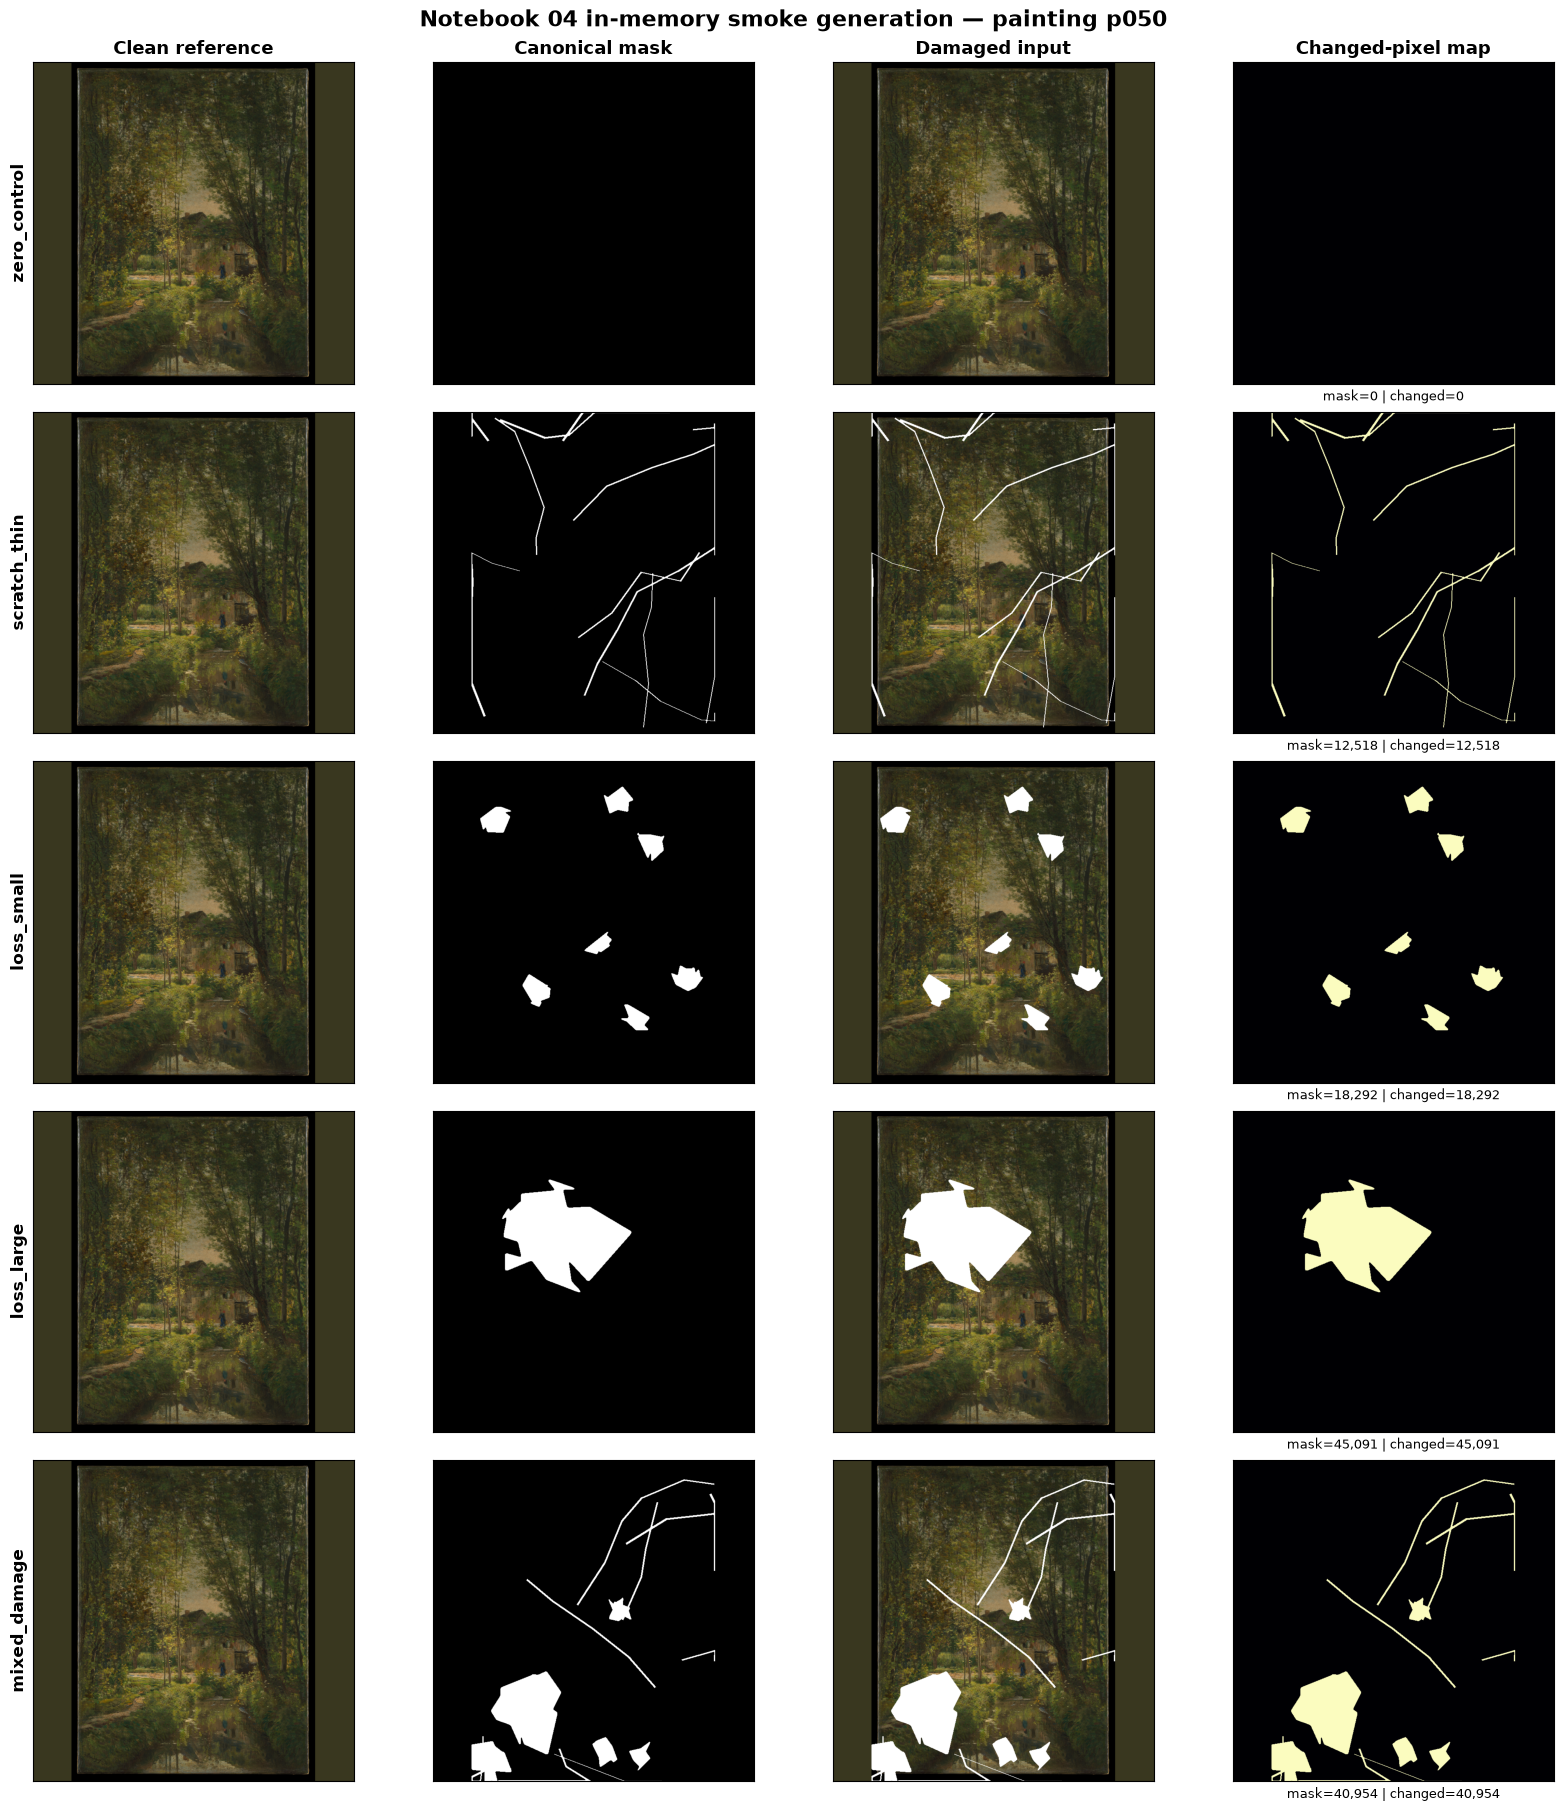


Batch 3 completed successfully.
Batch 3 checks: 10
Accumulated checks: 33
Blocking failures: 0
Notebook 04 persisted files: 0
Next approved stage: Batch 4 - full canonical damaged-image generation.


In [7]:
# ---------------------------------------------------------------------------
# Batch 3 validation
# ---------------------------------------------------------------------------

BATCH_3_START_CHECK_COUNT = len(
    VALIDATION.checks
)


def add_smoke_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "smoke_generation"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# 1. Smoke case set and configured order

observed_smoke_mask_types = tuple(
    smoke_damage_df[
        "mask_type"
    ].astype(str)
)

smoke_case_set_passed = (
    len(smoke_damage_df)
    == EXPECTED_MASK_TYPE_COUNT
    and smoke_damage_df[
        "painting_id"
    ].nunique()
    == 1
    and observed_smoke_mask_types
    == EXPECTED_MASK_TYPES
)

add_smoke_check(
    check_id="smoke_case_set",
    description=(
        "Smoke generation contains one painting "
        "and all canonical mask types in configured "
        "order."
    ),
    expected={
        "painting_count": 1,
        "case_count": (
            EXPECTED_MASK_TYPE_COUNT
        ),
        "mask_types": EXPECTED_MASK_TYPES,
    },
    observed={
        "painting_ids": sorted(
            smoke_damage_df[
                "painting_id"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),
        "case_count": len(
            smoke_damage_df
        ),
        "mask_types": (
            observed_smoke_mask_types
        ),
    },
    passed=smoke_case_set_passed,
)


# 2. Dimensions and modes

dimension_mode_failure_df = (
    smoke_damage_df.loc[
        ~(
            smoke_damage_df[
                "dimensions_valid"
            ].astype(bool)
            & smoke_damage_df[
                "modes_valid"
            ].astype(bool)
        )
    ]
    .copy()
)

add_smoke_check(
    check_id="smoke_dimensions_and_modes",
    description=(
        "Every smoke clean image, mask, and "
        "damaged image has the configured "
        "dimensions and canonical modes."
    ),
    expected={
        "size": SMOKE_TARGET_SIZE,
        "clean_mode": "RGB",
        "mask_mode": "L",
        "damaged_mode": "RGB",
        "failure_count": 0,
    },
    observed={
        "failure_count": len(
            dimension_mode_failure_df
        ),
    },
    passed=dimension_mode_failure_df.empty,
    details=(
        dimension_mode_failure_df[
            [
                "case_id",
                "dimensions_valid",
                "modes_valid",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# 3. Exact binary mask values

binary_mask_failure_df = (
    smoke_damage_df.loc[
        ~smoke_damage_df[
            "binary_values_valid"
        ].astype(bool)
    ]
    .copy()
)

add_smoke_check(
    check_id="smoke_binary_masks",
    description=(
        "Every smoke mask contains only exact "
        "values 0 and 255."
    ),
    expected={
        "allowed_values": [0, 255],
        "failure_count": 0,
    },
    observed={
        "failure_count": len(
            binary_mask_failure_df
        ),
        "observed_values": (
            smoke_damage_df[
                [
                    "mask_type",
                    "mask_unique_values",
                ]
            ].to_dict(
                orient="records"
            )
        ),
    },
    passed=binary_mask_failure_df.empty,
)


# 4. Mask-pixel reconciliation

mask_pixel_failure_df = (
    smoke_damage_df.loc[
        smoke_damage_df[
            "mask_pixel_count"
        ].astype(int)
        != smoke_damage_df[
            "metadata_mask_pixel_count"
        ].astype(int)
    ]
    .copy()
)

add_smoke_check(
    check_id=(
        "smoke_mask_pixel_reconciliation"
    ),
    description=(
        "Reloaded binary-mask pixel counts match "
        "Notebook 03 mask metadata."
    ),
    expected="zero mismatched cases",
    observed=len(
        mask_pixel_failure_df
    ),
    passed=mask_pixel_failure_df.empty,
    details=(
        mask_pixel_failure_df[
            [
                "case_id",
                "mask_pixel_count",
                "metadata_mask_pixel_count",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# 5. Outside-mask preservation

outside_mask_failure_df = (
    smoke_damage_df.loc[
        smoke_damage_df[
            "outside_mask_changed_pixel_count"
        ].astype(int)
        != 0
    ]
    .copy()
)

add_smoke_check(
    check_id=(
        "smoke_outside_mask_preservation"
    ),
    description=(
        "No clean-image pixel outside a canonical "
        "mask changes during smoke generation."
    ),
    expected={
        "changed_outside_mask": 0,
        "failure_count": 0,
    },
    observed={
        "changed_outside_mask": int(
            smoke_damage_df[
                "outside_mask_changed_pixel_count"
            ].sum()
        ),
        "failure_count": len(
            outside_mask_failure_df
        ),
    },
    passed=outside_mask_failure_df.empty,
    details=(
        outside_mask_failure_df[
            [
                "case_id",
                "outside_mask_changed_pixel_count",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# 6. Fill application inside mask

inside_fill_failure_df = (
    smoke_damage_df.loc[
        smoke_damage_df[
            "inside_mask_not_fill_pixel_count"
        ].astype(int)
        != 0
    ]
    .copy()
)

add_smoke_check(
    check_id="smoke_fill_application",
    description=(
        "Every masked smoke output pixel equals "
        "the configured canonical fill colour."
    ),
    expected={
        "masked_pixels_not_fill": 0,
        "fill_color": tuple(
            SMOKE_FILL_COLOR.tolist()
        ),
    },
    observed={
        "masked_pixels_not_fill": int(
            smoke_damage_df[
                "inside_mask_not_fill_pixel_count"
            ].sum()
        ),
    },
    passed=inside_fill_failure_df.empty,
    details=(
        inside_fill_failure_df[
            [
                "case_id",
                "inside_mask_not_fill_pixel_count",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# 7. Changed-pixel reconciliation

changed_pixel_failure_df = (
    smoke_damage_df.loc[
        smoke_damage_df[
            "changed_pixel_count_difference"
        ].astype(int)
        != 0
    ]
    .copy()
)

add_smoke_check(
    check_id=(
        "smoke_changed_pixel_reconciliation"
    ),
    description=(
        "Observed changed pixels equal mask pixels "
        "minus masked source pixels already equal "
        "to the white fill."
    ),
    expected={
        "difference_per_case": 0,
        "failure_count": 0,
    },
    observed={
        "failure_count": len(
            changed_pixel_failure_df
        ),
        "total_difference": int(
            smoke_damage_df[
                "changed_pixel_count_difference"
            ].sum()
        ),
    },
    passed=changed_pixel_failure_df.empty,
    details=(
        changed_pixel_failure_df[
            [
                "case_id",
                "mask_pixel_count",
                "preexisting_fill_pixel_count",
                "expected_changed_pixel_count",
                "observed_changed_pixel_count",
                "changed_pixel_count_difference",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# 8. Zero-control identity and non-zero masks

zero_control_failure_df = (
    smoke_damage_df.loc[
        ~smoke_damage_df[
            "zero_control_valid"
        ].astype(bool)
    ]
    .copy()
)

zero_control_row = (
    smoke_damage_df.loc[
        smoke_damage_df[
            "mask_type"
        ]
        == "zero_control"
    ]
    .iloc[0]
)

add_smoke_check(
    check_id="smoke_zero_control",
    description=(
        "The zero-control smoke output is pixel "
        "identical to clean, while every other "
        "canonical mask contains damaged pixels."
    ),
    expected={
        "zero_mask_pixels": 0,
        "zero_clean_equals_damaged": True,
        "failure_count": 0,
    },
    observed={
        "zero_mask_pixels": int(
            zero_control_row[
                "mask_pixel_count"
            ]
        ),
        "zero_clean_equals_damaged": bool(
            zero_control_row[
                "clean_equals_damaged"
            ]
        ),
        "failure_count": len(
            zero_control_failure_df
        ),
    },
    passed=zero_control_failure_df.empty,
    details=(
        zero_control_failure_df[
            [
                "case_id",
                "mask_type",
                "mask_pixel_count",
                "clean_equals_damaged",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# 9. Deterministic in-memory replay

determinism_failure_df = (
    smoke_damage_df.loc[
        ~smoke_damage_df[
            "deterministic_replay_passed"
        ].astype(bool)
    ]
    .copy()
)

add_smoke_check(
    check_id="smoke_deterministic_replay",
    description=(
        "Repeating canonical damage application "
        "produces pixel-identical results."
    ),
    expected="zero replay failures",
    observed=len(
        determinism_failure_df
    ),
    passed=determinism_failure_df.empty,
    details=(
        determinism_failure_df[
            [
                "case_id",
                "mask_type",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# 10. Smoke execution produced no files

existing_notebook_04_files = (
    sorted(
        path
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    )
    if OUTPUT_ROOT.exists()
    else []
)

add_smoke_check(
    check_id="smoke_no_persisted_artifacts",
    description=(
        "In-memory smoke execution does not write "
        "any Notebook 04 artifact."
    ),
    expected=0,
    observed=len(
        existing_notebook_04_files
    ),
    passed=not existing_notebook_04_files,
    details=[
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in existing_notebook_04_files
    ],
)


# ---------------------------------------------------------------------------
# Stop on any blocking smoke failure
# ---------------------------------------------------------------------------

BATCH_3_CHECK_COUNT = (
    len(VALIDATION.checks)
    - BATCH_3_START_CHECK_COUNT
)

if BATCH_3_CHECK_COUNT != 10:
    raise RuntimeError(
        "Batch 3 should add exactly 10 checks; "
        f"found {BATCH_3_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Smoke evidence table
# ---------------------------------------------------------------------------

all_checks_after_batch_3_df = (
    VALIDATION.to_dataframe()
)

batch_3_checks_df = (
    all_checks_after_batch_3_df.tail(
        BATCH_3_CHECK_COUNT
    )
    .reset_index(drop=True)
)

print("Batch 3 validation checks:")

display(
    batch_3_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nSmoke pixel-integrity evidence:")

display(
    smoke_damage_df[
        [
            "case_id",
            "mask_type",
            "mask_pixel_count",
            "preexisting_fill_pixel_count",
            "expected_changed_pixel_count",
            "observed_changed_pixel_count",
            "outside_mask_changed_pixel_count",
            "inside_mask_not_fill_pixel_count",
            "clean_equals_damaged",
            "deterministic_replay_passed",
            "smoke_case_passed",
        ]
    ]
)


# ---------------------------------------------------------------------------
# Inline visual smoke grid — not persisted
# ---------------------------------------------------------------------------

smoke_figure, smoke_axes = plt.subplots(
    nrows=EXPECTED_MASK_TYPE_COUNT,
    ncols=4,
    figsize=(16, 18),
    constrained_layout=True,
)

column_titles = (
    "Clean reference",
    "Canonical mask",
    "Damaged input",
    "Changed-pixel map",
)

for column_index, title in enumerate(
    column_titles
):
    smoke_axes[
        0,
        column_index,
    ].set_title(
        title,
        fontsize=13,
        fontweight="bold",
    )

for row_index, mask_type in enumerate(
    EXPECTED_MASK_TYPES
):
    arrays = smoke_image_arrays[
        mask_type
    ]

    smoke_axes[
        row_index,
        0,
    ].imshow(
        arrays["clean"]
    )

    smoke_axes[
        row_index,
        1,
    ].imshow(
        arrays["mask"],
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    smoke_axes[
        row_index,
        2,
    ].imshow(
        arrays["damaged"]
    )

    smoke_axes[
        row_index,
        3,
    ].imshow(
        arrays["changed_pixels"],
        cmap="magma",
        vmin=0,
        vmax=1,
    )

    smoke_axes[
        row_index,
        0,
    ].set_ylabel(
        mask_type,
        fontsize=12,
        fontweight="bold",
    )

    smoke_row = (
        smoke_damage_df.loc[
            smoke_damage_df[
                "mask_type"
            ]
            == mask_type
        ]
        .iloc[0]
    )

    smoke_axes[
        row_index,
        3,
    ].set_xlabel(
        (
            "mask="
            f"{int(smoke_row['mask_pixel_count']):,}"
            " | changed="
            f"{int(smoke_row['observed_changed_pixel_count']):,}"
        ),
        fontsize=9,
    )

    for column_index in range(4):
        smoke_axes[
            row_index,
            column_index,
        ].set_xticks([])

        smoke_axes[
            row_index,
            column_index,
        ].set_yticks([])

smoke_figure.suptitle(
    (
        "Notebook 04 in-memory smoke generation — "
        f"painting {representative_painting_ids[0]}"
    ),
    fontsize=16,
    fontweight="bold",
)

plt.show()

plt.close(smoke_figure)


print(
    "\nBatch 3 completed successfully."
)

print(
    "Batch 3 checks:",
    BATCH_3_CHECK_COUNT,
)

print(
    "Accumulated checks:",
    len(
        all_checks_after_batch_3_df
    ),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Notebook 04 persisted files:",
    len(
        existing_notebook_04_files
    ),
)

print(
    "Next approved stage: Batch 4 - "
    "full canonical damaged-image generation."
)

## Batch 4 — Full Canonical Damaged-Image Generation

This batch generates all 250 canonical damaged images.

For each canonical case it will:

- resolve the validated clean image and binary mask;
- verify the mask-pixel count before generation;
- copy zero-control clean PNGs byte-for-byte;
- apply the configured white fill for non-zero masks;
- write atomically to the Notebook 04 output root;
- use the normalized path structure `<painting_id>/<mask_type>.png`;
- reload the written PNG metadata;
- calculate clean, mask, and damaged-image SHA-256 checksums;
- construct the normalized in-memory `canonical_damage_cases.v1` table;
- remove stale files only from the owned damaged-image directory;
- retain runtime measurements only in memory.

This batch writes the 250 canonical damaged PNGs. The case table and other tabular artifacts remain in memory until the later persistence batch.

In [8]:
# ---------------------------------------------------------------------------
# Full canonical damaged-image generation
# ---------------------------------------------------------------------------

from restoration_eval.damage import (
    generate_canonical_damage_dataset,
)


damage_generation_result = (
    generate_canonical_damage_dataset(
        preprocessed_df,
        masks_df,
        damage_config,
        PROJECT_ROOT,
    )
)

canonical_damage_cases_df = (
    damage_generation_result.cases.copy()
)

damage_generation_runtimes_df = (
    damage_generation_result.runtimes.copy()
)

removed_stale_damage_paths = tuple(
    damage_generation_result
    .removed_stale_paths
)


print(
    "Canonical damaged images generated:",
    len(canonical_damage_cases_df),
)

print(
    "Runtime records:",
    len(
        damage_generation_runtimes_df
    ),
)

print(
    "Stale files removed:",
    len(
        removed_stale_damage_paths
    ),
)

print(
    "Damaged-image directory:",
    to_repo_relative(
        DAMAGED_IMAGE_DIRECTORY,
        PROJECT_ROOT,
    ),
)

Canonical damaged images generated: 250
Runtime records: 250
Stale files removed: 0
Damaged-image directory: outputs/04_canonical_damaged_image_generation/images/damaged


In [9]:
# ---------------------------------------------------------------------------
# Batch 4 generation validation
# ---------------------------------------------------------------------------

BATCH_4_START_CHECK_COUNT = len(
    VALIDATION.checks
)


def add_generation_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "full_generation"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# 1. Normalized case schema

generated_case_schema_result = (
    validate_dataframe(
        canonical_damage_cases_df,
        CANONICAL_DAMAGE_CASES_SCHEMA,
        allow_extra_columns=False,
    )
)

generated_case_schema_passed = (
    generated_case_schema_result.passed
    and not (
        generated_case_schema_result
        .unexpected_columns
    )
)

add_generation_check(
    check_id="generated_case_schema",
    description=(
        "Generated canonical case records satisfy "
        "canonical_damage_cases.v1 without extra "
        "or missing columns."
    ),
    expected={
        "schema": (
            CANONICAL_DAMAGE_CASES_SCHEMA.version
        ),
        "schema_errors": 0,
    },
    observed=(
        generated_case_schema_result
        .to_dict()
    ),
    passed=generated_case_schema_passed,
)


# 2. Case cardinality and uniqueness

duplicate_case_count = int(
    canonical_damage_cases_df[
        "case_id"
    ].duplicated(
        keep=False
    ).sum()
)

duplicate_damaged_image_id_count = int(
    canonical_damage_cases_df[
        "damaged_image_id"
    ].duplicated(
        keep=False
    ).sum()
)

duplicate_damaged_path_count = int(
    canonical_damage_cases_df[
        "damaged_image_path"
    ].duplicated(
        keep=False
    ).sum()
)

case_cardinality_passed = (
    len(canonical_damage_cases_df)
    == EXPECTED_CASE_COUNT
    and duplicate_case_count == 0
    and duplicate_damaged_image_id_count
    == 0
    and duplicate_damaged_path_count == 0
)

add_generation_check(
    check_id=(
        "generated_case_cardinality"
    ),
    description=(
        "Generated case count and all primary "
        "case, damaged-image, and path identities "
        "are unique."
    ),
    expected={
        "case_count": EXPECTED_CASE_COUNT,
        "duplicate_case_ids": 0,
        "duplicate_damaged_image_ids": 0,
        "duplicate_damaged_paths": 0,
    },
    observed={
        "case_count": len(
            canonical_damage_cases_df
        ),
        "duplicate_case_ids": (
            duplicate_case_count
        ),
        "duplicate_damaged_image_ids": (
            duplicate_damaged_image_id_count
        ),
        "duplicate_damaged_paths": (
            duplicate_damaged_path_count
        ),
    },
    passed=case_cardinality_passed,
)


# 3. Foreign-key preservation

foreign_key_results = {
    "case_ids": (
        set(
            canonical_damage_cases_df[
                "case_id"
            ].astype(str)
        )
        == set(
            masks_df[
                "case_id"
            ].astype(str)
        )
    ),
    "mask_ids": (
        set(
            canonical_damage_cases_df[
                "mask_id"
            ].astype(str)
        )
        == set(
            masks_df[
                "mask_id"
            ].astype(str)
        )
    ),
    "processed_image_ids": (
        set(
            canonical_damage_cases_df[
                "processed_image_id"
            ].astype(str)
        )
        == set(
            masks_df[
                "processed_image_id"
            ].astype(str)
        )
    ),
    "painting_ids": (
        set(
            canonical_damage_cases_df[
                "painting_id"
            ].astype(str)
        )
        == set(
            preprocessed_df[
                "painting_id"
            ].astype(str)
        )
    ),
    "mask_types": (
        set(
            canonical_damage_cases_df[
                "mask_type"
            ].astype(str)
        )
        == set(EXPECTED_MASK_TYPES)
    ),
}

foreign_keys_passed = all(
    foreign_key_results.values()
)

add_generation_check(
    check_id=(
        "generated_foreign_keys"
    ),
    description=(
        "Generated cases preserve the complete "
        "Notebook 02 and Notebook 03 identifier "
        "sets."
    ),
    expected={
        key: True
        for key in foreign_key_results
    },
    observed=foreign_key_results,
    passed=foreign_keys_passed,
)


# 4. Nested path and filename contract

expected_damage_path_records = []
path_contract_failure_records = []

for generated_row in (
    canonical_damage_cases_df.itertuples(
        index=False
    )
):
    expected_path = (
        DAMAGED_IMAGE_DIRECTORY
        / str(
            generated_row.painting_id
        )
        / (
            f"{generated_row.mask_type}"
            ".png"
        )
    )

    expected_relative_path = (
        to_repo_relative(
            expected_path,
            PROJECT_ROOT,
        )
    )

    expected_filename = (
        f"{generated_row.mask_type}.png"
    )

    path_passed = (
        str(
            generated_row
            .damaged_image_path
        )
        == expected_relative_path
        and str(
            generated_row
            .damaged_filename
        )
        == expected_filename
    )

    expected_damage_path_records.append(
        {
            "case_id": str(
                generated_row.case_id
            ),
            "expected_path": (
                expected_relative_path
            ),
            "resolved_path": (
                expected_path.resolve()
            ),
        }
    )

    if not path_passed:
        path_contract_failure_records.append(
            {
                "case_id": str(
                    generated_row.case_id
                ),
                "observed_path": str(
                    generated_row
                    .damaged_image_path
                ),
                "expected_path": (
                    expected_relative_path
                ),
                "observed_filename": str(
                    generated_row
                    .damaged_filename
                ),
                "expected_filename": (
                    expected_filename
                ),
            }
        )

path_contract_passed = (
    not path_contract_failure_records
)

add_generation_check(
    check_id=(
        "damaged_image_path_contract"
    ),
    description=(
        "Every generated path follows "
        "images/damaged/<painting_id>/"
        "<mask_type>.png."
    ),
    expected="zero path mismatches",
    observed=len(
        path_contract_failure_records
    ),
    passed=path_contract_passed,
    details=(
        path_contract_failure_records
    ),
)


# 5. Generator and fill metadata

observed_fill_records = (
    canonical_damage_cases_df[
        [
            "fill_strategy",
            "fill_color_r",
            "fill_color_g",
            "fill_color_b",
            "generator_name",
            "generator_version",
            "config_schema_version",
            "config_version",
        ]
    ]
    .drop_duplicates()
    .to_dict(
        orient="records"
    )
)

expected_fill_record = {
    "fill_strategy": (
        damage_config["generator"][
            "fill_strategy"
        ]
    ),
    "fill_color_r": int(
        damage_config["generator"][
            "fill_color_rgb"
        ][0]
    ),
    "fill_color_g": int(
        damage_config["generator"][
            "fill_color_rgb"
        ][1]
    ),
    "fill_color_b": int(
        damage_config["generator"][
            "fill_color_rgb"
        ][2]
    ),
    "generator_name": (
        damage_config["generator"][
            "name"
        ]
    ),
    "generator_version": (
        damage_config["generator"][
            "version"
        ]
    ),
    "config_schema_version": (
        damage_config[
            "config_schema_version"
        ]
    ),
    "config_version": (
        damage_config["config_version"]
    ),
}

generator_metadata_passed = (
    observed_fill_records
    == [expected_fill_record]
)

add_generation_check(
    check_id=(
        "generator_and_fill_metadata"
    ),
    description=(
        "Every generated case records the exact "
        "configured generator, white-fill policy, "
        "and configuration versions."
    ),
    expected=expected_fill_record,
    observed=observed_fill_records,
    passed=generator_metadata_passed,
)


# 6. Written image metadata and checksum syntax

checksum_pattern = re.compile(
    r"^[0-9a-f]{64}$"
)

image_metadata_failure_df = (
    canonical_damage_cases_df.loc[
        (
            canonical_damage_cases_df[
                "width"
            ].astype(int)
            != SMOKE_TARGET_SIZE[0]
        )
        |
        (
            canonical_damage_cases_df[
                "height"
            ].astype(int)
            != SMOKE_TARGET_SIZE[1]
        )
        |
        (
            canonical_damage_cases_df[
                "mode"
            ].astype(str)
            != "RGB"
        )
        |
        (
            canonical_damage_cases_df[
                "format"
            ].astype(str)
            != "PNG"
        )
        |
        (
            canonical_damage_cases_df[
                "size_bytes"
            ].astype(int)
            <= 0
        )
        |
        (
            ~canonical_damage_cases_df[
                "clean_image_sha256"
            ]
            .astype(str)
            .str.fullmatch(
                checksum_pattern
            )
        )
        |
        (
            ~canonical_damage_cases_df[
                "mask_sha256"
            ]
            .astype(str)
            .str.fullmatch(
                checksum_pattern
            )
        )
        |
        (
            ~canonical_damage_cases_df[
                "damaged_image_sha256"
            ]
            .astype(str)
            .str.fullmatch(
                checksum_pattern
            )
        )
    ]
    .copy()
)

add_generation_check(
    check_id=(
        "generated_image_metadata"
    ),
    description=(
        "Every generated record describes a "
        "non-empty 768 × 768 RGB PNG and contains "
        "three syntactically valid SHA-256 values."
    ),
    expected={
        "width": SMOKE_TARGET_SIZE[0],
        "height": SMOKE_TARGET_SIZE[1],
        "mode": "RGB",
        "format": "PNG",
        "invalid_rows": 0,
    },
    observed={
        "invalid_rows": len(
            image_metadata_failure_df
        ),
    },
    passed=(
        image_metadata_failure_df.empty
    ),
    details=(
        image_metadata_failure_df[
            [
                "case_id",
                "width",
                "height",
                "mode",
                "format",
                "size_bytes",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# 7. Generation status

generation_status_failure_df = (
    canonical_damage_cases_df.loc[
        ~(
            canonical_damage_cases_df[
                "generation_status"
            ].astype(str)
            .eq("passed")
            & canonical_damage_cases_df[
                "status"
            ].astype(str)
            .eq("passed")
            & canonical_damage_cases_df[
                "issue"
            ]
            .fillna("")
            .astype(str)
            .eq("")
        )
    ]
    .copy()
)

add_generation_check(
    check_id="generation_status",
    description=(
        "Every generated case reports passed "
        "generation and contains no issue text."
    ),
    expected="zero failed generation rows",
    observed=len(
        generation_status_failure_df
    ),
    passed=(
        generation_status_failure_df.empty
    ),
    details=(
        generation_status_failure_df[
            [
                "case_id",
                "generation_status",
                "status",
                "issue",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# 8. Physical damaged-image inventory

expected_damage_paths = {
    record["resolved_path"]
    for record in (
        expected_damage_path_records
    )
}

actual_damaged_files = sorted(
    path
    for path in (
        DAMAGED_IMAGE_DIRECTORY
        .rglob("*")
    )
    if path.is_file()
)

actual_damaged_paths = {
    path.resolve()
    for path in actual_damaged_files
}

missing_damaged_paths = sorted(
    expected_damage_paths
    - actual_damaged_paths,
    key=lambda path: path.as_posix(),
)

orphan_damaged_paths = sorted(
    actual_damaged_paths
    - expected_damage_paths,
    key=lambda path: path.as_posix(),
)

non_png_damaged_paths = [
    path
    for path in actual_damaged_files
    if path.suffix.lower() != ".png"
]

physical_inventory_passed = (
    len(actual_damaged_files)
    == EXPECTED_CASE_COUNT
    and not missing_damaged_paths
    and not orphan_damaged_paths
    and not non_png_damaged_paths
)

add_generation_check(
    check_id=(
        "physical_damaged_image_inventory"
    ),
    description=(
        "The damaged-image directory contains "
        "exactly the 250 declared PNG files with "
        "no missing or orphaned outputs."
    ),
    expected={
        "file_count": EXPECTED_CASE_COUNT,
        "missing": 0,
        "orphaned": 0,
        "non_png": 0,
    },
    observed={
        "file_count": len(
            actual_damaged_files
        ),
        "missing": len(
            missing_damaged_paths
        ),
        "orphaned": len(
            orphan_damaged_paths
        ),
        "non_png": len(
            non_png_damaged_paths
        ),
    },
    passed=physical_inventory_passed,
    details={
        "missing": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in (
                missing_damaged_paths
            )
        ],
        "orphaned": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in (
                orphan_damaged_paths
            )
        ],
        "non_png": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in (
                non_png_damaged_paths
            )
        ],
    },
)


# 9. Zero-control byte identity

zero_control_cases_df = (
    canonical_damage_cases_df.loc[
        canonical_damage_cases_df[
            "mask_type"
        ]
        == "zero_control"
    ]
    .copy()
)

zero_control_checksum_failure_df = (
    zero_control_cases_df.loc[
        zero_control_cases_df[
            "clean_image_sha256"
        ].astype(str)
        != zero_control_cases_df[
            "damaged_image_sha256"
        ].astype(str)
    ]
    .copy()
)

zero_control_identity_passed = (
    len(zero_control_cases_df)
    == EXPECTED_PAINTING_COUNT
    and (
        zero_control_checksum_failure_df
        .empty
    )
)

add_generation_check(
    check_id=(
        "zero_control_byte_identity"
    ),
    description=(
        "Every zero-control damaged PNG is a "
        "byte-identical copy of its clean source."
    ),
    expected={
        "zero_control_count": (
            EXPECTED_PAINTING_COUNT
        ),
        "checksum_mismatches": 0,
    },
    observed={
        "zero_control_count": len(
            zero_control_cases_df
        ),
        "checksum_mismatches": len(
            zero_control_checksum_failure_df
        ),
    },
    passed=zero_control_identity_passed,
    details=(
        zero_control_checksum_failure_df[
            [
                "case_id",
                "clean_image_sha256",
                "damaged_image_sha256",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# 10. Stale-removal scope and temporary-file hygiene

damaged_directory_prefix = (
    to_repo_relative(
        DAMAGED_IMAGE_DIRECTORY,
        PROJECT_ROOT,
    ).rstrip("/")
    + "/"
)

invalid_removed_stale_paths = [
    path
    for path in (
        removed_stale_damage_paths
    )
    if (
        not path.startswith(
            damaged_directory_prefix
        )
        or resolve_repo_path(
            path,
            PROJECT_ROOT,
        ).exists()
    )
]

temporary_output_files = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and (
            ".tmp" in path.name.lower()
            or path.suffix.lower()
            in {
                ".temp",
                ".partial",
            }
        )
    )
)

generation_hygiene_passed = (
    not invalid_removed_stale_paths
    and not temporary_output_files
)

add_generation_check(
    check_id="generation_output_hygiene",
    description=(
        "Any stale-file removal remained inside "
        "the owned damaged-image directory and no "
        "temporary output remains."
    ),
    expected={
        "invalid_removed_paths": 0,
        "temporary_files": 0,
    },
    observed={
        "removed_stale_files": len(
            removed_stale_damage_paths
        ),
        "invalid_removed_paths": len(
            invalid_removed_stale_paths
        ),
        "temporary_files": len(
            temporary_output_files
        ),
    },
    passed=generation_hygiene_passed,
    details={
        "removed_stale_paths": list(
            removed_stale_damage_paths
        ),
        "invalid_removed_paths": (
            invalid_removed_stale_paths
        ),
        "temporary_files": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in (
                temporary_output_files
            )
        ],
    },
)


# ---------------------------------------------------------------------------
# Stop on any blocking generation failure
# ---------------------------------------------------------------------------

BATCH_4_CHECK_COUNT = (
    len(VALIDATION.checks)
    - BATCH_4_START_CHECK_COUNT
)

if BATCH_4_CHECK_COUNT != 10:
    raise RuntimeError(
        "Batch 4 should add exactly 10 checks; "
        f"found {BATCH_4_CHECK_COUNT}."
    )

VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Render concise generation evidence
# ---------------------------------------------------------------------------

all_checks_after_batch_4_df = (
    VALIDATION.to_dataframe()
)

batch_4_checks_df = (
    all_checks_after_batch_4_df.tail(
        BATCH_4_CHECK_COUNT
    )
    .reset_index(drop=True)
)

runtime_with_conditions_df = (
    damage_generation_runtimes_df.merge(
        canonical_damage_cases_df[
            [
                "case_id",
                "mask_type",
                "mask_pixel_count",
                "size_bytes",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)

generation_summary_df = (
    runtime_with_conditions_df.groupby(
        "mask_type",
        observed=True,
        sort=False,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        ),
        total_mask_pixels=(
            "mask_pixel_count",
            "sum",
        ),
        mean_mask_pixels=(
            "mask_pixel_count",
            "mean",
        ),
        total_size_bytes=(
            "size_bytes",
            "sum",
        ),
        mean_runtime_seconds=(
            "runtime_seconds",
            "mean",
        ),
    )
    .reindex(
        EXPECTED_MASK_TYPES
    )
    .reset_index()
)

print("Batch 4 validation checks:")

display(
    batch_4_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nGeneration summary:")

display(generation_summary_df)

print("\nNormalized case sample:")

display(
    canonical_damage_cases_df[
        [
            "case_id",
            "painting_id",
            "processed_image_id",
            "mask_id",
            "mask_type",
            "damaged_image_id",
            "clean_image_path",
            "mask_path",
            "damaged_image_path",
            "mask_pixel_count",
            "size_bytes",
            "generation_status",
        ]
    ].head(10)
)

print(
    "\nBatch 4 completed successfully."
)

print(
    "Batch 4 checks:",
    BATCH_4_CHECK_COUNT,
)

print(
    "Accumulated checks:",
    len(
        all_checks_after_batch_4_df
    ),
)

print(
    "Blocking failures:",
    len(
        VALIDATION.blocking_failures
    ),
)

print(
    "Generated damaged PNGs:",
    len(
        actual_damaged_files
    ),
)

print(
    "Case table remains in memory:",
    canonical_damage_cases_df.shape,
)

print(
    "Next approved stage: Batch 5 - "
    "full reload and per-case pixel-integrity "
    "audit."
)

Batch 4 validation checks:


,check_id,severity,expected,observed,passed
0,generated_case_schema,blocking,"{""schema"": ""canonical_damage_cases.v1"", ""schem...","{""column_count"": 34, ""duplicate_primary_key_ro...",True
1,generated_case_cardinality,blocking,"{""case_count"": 250, ""duplicate_case_ids"": 0, ""...","{""case_count"": 250, ""duplicate_case_ids"": 0, ""...",True
2,generated_foreign_keys,blocking,"{""case_ids"": true, ""mask_ids"": true, ""mask_typ...","{""case_ids"": true, ""mask_ids"": true, ""mask_typ...",True
3,damaged_image_path_contract,blocking,zero path mismatches,0,True
4,generator_and_fill_metadata,blocking,"{""config_schema_version"": ""canonical_damage_co...","[{""config_schema_version"": ""canonical_damage_c...",True
5,generated_image_metadata,blocking,"{""format"": ""PNG"", ""height"": 768, ""invalid_rows...","{""invalid_rows"": 0}",True
6,generation_status,blocking,zero failed generation rows,0,True
7,physical_damaged_image_inventory,blocking,"{""file_count"": 250, ""missing"": 0, ""non_png"": 0...","{""file_count"": 250, ""missing"": 0, ""non_png"": 0...",True
8,zero_control_byte_identity,blocking,"{""checksum_mismatches"": 0, ""zero_control_count...","{""checksum_mismatches"": 0, ""zero_control_count...",True
9,generation_output_hygiene,blocking,"{""invalid_removed_paths"": 0, ""temporary_files""...","{""invalid_removed_paths"": 0, ""removed_stale_fi...",True



Generation summary:


,mask_type,case_count,total_mask_pixels,mean_mask_pixels,total_size_bytes,mean_runtime_seconds
0,zero_control,50,0,0.00,36126399,0.142636
1,scratch_thin,50,515939,10318.78,36275321,0.482843
2,loss_small,50,965999,19319.98,34916160,0.479015
3,loss_large,50,2840549,56810.98,31719582,0.444973
4,mixed_damage,50,2223396,44467.92,33608532,0.456320



Normalized case sample:


,case_id,painting_id,processed_image_id,mask_id,mask_type,damaged_image_id,clean_image_path,mask_path,damaged_image_path,mask_pixel_count,size_bytes,generation_status
0,canonical__p001__zero_control,p001,clean_p001,mask__canonical__p001__zero_control,zero_control,damaged__canonical__p001__zero_control,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...,outputs/04_canonical_damaged_image_generation/...,0,723881,passed
1,canonical__p001__scratch_thin,p001,clean_p001,mask__canonical__p001__scratch_thin,scratch_thin,damaged__canonical__p001__scratch_thin,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...,outputs/04_canonical_damaged_image_generation/...,11058,726195,passed
2,canonical__p001__loss_small,p001,clean_p001,mask__canonical__p001__loss_small,loss_small,damaged__canonical__p001__loss_small,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...,outputs/04_canonical_damaged_image_generation/...,17388,705120,passed
3,canonical__p001__loss_large,p001,clean_p001,mask__canonical__p001__loss_large,loss_large,damaged__canonical__p001__loss_large,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...,outputs/04_canonical_damaged_image_generation/...,70792,627570,passed
4,canonical__p001__mixed_damage,p001,clean_p001,mask__canonical__p001__mixed_damage,mixed_damage,damaged__canonical__p001__mixed_damage,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...,outputs/04_canonical_damaged_image_generation/...,48039,684703,passed
5,canonical__p002__zero_control,p002,clean_p002,mask__canonical__p002__zero_control,zero_control,damaged__canonical__p002__zero_control,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...,outputs/04_canonical_damaged_image_generation/...,0,339472,passed
6,canonical__p002__scratch_thin,p002,clean_p002,mask__canonical__p002__scratch_thin,scratch_thin,damaged__canonical__p002__scratch_thin,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...,outputs/04_canonical_damaged_image_generation/...,8389,343082,passed
7,canonical__p002__loss_small,p002,clean_p002,mask__canonical__p002__loss_small,loss_small,damaged__canonical__p002__loss_small,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...,outputs/04_canonical_damaged_image_generation/...,18774,319799,passed
8,canonical__p002__loss_large,p002,clean_p002,mask__canonical__p002__loss_large,loss_large,damaged__canonical__p002__loss_large,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...,outputs/04_canonical_damaged_image_generation/...,44285,283545,passed
9,canonical__p002__mixed_damage,p002,clean_p002,mask__canonical__p002__mixed_damage,mixed_damage,damaged__canonical__p002__mixed_damage,outputs/02_image_preprocessing/images/clean/p0...,outputs/03_canonical_mask_generation/images/ma...,outputs/04_canonical_damaged_image_generation/...,40820,311106,passed



Batch 4 completed successfully.
Batch 4 checks: 10
Accumulated checks: 43
Blocking failures: 0
Generated damaged PNGs: 250
Case table remains in memory: (250, 34)
Next approved stage: Batch 5 - full reload and per-case pixel-integrity audit.


## Batch 5 — Full reload and per-case pixel-integrity audit

This batch validates the persisted canonical damage dataset independently of the
in-memory generation arrays.

For every canonical case, it reloads the clean image, binary mask, and damaged
PNG and verifies:

- schema and one-to-one case coverage;
- physical output inventory and orphan-file absence;
- dimensions, image mode, and file format;
- clean, mask, and damaged-image checksums;
- binary mask values and mask-pixel reconciliation;
- expected versus observed changed-pixel counts;
- preservation of every pixel outside the mask;
- exact white fill inside the mask;
- exact zero-control identity;
- non-empty damage semantics for all non-control cases.

The resulting 250-row audit remains in memory until the persistence batch.

In [10]:
# ---------------------------------------------------------------------------
# Full persisted-dataset reload audit
# ---------------------------------------------------------------------------

from restoration_eval.damage import (
    validate_saved_damage_dataset,
)


damage_validation_result = (
    validate_saved_damage_dataset(
        canonical_damage_cases_df,
        damage_config,
        PROJECT_ROOT,
    )
)

canonical_damage_audit_df = (
    damage_validation_result.case_checks.copy()
)

damage_validation_summary = dict(
    damage_validation_result.summary
)

orphan_reloaded_damage_paths = tuple(
    damage_validation_result.orphan_paths
)


damage_validation_summary_df = pd.DataFrame(
    [
        {
            "metric": metric,
            "value": value,
        }
        for metric, value
        in damage_validation_summary.items()
    ]
)


print(
    "Reloaded canonical cases:",
    len(canonical_damage_audit_df),
)

print(
    "Validation result passed:",
    damage_validation_result.passed,
)

print(
    "Orphan damaged-image paths:",
    len(orphan_reloaded_damage_paths),
)

display(
    damage_validation_summary_df
)

Reloaded canonical cases: 250
Validation result passed: True
Orphan damaged-image paths: 0


,metric,value
0,case_count,250
1,duplicate_case_id_count,0
2,duplicate_damaged_path_count,0
3,missing_output_count,0
4,orphan_output_count,0
5,failed_case_count,0
6,reload_failure_count,0
7,dimension_failure_count,0
8,binary_mask_failure_count,0
9,zero_control_failure_count,0


In [11]:
# ---------------------------------------------------------------------------
# Batch 5 validation checks
# ---------------------------------------------------------------------------

BATCH_5_START_CHECK_COUNT = len(
    VALIDATION.to_dataframe()
)


def add_full_reload_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    """Register one blocking Batch 5 validation check."""

    VALIDATION.add(
        validation_stage="full_reload_audit",
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Canonical audit schema and cardinality
# ---------------------------------------------------------------------------

damage_audit_schema_result = validate_dataframe(
    canonical_damage_audit_df,
    CANONICAL_DAMAGE_AUDIT_SCHEMA,
    allow_extra_columns=False,
)

damage_audit_schema_passed = (
    damage_audit_schema_result.passed
    and not damage_audit_schema_result.unexpected_columns
    and len(canonical_damage_audit_df)
    == EXPECTED_CASE_COUNT
)

add_full_reload_check(
    check_id="damage_audit_schema",
    description=(
        "The reloaded per-case audit satisfies "
        "canonical_damage_audit.v1 with exactly "
        "one row per canonical case."
    ),
    expected={
        "schema_version": (
            CANONICAL_DAMAGE_AUDIT_SCHEMA.version
        ),
        "row_count": EXPECTED_CASE_COUNT,
        "unexpected_columns": [],
    },
    observed={
        "row_count": len(
            canonical_damage_audit_df
        ),
        "unexpected_columns": list(
            damage_audit_schema_result
            .unexpected_columns
        ),
        "schema_passed": (
            damage_audit_schema_result.passed
        ),
    },
    passed=damage_audit_schema_passed,
    details=damage_audit_schema_result.to_dict(),
)


# ---------------------------------------------------------------------------
# 2. One-to-one case coverage
# ---------------------------------------------------------------------------

declared_case_ids = set(
    canonical_damage_cases_df[
        "case_id"
    ].astype(str)
)

audited_case_ids = set(
    canonical_damage_audit_df[
        "case_id"
    ].astype(str)
)

missing_audit_case_ids = sorted(
    declared_case_ids - audited_case_ids
)

unexpected_audit_case_ids = sorted(
    audited_case_ids - declared_case_ids
)

duplicate_audit_case_count = int(
    canonical_damage_audit_df[
        "case_id"
    ].duplicated(
        keep=False
    ).sum()
)

case_coverage_passed = (
    declared_case_ids == audited_case_ids
    and duplicate_audit_case_count == 0
    and len(canonical_damage_audit_df)
    == len(canonical_damage_cases_df)
)

add_full_reload_check(
    check_id="damage_audit_case_coverage",
    description=(
        "The reload audit covers every generated "
        "case exactly once and introduces no "
        "unexpected case identifiers."
    ),
    expected={
        "case_count": EXPECTED_CASE_COUNT,
        "duplicates": 0,
        "missing": 0,
        "unexpected": 0,
    },
    observed={
        "case_count": len(
            canonical_damage_audit_df
        ),
        "duplicates": (
            duplicate_audit_case_count
        ),
        "missing": len(
            missing_audit_case_ids
        ),
        "unexpected": len(
            unexpected_audit_case_ids
        ),
    },
    passed=case_coverage_passed,
    details={
        "missing_case_ids": (
            missing_audit_case_ids
        ),
        "unexpected_case_ids": (
            unexpected_audit_case_ids
        ),
    },
)


# ---------------------------------------------------------------------------
# 3. Persisted output inventory
# ---------------------------------------------------------------------------

reloaded_physical_files = sorted(
    path
    for path in DAMAGED_IMAGE_DIRECTORY.rglob("*")
    if path.is_file()
)

non_png_reloaded_files = [
    path
    for path in reloaded_physical_files
    if path.suffix.lower() != ".png"
]

output_inventory_passed = (
    damage_validation_summary[
        "duplicate_case_id_count"
    ]
    == 0
    and damage_validation_summary[
        "duplicate_damaged_path_count"
    ]
    == 0
    and damage_validation_summary[
        "missing_output_count"
    ]
    == 0
    and damage_validation_summary[
        "orphan_output_count"
    ]
    == 0
    and len(reloaded_physical_files)
    == EXPECTED_CASE_COUNT
    and not non_png_reloaded_files
    and not orphan_reloaded_damage_paths
)

add_full_reload_check(
    check_id="reloaded_output_inventory",
    description=(
        "The persisted damaged-image hierarchy "
        "contains exactly the declared PNG outputs "
        "with no missing, duplicate, or orphan files."
    ),
    expected={
        "physical_files": EXPECTED_CASE_COUNT,
        "missing": 0,
        "orphaned": 0,
        "duplicate_paths": 0,
        "non_png": 0,
    },
    observed={
        "physical_files": len(
            reloaded_physical_files
        ),
        "missing": damage_validation_summary[
            "missing_output_count"
        ],
        "orphaned": damage_validation_summary[
            "orphan_output_count"
        ],
        "duplicate_paths": (
            damage_validation_summary[
                "duplicate_damaged_path_count"
            ]
        ),
        "non_png": len(
            non_png_reloaded_files
        ),
    },
    passed=output_inventory_passed,
    details={
        "orphan_paths": list(
            orphan_reloaded_damage_paths
        ),
        "non_png_paths": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in non_png_reloaded_files
        ],
    },
)


# ---------------------------------------------------------------------------
# 4. Reload, geometry, mode, and format contract
# ---------------------------------------------------------------------------

expected_width = int(
    damage_config["generator"][
        "target_width"
    ]
)

expected_height = int(
    damage_config["generator"][
        "target_height"
    ]
)

expected_mode = str(
    damage_config["generator"][
        "output_mode"
    ]
)

expected_format = str(
    damage_config["generator"][
        "output_format"
    ]
)

reload_contract_failure_df = (
    canonical_damage_audit_df.loc[
        ~(
            canonical_damage_audit_df[
                "reload_passed"
            ].astype(bool)
            & canonical_damage_audit_df[
                "dimensions_match"
            ].astype(bool)
            & canonical_damage_audit_df[
                "damaged_mode"
            ].astype(str).eq(
                expected_mode
            )
            & canonical_damage_audit_df[
                "damaged_format"
            ].astype(str).eq(
                expected_format
            )
            & canonical_damage_audit_df[
                "output_contract_valid"
            ].astype(bool)
        )
    ].copy()
)

reload_contract_passed = (
    reload_contract_failure_df.empty
    and damage_validation_summary[
        "reload_failure_count"
    ]
    == 0
    and damage_validation_summary[
        "dimension_failure_count"
    ]
    == 0
    and damage_validation_summary[
        "output_contract_failure_count"
    ]
    == 0
)

add_full_reload_check(
    check_id="reloaded_image_contract",
    description=(
        "Every clean image, mask, and damaged image "
        "reloads successfully with the configured "
        "geometry, RGB mode, and PNG format."
    ),
    expected={
        "width": expected_width,
        "height": expected_height,
        "mode": expected_mode,
        "format": expected_format,
        "failed_cases": 0,
    },
    observed={
        "reload_failures": (
            damage_validation_summary[
                "reload_failure_count"
            ]
        ),
        "dimension_failures": (
            damage_validation_summary[
                "dimension_failure_count"
            ]
        ),
        "contract_failures": (
            damage_validation_summary[
                "output_contract_failure_count"
            ]
        ),
    },
    passed=reload_contract_passed,
    details=(
        reload_contract_failure_df[
            [
                "case_id",
                "reload_passed",
                "dimensions_match",
                "damaged_mode",
                "damaged_format",
                "issue",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 5. Persisted checksums
# ---------------------------------------------------------------------------

checksum_columns = [
    "clean_sha256_matches",
    "mask_sha256_matches",
    "damaged_sha256_matches",
]

checksum_failure_df = (
    canonical_damage_audit_df.loc[
        ~canonical_damage_audit_df[
            checksum_columns
        ].astype(bool).all(axis=1)
    ].copy()
)

checksum_validation_passed = (
    checksum_failure_df.empty
    and damage_validation_summary[
        "checksum_failure_count"
    ]
    == 0
)

add_full_reload_check(
    check_id="reloaded_checksums",
    description=(
        "Reloaded clean images, masks, and damaged "
        "images match their recorded SHA-256 values."
    ),
    expected={
        "failed_cases": 0,
        "checksum_columns": checksum_columns,
    },
    observed={
        "failed_cases": len(
            checksum_failure_df
        ),
        "summary_failure_count": (
            damage_validation_summary[
                "checksum_failure_count"
            ]
        ),
    },
    passed=checksum_validation_passed,
    details=(
        checksum_failure_df[
            [
                "case_id",
                *checksum_columns,
                "issue",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 6. Binary masks and mask-pixel reconciliation
# ---------------------------------------------------------------------------

mask_reconciliation_failure_df = (
    canonical_damage_audit_df.loc[
        ~(
            canonical_damage_audit_df[
                "binary_values_valid"
            ].astype(bool)
            & canonical_damage_audit_df[
                "mask_pixel_count_difference"
            ].fillna(1).astype("int64").eq(0)
            & canonical_damage_audit_df[
                "total_mask_pixels"
            ].fillna(-1).astype("int64").eq(
                canonical_damage_audit_df[
                    "metadata_mask_pixels"
                ].fillna(-2).astype("int64")
            )
        )
    ].copy()
)

mask_reconciliation_passed = (
    mask_reconciliation_failure_df.empty
    and damage_validation_summary[
        "binary_mask_failure_count"
    ]
    == 0
    and damage_validation_summary[
        "mask_pixel_count_failure_count"
    ]
    == 0
)

add_full_reload_check(
    check_id="mask_pixel_reconciliation",
    description=(
        "Every reloaded mask is binary and its "
        "physical foreground-pixel count matches "
        "the canonical mask metadata."
    ),
    expected={
        "binary_failures": 0,
        "pixel_count_failures": 0,
    },
    observed={
        "binary_failures": (
            damage_validation_summary[
                "binary_mask_failure_count"
            ]
        ),
        "pixel_count_failures": (
            damage_validation_summary[
                "mask_pixel_count_failure_count"
            ]
        ),
    },
    passed=mask_reconciliation_passed,
    details=(
        mask_reconciliation_failure_df[
            [
                "case_id",
                "mask_unique_values",
                "total_mask_pixels",
                "metadata_mask_pixels",
                "mask_pixel_count_difference",
                "issue",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 7. Expected versus observed changed pixels
# ---------------------------------------------------------------------------

expected_from_mask = (
    canonical_damage_audit_df[
        "total_mask_pixels"
    ].fillna(-1).astype("int64")
    - canonical_damage_audit_df[
        "preexisting_fill_pixel_count"
    ].fillna(-1).astype("int64")
)

changed_pixel_failure_df = (
    canonical_damage_audit_df.loc[
        ~(
            canonical_damage_audit_df[
                "expected_changed_pixel_count"
            ].fillna(-2).astype("int64").eq(
                expected_from_mask
            )
            & canonical_damage_audit_df[
                "observed_changed_pixel_count"
            ].fillna(-3).astype("int64").eq(
                canonical_damage_audit_df[
                    "expected_changed_pixel_count"
                ].fillna(-4).astype("int64")
            )
            & canonical_damage_audit_df[
                "changed_pixel_count_difference"
            ].fillna(1).astype("int64").eq(0)
        )
    ].copy()
)

changed_pixel_reconciliation_passed = (
    changed_pixel_failure_df.empty
    and damage_validation_summary[
        "changed_pixel_count_failure_count"
    ]
    == 0
)

add_full_reload_check(
    check_id="changed_pixel_reconciliation",
    description=(
        "Observed changed pixels equal mask pixels "
        "minus clean pixels that already matched the "
        "configured white fill colour."
    ),
    expected={
        "failed_cases": 0,
        "formula": (
            "observed_changed = "
            "mask_pixels - preexisting_fill_pixels"
        ),
    },
    observed={
        "failed_cases": len(
            changed_pixel_failure_df
        ),
        "summary_failure_count": (
            damage_validation_summary[
                "changed_pixel_count_failure_count"
            ]
        ),
    },
    passed=changed_pixel_reconciliation_passed,
    details=(
        changed_pixel_failure_df[
            [
                "case_id",
                "total_mask_pixels",
                "preexisting_fill_pixel_count",
                "expected_changed_pixel_count",
                "observed_changed_pixel_count",
                "changed_pixel_count_difference",
                "issue",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 8. Pixels outside the mask remain unchanged
# ---------------------------------------------------------------------------

outside_mask_failure_df = (
    canonical_damage_audit_df.loc[
        canonical_damage_audit_df[
            "outside_mask_changed_pixel_count"
        ].fillna(1).astype("int64").ne(0)
    ].copy()
)

outside_mask_preservation_passed = (
    outside_mask_failure_df.empty
    and damage_validation_summary[
        "outside_mask_change_failure_count"
    ]
    == 0
)

add_full_reload_check(
    check_id="outside_mask_preservation",
    description=(
        "No persisted damaged image changes any "
        "pixel outside its canonical binary mask."
    ),
    expected={
        "failed_cases": 0,
        "outside_mask_changed_pixels": 0,
    },
    observed={
        "failed_cases": len(
            outside_mask_failure_df
        ),
        "total_outside_changes": int(
            canonical_damage_audit_df[
                "outside_mask_changed_pixel_count"
            ].fillna(0).sum()
        ),
    },
    passed=outside_mask_preservation_passed,
    details=(
        outside_mask_failure_df[
            [
                "case_id",
                "outside_mask_changed_pixel_count",
                "issue",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 9. Every masked pixel equals the configured fill
# ---------------------------------------------------------------------------

inside_fill_failure_df = (
    canonical_damage_audit_df.loc[
        canonical_damage_audit_df[
            "inside_mask_not_fill_pixel_count"
        ].fillna(1).astype("int64").ne(0)
    ].copy()
)

inside_fill_contract_passed = (
    inside_fill_failure_df.empty
    and damage_validation_summary[
        "inside_mask_fill_failure_count"
    ]
    == 0
)

add_full_reload_check(
    check_id="inside_mask_fill_contract",
    description=(
        "Every persisted pixel inside a canonical "
        "mask equals the configured RGB fill colour."
    ),
    expected={
        "fill_color_rgb": (
            damage_config["generator"][
                "fill_color_rgb"
            ]
        ),
        "failed_cases": 0,
        "inside_mask_not_fill_pixels": 0,
    },
    observed={
        "failed_cases": len(
            inside_fill_failure_df
        ),
        "total_inside_fill_failures": int(
            canonical_damage_audit_df[
                "inside_mask_not_fill_pixel_count"
            ].fillna(0).sum()
        ),
    },
    passed=inside_fill_contract_passed,
    details=(
        inside_fill_failure_df[
            [
                "case_id",
                "inside_mask_not_fill_pixel_count",
                "issue",
            ]
        ].to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 10. Zero-control and non-control semantics
# ---------------------------------------------------------------------------

reloaded_zero_controls_df = (
    canonical_damage_audit_df.loc[
        canonical_damage_audit_df[
            "mask_type"
        ].eq("zero_control")
    ].copy()
)

reloaded_non_controls_df = (
    canonical_damage_audit_df.loc[
        ~canonical_damage_audit_df[
            "mask_type"
        ].eq("zero_control")
    ].copy()
)

zero_control_failure_df = (
    reloaded_zero_controls_df.loc[
        ~(
            reloaded_zero_controls_df[
                "zero_control_valid"
            ].astype(bool)
            & reloaded_zero_controls_df[
                "clean_equals_damaged"
            ].astype(bool)
            & reloaded_zero_controls_df[
                "total_mask_pixels"
            ].fillna(-1).astype("int64").eq(0)
            & reloaded_zero_controls_df[
                "observed_changed_pixel_count"
            ].fillna(-1).astype("int64").eq(0)
            & reloaded_zero_controls_df[
                "damaged_sha256_matches"
            ].astype(bool)
        )
    ].copy()
)

non_control_failure_df = (
    reloaded_non_controls_df.loc[
        ~(
            reloaded_non_controls_df[
                "zero_control_valid"
            ].astype(bool)
            & reloaded_non_controls_df[
                "total_mask_pixels"
            ].fillna(0).astype("int64").gt(0)
            & reloaded_non_controls_df[
                "expected_changed_pixel_count"
            ].fillna(0).astype("int64").gt(0)
            & reloaded_non_controls_df[
                "observed_changed_pixel_count"
            ].fillna(0).astype("int64").gt(0)
        )
    ].copy()
)

control_semantics_passed = (
    len(reloaded_zero_controls_df)
    == EXPECTED_PAINTING_COUNT
    and len(reloaded_non_controls_df)
    == (
        EXPECTED_CASE_COUNT
        - EXPECTED_PAINTING_COUNT
    )
    and zero_control_failure_df.empty
    and non_control_failure_df.empty
    and damage_validation_summary[
        "zero_control_failure_count"
    ]
    == 0
)

add_full_reload_check(
    check_id="control_and_damage_semantics",
    description=(
        "All zero controls remain exactly unchanged, "
        "while every non-control case has a non-empty "
        "mask and a positive changed-pixel count."
    ),
    expected={
        "zero_controls": (
            EXPECTED_PAINTING_COUNT
        ),
        "non_controls": (
            EXPECTED_CASE_COUNT
            - EXPECTED_PAINTING_COUNT
        ),
        "failed_cases": 0,
    },
    observed={
        "zero_controls": len(
            reloaded_zero_controls_df
        ),
        "non_controls": len(
            reloaded_non_controls_df
        ),
        "zero_control_failures": len(
            zero_control_failure_df
        ),
        "non_control_failures": len(
            non_control_failure_df
        ),
    },
    passed=control_semantics_passed,
    details={
        "zero_control_failures": (
            zero_control_failure_df[
                [
                    "case_id",
                    "clean_equals_damaged",
                    "total_mask_pixels",
                    "observed_changed_pixel_count",
                    "issue",
                ]
            ].to_dict(
                orient="records"
            )
        ),
        "non_control_failures": (
            non_control_failure_df[
                [
                    "case_id",
                    "mask_type",
                    "total_mask_pixels",
                    "expected_changed_pixel_count",
                    "observed_changed_pixel_count",
                    "issue",
                ]
            ].to_dict(
                orient="records"
            )
        ),
    },
)


# ---------------------------------------------------------------------------
# Audit summaries for inspection
# ---------------------------------------------------------------------------

damage_audit_by_mask_type_df = (
    canonical_damage_audit_df.groupby(
        "mask_type",
        observed=True,
        sort=False,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        ),
        total_mask_pixels=(
            "total_mask_pixels",
            "sum",
        ),
        preexisting_fill_pixels=(
            "preexisting_fill_pixel_count",
            "sum",
        ),
        expected_changed_pixels=(
            "expected_changed_pixel_count",
            "sum",
        ),
        observed_changed_pixels=(
            "observed_changed_pixel_count",
            "sum",
        ),
        outside_mask_changes=(
            "outside_mask_changed_pixel_count",
            "sum",
        ),
        inside_fill_failures=(
            "inside_mask_not_fill_pixel_count",
            "sum",
        ),
        failed_case_count=(
            "validation_status",
            lambda values: int(
                values.ne("passed").sum()
            ),
        ),
    )
    .reset_index()
)

preexisting_fill_cases_df = (
    canonical_damage_audit_df.loc[
        canonical_damage_audit_df[
            "preexisting_fill_pixel_count"
        ].fillna(0).astype("int64").gt(0),
        [
            "case_id",
            "painting_id",
            "mask_type",
            "total_mask_pixels",
            "preexisting_fill_pixel_count",
            "expected_changed_pixel_count",
            "observed_changed_pixel_count",
        ],
    ]
    .sort_values(
        [
            "preexisting_fill_pixel_count",
            "case_id",
        ],
        ascending=[
            False,
            True,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


all_checks_after_batch_5_df = (
    VALIDATION.to_dataframe()
)

BATCH_5_CHECK_COUNT = (
    len(all_checks_after_batch_5_df)
    - BATCH_5_START_CHECK_COUNT
)

batch_5_checks_df = (
    all_checks_after_batch_5_df.tail(
        BATCH_5_CHECK_COUNT
    ).reset_index(drop=True)
)


display(
    batch_5_checks_df[
        [
            "check_id",
            "severity",
            "passed",
            "observed",
        ]
    ]
)

display(
    damage_audit_by_mask_type_df
)

print(
    "Cases containing clean pixels already equal "
    "to the fill colour:",
    len(preexisting_fill_cases_df),
)

if not preexisting_fill_cases_df.empty:
    display(
        preexisting_fill_cases_df.head(15)
    )


assert BATCH_5_CHECK_COUNT == 10, (
    "Batch 5 must add exactly ten validation checks."
)

assert damage_validation_result.passed, (
    "The full persisted-dataset validation failed."
)

VALIDATION.raise_for_blocking()


print(
    "\nBatch 5 completed successfully."
)

print(
    "Batch 5 checks:",
    BATCH_5_CHECK_COUNT,
)

print(
    "Accumulated checks:",
    len(all_checks_after_batch_5_df),
)

print(
    "Blocking failures:",
    len(VALIDATION.blocking_failures),
)

print(
    "Canonical audit remains in memory:",
    canonical_damage_audit_df.shape,
)

print(
    "No audit CSV or report artifact has been "
    "written in this batch."
)

print(
    "Next approved stage: Batch 6 - compact audit "
    "summaries and the final damage-example figure."
)

,check_id,severity,passed,observed
0,damage_audit_schema,blocking,True,"{""row_count"": 250, ""schema_passed"": true, ""une..."
1,damage_audit_case_coverage,blocking,True,"{""case_count"": 250, ""duplicates"": 0, ""missing""..."
2,reloaded_output_inventory,blocking,True,"{""duplicate_paths"": 0, ""missing"": 0, ""non_png""..."
3,reloaded_image_contract,blocking,True,"{""contract_failures"": 0, ""dimension_failures"":..."
4,reloaded_checksums,blocking,True,"{""failed_cases"": 0, ""summary_failure_count"": 0}"
5,mask_pixel_reconciliation,blocking,True,"{""binary_failures"": 0, ""pixel_count_failures"": 0}"
6,changed_pixel_reconciliation,blocking,True,"{""failed_cases"": 0, ""summary_failure_count"": 0}"
7,outside_mask_preservation,blocking,True,"{""failed_cases"": 0, ""total_outside_changes"": 0}"
8,inside_mask_fill_contract,blocking,True,"{""failed_cases"": 0, ""total_inside_fill_failure..."
9,control_and_damage_semantics,blocking,True,"{""non_control_failures"": 0, ""non_controls"": 20..."


,mask_type,case_count,total_mask_pixels,preexisting_fill_pixels,expected_changed_pixels,observed_changed_pixels,outside_mask_changes,inside_fill_failures,failed_case_count
0,zero_control,50,0,0,0,0,0,0,0
1,scratch_thin,50,515939,4,515935,515935,0,0,0
2,loss_small,50,965999,0,965999,965999,0,0,0
3,loss_large,50,2840549,7,2840542,2840542,0,0,0
4,mixed_damage,50,2223396,1,2223395,2223395,0,0,0


Cases containing clean pixels already equal to the fill colour: 3


,case_id,painting_id,mask_type,total_mask_pixels,preexisting_fill_pixel_count,expected_changed_pixel_count,observed_changed_pixel_count
0,canonical__p033__loss_large,p033,loss_large,87114,7,87107,87107
1,canonical__p033__scratch_thin,p033,scratch_thin,12591,4,12587,12587
2,canonical__p019__mixed_damage,p019,mixed_damage,43710,1,43709,43709



Batch 5 completed successfully.
Batch 5 checks: 10
Accumulated checks: 53
Blocking failures: 0
Canonical audit remains in memory: (250, 40)
No audit CSV or report artifact has been written in this batch.
Next approved stage: Batch 6 - compact audit summaries and the final damage-example figure.


## Batch 6 — Compact analysis and canonical damage-example figure

This batch summarizes the validated canonical damage dataset and produces its
single contracted human-facing figure.

The representative painting follows the deterministic selection already used
for the smoke test. Each mask type is shown using four aligned views:

1. clean reference;
2. canonical binary mask;
3. persisted damaged image;
4. observed clean-to-damaged changes highlighted in magenta.

The binary mask and observed-change views are intentionally distinct because
clean pixels that already equal the white fill colour do not numerically change
when masked.

Only `figures/damage_examples.png` is persisted here. Canonical tables,
validation checks, and manifests remain deferred to Batch 7.

In [12]:
# ---------------------------------------------------------------------------
# Compact scientific summaries
# ---------------------------------------------------------------------------

TARGET_IMAGE_PIXEL_COUNT = (
    int(
        damage_config["generator"][
            "target_width"
        ]
    )
    * int(
        damage_config["generator"][
            "target_height"
        ]
    )
)

damage_summary_rows = []

for mask_type in EXPECTED_MASK_TYPES:
    mask_audit_df = (
        canonical_damage_audit_df.loc[
            canonical_damage_audit_df[
                "mask_type"
            ].eq(mask_type)
        ]
    )

    case_count = len(mask_audit_df)
    total_mask_pixels = int(
        mask_audit_df[
            "total_mask_pixels"
        ].sum()
    )

    total_expected_changes = int(
        mask_audit_df[
            "expected_changed_pixel_count"
        ].sum()
    )

    total_observed_changes = int(
        mask_audit_df[
            "observed_changed_pixel_count"
        ].sum()
    )

    damage_summary_rows.append(
        {
            "mask_type": mask_type,
            "case_count": case_count,
            "total_mask_pixels": (
                total_mask_pixels
            ),
            "mean_mask_pixels": float(
                mask_audit_df[
                    "total_mask_pixels"
                ].mean()
            ),
            "median_mask_pixels": float(
                mask_audit_df[
                    "total_mask_pixels"
                ].median()
            ),
            "minimum_mask_pixels": int(
                mask_audit_df[
                    "total_mask_pixels"
                ].min()
            ),
            "maximum_mask_pixels": int(
                mask_audit_df[
                    "total_mask_pixels"
                ].max()
            ),
            "mean_mask_area_percent": (
                100.0
                * total_mask_pixels
                / (
                    case_count
                    * TARGET_IMAGE_PIXEL_COUNT
                )
            ),
            "preexisting_fill_pixels": int(
                mask_audit_df[
                    "preexisting_fill_pixel_count"
                ].sum()
            ),
            "expected_changed_pixels": (
                total_expected_changes
            ),
            "observed_changed_pixels": (
                total_observed_changes
            ),
            "mean_changed_area_percent": (
                100.0
                * total_observed_changes
                / (
                    case_count
                    * TARGET_IMAGE_PIXEL_COUNT
                )
            ),
            "outside_mask_changes": int(
                mask_audit_df[
                    "outside_mask_changed_pixel_count"
                ].sum()
            ),
            "inside_fill_failures": int(
                mask_audit_df[
                    "inside_mask_not_fill_pixel_count"
                ].sum()
            ),
            "failed_case_count": int(
                mask_audit_df[
                    "validation_status"
                ].ne("passed").sum()
            ),
        }
    )


damage_summary_by_mask_type_df = pd.DataFrame(
    damage_summary_rows
)


damage_dataset_summary_df = pd.DataFrame(
    [
        {
            "painting_count": int(
                canonical_damage_audit_df[
                    "painting_id"
                ].nunique()
            ),
            "mask_type_count": int(
                canonical_damage_audit_df[
                    "mask_type"
                ].nunique()
            ),
            "case_count": len(
                canonical_damage_audit_df
            ),
            "total_mask_pixels": int(
                canonical_damage_audit_df[
                    "total_mask_pixels"
                ].sum()
            ),
            "preexisting_fill_pixels": int(
                canonical_damage_audit_df[
                    "preexisting_fill_pixel_count"
                ].sum()
            ),
            "expected_changed_pixels": int(
                canonical_damage_audit_df[
                    "expected_changed_pixel_count"
                ].sum()
            ),
            "observed_changed_pixels": int(
                canonical_damage_audit_df[
                    "observed_changed_pixel_count"
                ].sum()
            ),
            "outside_mask_changes": int(
                canonical_damage_audit_df[
                    "outside_mask_changed_pixel_count"
                ].sum()
            ),
            "inside_fill_failures": int(
                canonical_damage_audit_df[
                    "inside_mask_not_fill_pixel_count"
                ].sum()
            ),
            "failed_case_count": int(
                canonical_damage_audit_df[
                    "validation_status"
                ].ne("passed").sum()
            ),
        }
    ]
)


# ---------------------------------------------------------------------------
# Deterministic representative selection
# ---------------------------------------------------------------------------

EXAMPLE_SELECTION_RULE = str(
    damage_config["examples"][
        "selection_rule"
    ]
)

EXAMPLE_PAINTING_COUNT = int(
    damage_config["examples"][
        "painting_count"
    ]
)

EXAMPLE_FIGURE_DPI = int(
    damage_config["examples"][
        "figure_dpi"
    ]
)

EXAMPLE_COLUMNS = tuple(
    damage_config["examples"]["columns"]
)

EXPECTED_EXAMPLE_COLUMNS = (
    "clean",
    "mask",
    "damaged",
    "changed_pixels",
)

example_painting_ids = tuple(
    representative_painting_ids[
        :EXAMPLE_PAINTING_COUNT
    ]
)

mask_type_order = {
    mask_type: order
    for order, mask_type
    in enumerate(EXPECTED_MASK_TYPES)
}

damage_example_cases_df = (
    canonical_damage_cases_df.loc[
        canonical_damage_cases_df[
            "painting_id"
        ].isin(example_painting_ids)
    ]
    .assign(
        _mask_type_order=lambda frame: (
            frame["mask_type"].map(
                mask_type_order
            )
        )
    )
    .sort_values(
        [
            "painting_id",
            "_mask_type_order",
        ],
        kind="stable",
    )
    .drop(
        columns="_mask_type_order"
    )
    .merge(
        canonical_damage_audit_df[
            [
                "case_id",
                "total_mask_pixels",
                "preexisting_fill_pixel_count",
                "expected_changed_pixel_count",
                "observed_changed_pixel_count",
                "outside_mask_changed_pixel_count",
                "inside_mask_not_fill_pixel_count",
                "validation_status",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .reset_index(drop=True)
)


damage_summary_display_df = (
    damage_summary_by_mask_type_df.copy()
)

percentage_columns = [
    "mean_mask_area_percent",
    "mean_changed_area_percent",
]

damage_summary_display_df[
    percentage_columns
] = damage_summary_display_df[
    percentage_columns
].round(4)


display(
    damage_dataset_summary_df
)

display(
    damage_summary_display_df
)

display(
    damage_example_cases_df[
        [
            "case_id",
            "painting_id",
            "mask_type",
            "total_mask_pixels",
            "preexisting_fill_pixel_count",
            "observed_changed_pixel_count",
        ]
    ]
)

,painting_count,mask_type_count,case_count,total_mask_pixels,preexisting_fill_pixels,expected_changed_pixels,observed_changed_pixels,outside_mask_changes,inside_fill_failures,failed_case_count
0,50,5,250,6545883,12,6545871,6545871,0,0,0


,mask_type,case_count,total_mask_pixels,mean_mask_pixels,median_mask_pixels,minimum_mask_pixels,maximum_mask_pixels,mean_mask_area_percent,preexisting_fill_pixels,expected_changed_pixels,observed_changed_pixels,mean_changed_area_percent,outside_mask_changes,inside_fill_failures,failed_case_count
0,zero_control,50,0,0.00,0.0,0,0,0.0000,0,0,0,0.0000,0,0,0
1,scratch_thin,50,515939,10318.78,10149.5,5664,16369,1.7495,4,515935,515935,1.7495,0,0,0
2,loss_small,50,965999,19319.98,19221.0,13364,24781,3.2755,0,965999,965999,3.2755,0,0,0
3,loss_large,50,2840549,56810.98,55029.5,40215,87114,9.6319,7,2840542,2840542,9.6318,0,0,0
4,mixed_damage,50,2223396,44467.92,44346.5,35708,54268,7.5392,1,2223395,2223395,7.5392,0,0,0


,case_id,painting_id,mask_type,total_mask_pixels,preexisting_fill_pixel_count,observed_changed_pixel_count
0,canonical__p050__zero_control,p050,zero_control,0,0,0
1,canonical__p050__scratch_thin,p050,scratch_thin,12518,0,12518
2,canonical__p050__loss_small,p050,loss_small,18292,0,18292
3,canonical__p050__loss_large,p050,loss_large,45091,0,45091
4,canonical__p050__mixed_damage,p050,mixed_damage,40954,0,40954


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


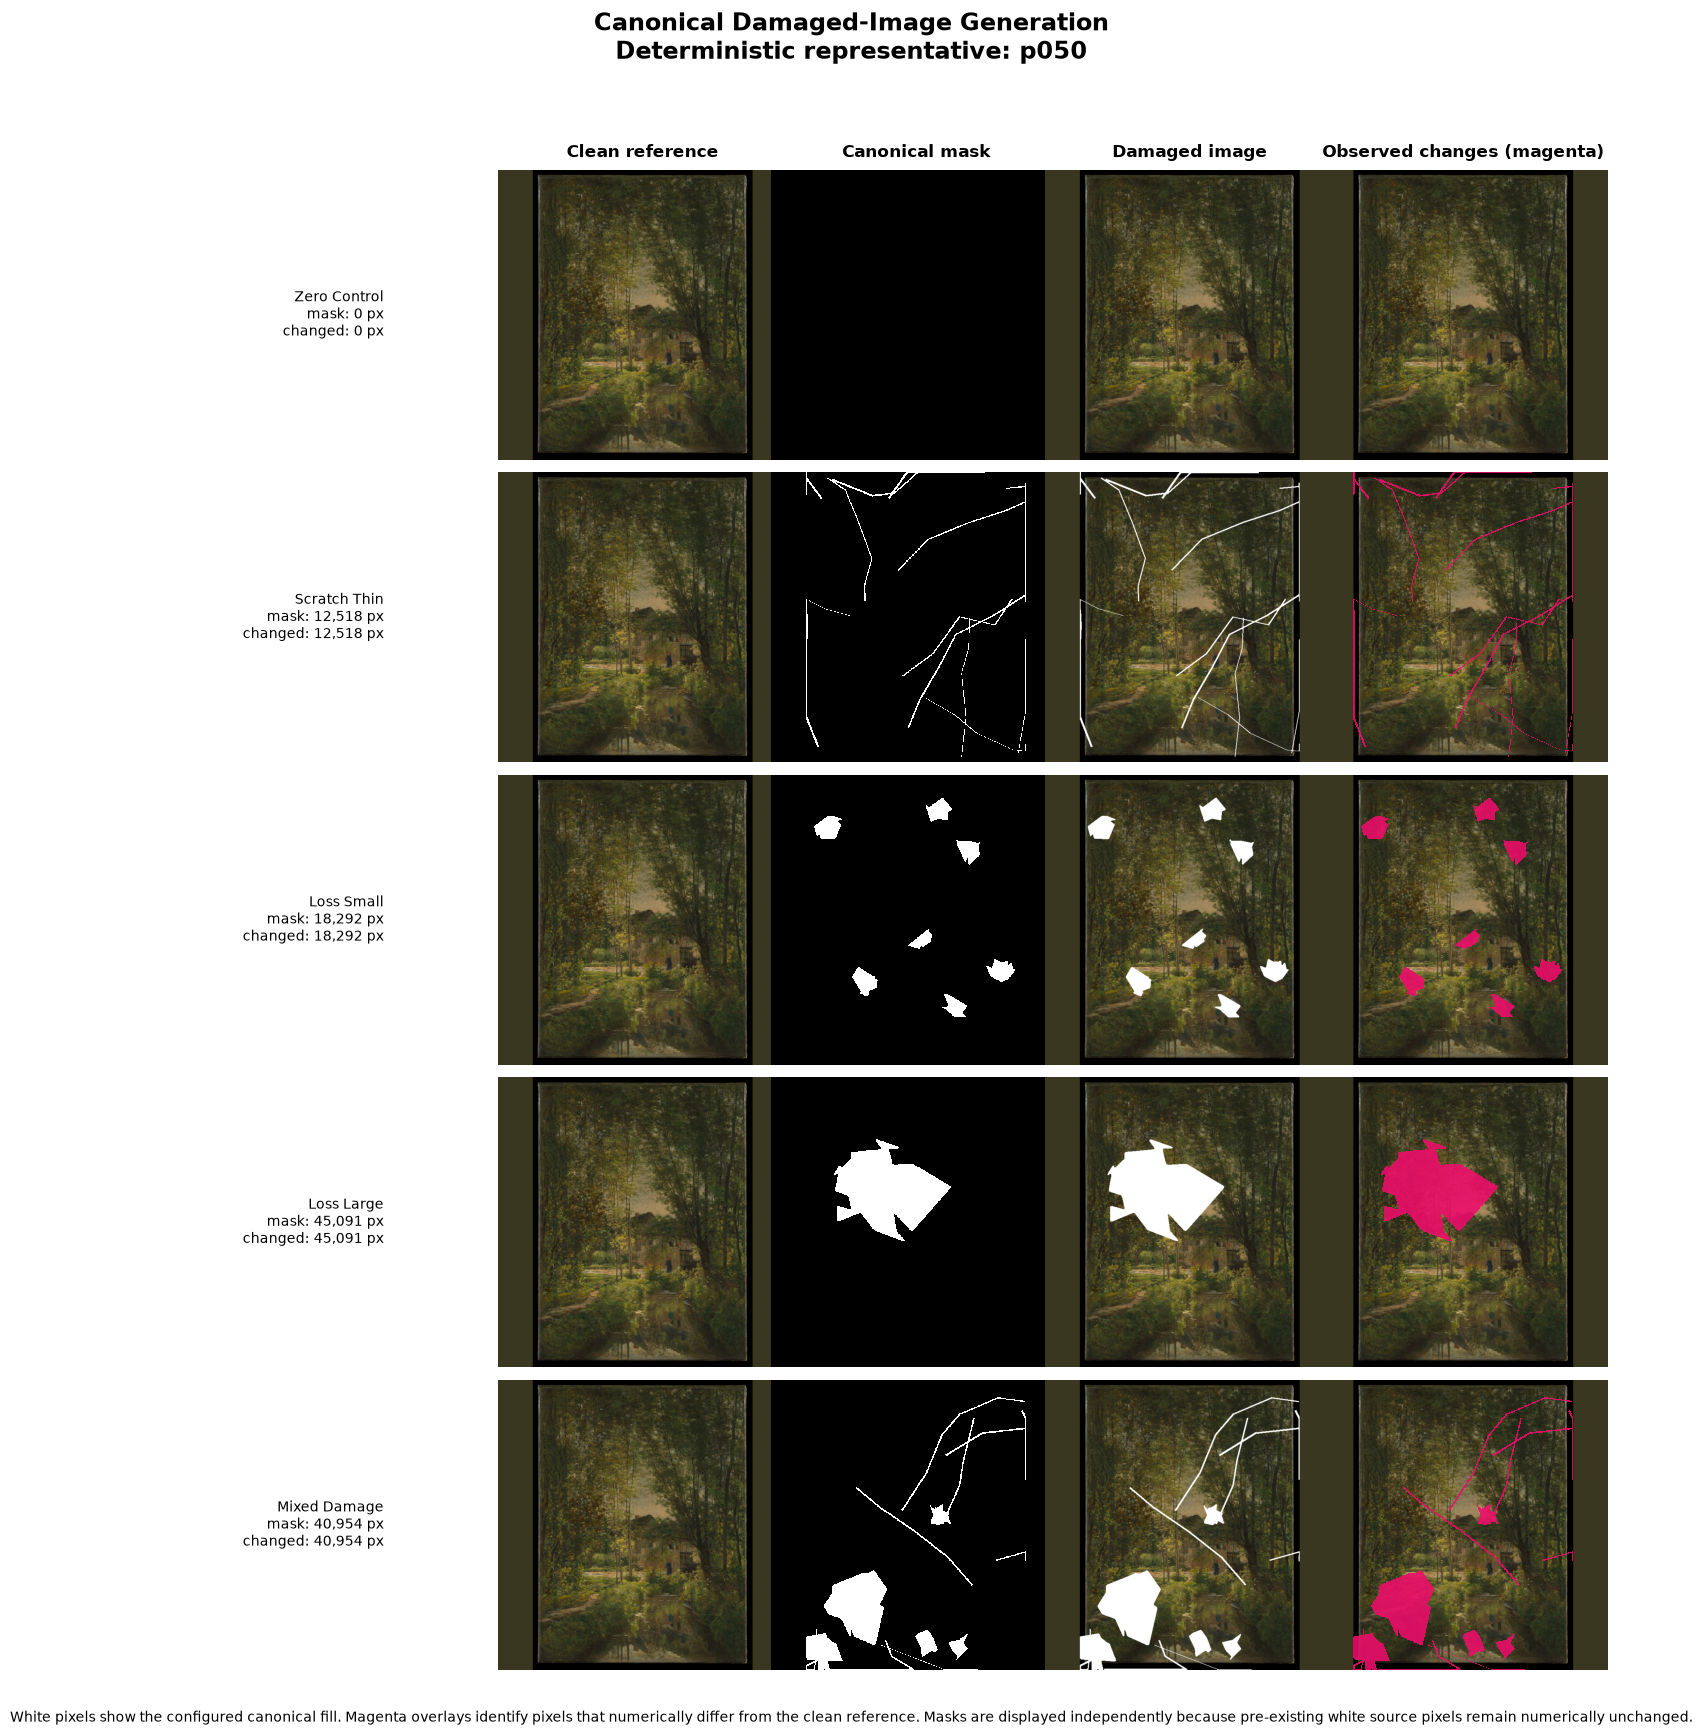

Saved canonical figure: outputs/04_canonical_damaged_image_generation/figures/damage_examples.png
Figure dimensions: (2658, 2776)
Figure mode and format: RGBA PNG
Figure size: 4675145 bytes
Figure SHA-256: d8d2ce87ec741f453d9c19481bb90dd8ab64594577e96d7fa06a89db1f8fff23


In [13]:
# ---------------------------------------------------------------------------
# Canonical damage-example figure
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

from PIL import Image


figure_row_count = len(
    damage_example_cases_df
)

figure_column_count = len(
    EXAMPLE_COLUMNS
)

damage_examples_figure, damage_example_axes = (
    plt.subplots(
        nrows=figure_row_count,
        ncols=figure_column_count,
        figsize=(15.5, 17.5),
        squeeze=False,
    )
)

column_titles = {
    "clean": "Clean reference",
    "mask": "Canonical mask",
    "damaged": "Damaged image",
    "changed_pixels": (
        "Observed changes (magenta)"
    ),
}

damage_example_render_records = []

fill_color_array = np.asarray(
    damage_config["generator"][
        "fill_color_rgb"
    ],
    dtype=np.uint8,
)


for row_index, case_row in enumerate(
    damage_example_cases_df.itertuples(
        index=False
    )
):
    clean_path = resolve_repo_path(
        case_row.clean_image_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    mask_path = resolve_repo_path(
        case_row.mask_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    damaged_path = resolve_repo_path(
        case_row.damaged_image_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    with Image.open(clean_path) as source:
        source.load()
        clean_array = np.asarray(
            source.convert("RGB"),
            dtype=np.uint8,
        ).copy()

    with Image.open(mask_path) as source:
        source.load()
        mask_array = np.asarray(
            source.convert("L"),
            dtype=np.uint8,
        ).copy()

    with Image.open(damaged_path) as source:
        source.load()
        damaged_array = np.asarray(
            source.convert("RGB"),
            dtype=np.uint8,
        ).copy()

    binary_mask_array = mask_array == 255

    changed_pixel_array = np.any(
        clean_array != damaged_array,
        axis=2,
    )

    render_mask_pixels = int(
        binary_mask_array.sum()
    )

    render_changed_pixels = int(
        changed_pixel_array.sum()
    )

    render_outside_changes = int(
        changed_pixel_array[
            ~binary_mask_array
        ].sum()
    )

    render_inside_fill_failures = (
        int(
            np.any(
                damaged_array[
                    binary_mask_array
                ]
                != fill_color_array,
                axis=1,
            ).sum()
        )
        if render_mask_pixels
        else 0
    )

    damage_example_render_records.append(
        {
            "case_id": case_row.case_id,
            "painting_id": (
                case_row.painting_id
            ),
            "mask_type": case_row.mask_type,
            "render_mask_pixels": (
                render_mask_pixels
            ),
            "render_changed_pixels": (
                render_changed_pixels
            ),
            "render_outside_changes": (
                render_outside_changes
            ),
            "render_inside_fill_failures": (
                render_inside_fill_failures
            ),
        }
    )

    change_overlay = np.zeros(
        (
            changed_pixel_array.shape[0],
            changed_pixel_array.shape[1],
            4,
        ),
        dtype=np.float32,
    )

    change_overlay[
        changed_pixel_array
    ] = (
        0.94,
        0.05,
        0.42,
        0.88,
    )

    panel_arrays = {
        "clean": clean_array,
        "mask": mask_array,
        "damaged": damaged_array,
        "changed_pixels": (
            clean_array
        ),
    }

    for column_index, column_key in enumerate(
        EXAMPLE_COLUMNS
    ):
        axis = damage_example_axes[
            row_index,
            column_index,
        ]

        if column_key == "mask":
            axis.imshow(
                panel_arrays[column_key],
                cmap="gray",
                vmin=0,
                vmax=255,
                interpolation="nearest",
            )
        else:
            axis.imshow(
                panel_arrays[column_key]
            )

        if column_key == "changed_pixels":
            axis.imshow(
                change_overlay,
                interpolation="nearest",
            )

        if row_index == 0:
            axis.set_title(
                column_titles[column_key],
                fontsize=12,
                fontweight="semibold",
                pad=9,
            )

        axis.set_xticks([])
        axis.set_yticks([])

        for spine in axis.spines.values():
            spine.set_visible(False)

    row_label = (
        case_row.mask_type
        .replace("_", " ")
        .title()
        + "\n"
        + f"mask: {render_mask_pixels:,} px"
        + "\n"
        + f"changed: {render_changed_pixels:,} px"
    )

    damage_example_axes[
        row_index,
        0,
    ].set_ylabel(
        row_label,
        rotation=0,
        ha="right",
        va="center",
        labelpad=82,
        fontsize=10,
    )


example_painting_label = ", ".join(
    example_painting_ids
)

damage_examples_figure.suptitle(
    (
        "Canonical Damaged-Image Generation\n"
        f"Deterministic representative: "
        f"{example_painting_label}"
    ),
    fontsize=17,
    fontweight="semibold",
    y=0.992,
)

damage_examples_figure.text(
    0.5,
    0.012,
    (
        "White pixels show the configured canonical "
        "fill. Magenta overlays identify pixels that "
        "numerically differ from the clean reference. "
        "Masks are displayed independently because "
        "pre-existing white source pixels remain "
        "numerically unchanged."
    ),
    ha="center",
    va="bottom",
    fontsize=10,
)

damage_examples_figure.tight_layout(
    rect=(
        0.105,
        0.035,
        1.0,
        0.965,
    ),
    h_pad=0.9,
    w_pad=0.45,
)


# ---------------------------------------------------------------------------
# Atomic figure persistence
# ---------------------------------------------------------------------------

damage_examples_figure_path = OUTPUT_PATHS[
    "damage_examples_figure"
]

damage_examples_figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

damage_examples_temporary_path = (
    damage_examples_figure_path.with_name(
        (
            f".{damage_examples_figure_path.stem}"
            f".tmp"
            f"{damage_examples_figure_path.suffix}"
        )
    )
)

try:
    damage_examples_figure.savefig(
        damage_examples_temporary_path,
        dpi=EXAMPLE_FIGURE_DPI,
        bbox_inches="tight",
        facecolor="white",
        metadata={
            "Title": (
                "Notebook 04 Canonical "
                "Damaged-Image Examples"
            ),
            "Creator": NOTEBOOK_STEM,
            "Description": (
                "Clean, canonical mask, damaged, "
                "and observed-change views for the "
                "deterministically selected example."
            ),
        },
    )

    damage_examples_temporary_path.replace(
        damage_examples_figure_path
    )

finally:
    damage_examples_temporary_path.unlink(
        missing_ok=True
    )


# ---------------------------------------------------------------------------
# Immediate figure reload
# ---------------------------------------------------------------------------

with Image.open(
    damage_examples_figure_path
) as reloaded_figure:
    reloaded_figure.load()

    damage_examples_figure_width = int(
        reloaded_figure.width
    )

    damage_examples_figure_height = int(
        reloaded_figure.height
    )

    damage_examples_figure_mode = str(
        reloaded_figure.mode
    )

    damage_examples_figure_format = str(
        reloaded_figure.format
    )

    reloaded_dpi_value = (
        reloaded_figure.info.get("dpi")
    )


damage_examples_figure_sha256 = sha256_file(
    damage_examples_figure_path
)

damage_examples_figure_size_bytes = int(
    damage_examples_figure_path.stat().st_size
)

damage_example_render_audit_df = pd.DataFrame(
    damage_example_render_records
)

damage_examples_figure_metadata = {
    "relative_path": to_repo_relative(
        damage_examples_figure_path,
        PROJECT_ROOT,
    ),
    "sha256": (
        damage_examples_figure_sha256
    ),
    "size_bytes": (
        damage_examples_figure_size_bytes
    ),
    "width": (
        damage_examples_figure_width
    ),
    "height": (
        damage_examples_figure_height
    ),
    "mode": damage_examples_figure_mode,
    "format": damage_examples_figure_format,
    "dpi": reloaded_dpi_value,
    "painting_ids": list(
        example_painting_ids
    ),
    "mask_types": list(
        EXPECTED_MASK_TYPES
    ),
    "columns": list(
        EXAMPLE_COLUMNS
    ),
    "panel_count": (
        figure_row_count
        * figure_column_count
    ),
}


display(
    damage_examples_figure
)

plt.close(
    damage_examples_figure
)

print(
    "Saved canonical figure:",
    to_repo_relative(
        damage_examples_figure_path,
        PROJECT_ROOT,
    ),
)

print(
    "Figure dimensions:",
    (
        damage_examples_figure_width,
        damage_examples_figure_height,
    ),
)

print(
    "Figure mode and format:",
    damage_examples_figure_mode,
    damage_examples_figure_format,
)

print(
    "Figure size:",
    damage_examples_figure_size_bytes,
    "bytes",
)

print(
    "Figure SHA-256:",
    damage_examples_figure_sha256,
)

In [14]:
# ---------------------------------------------------------------------------
# Batch 6 validation checks
# ---------------------------------------------------------------------------

BATCH_6_START_CHECK_COUNT = len(
    VALIDATION.to_dataframe()
)


def add_analysis_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    """Register one blocking Batch 6 check."""

    VALIDATION.add(
        validation_stage=(
            "analysis_and_visualization"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Summary coverage
# ---------------------------------------------------------------------------

summary_case_counts = (
    damage_summary_by_mask_type_df.set_index(
        "mask_type"
    )["case_count"].to_dict()
)

summary_coverage_passed = (
    tuple(
        damage_summary_by_mask_type_df[
            "mask_type"
        ]
    )
    == EXPECTED_MASK_TYPES
    and len(
        damage_summary_by_mask_type_df
    )
    == EXPECTED_MASK_TYPE_COUNT
    and all(
        int(
            summary_case_counts.get(
                mask_type,
                -1,
            )
        )
        == EXPECTED_PAINTING_COUNT
        for mask_type in EXPECTED_MASK_TYPES
    )
    and int(
        damage_dataset_summary_df.loc[
            0,
            "case_count",
        ]
    )
    == EXPECTED_CASE_COUNT
)

add_analysis_check(
    check_id="damage_summary_coverage",
    description=(
        "Compact summaries cover every canonical "
        "mask type and all 250 validated cases."
    ),
    expected={
        "mask_types": list(
            EXPECTED_MASK_TYPES
        ),
        "cases_per_mask_type": (
            EXPECTED_PAINTING_COUNT
        ),
        "case_count": EXPECTED_CASE_COUNT,
    },
    observed={
        "mask_types": (
            damage_summary_by_mask_type_df[
                "mask_type"
            ].tolist()
        ),
        "case_counts": summary_case_counts,
        "case_count": int(
            damage_dataset_summary_df.loc[
                0,
                "case_count",
            ]
        ),
    },
    passed=summary_coverage_passed,
)


# ---------------------------------------------------------------------------
# 2. Summary numerical reconciliation
# ---------------------------------------------------------------------------

summary_reconciliation_passed = (
    int(
        damage_summary_by_mask_type_df[
            "total_mask_pixels"
        ].sum()
    )
    == int(
        canonical_damage_audit_df[
            "total_mask_pixels"
        ].sum()
    )
    and int(
        damage_summary_by_mask_type_df[
            "preexisting_fill_pixels"
        ].sum()
    )
    == int(
        canonical_damage_audit_df[
            "preexisting_fill_pixel_count"
        ].sum()
    )
    and int(
        damage_summary_by_mask_type_df[
            "expected_changed_pixels"
        ].sum()
    )
    == int(
        canonical_damage_audit_df[
            "expected_changed_pixel_count"
        ].sum()
    )
    and int(
        damage_summary_by_mask_type_df[
            "observed_changed_pixels"
        ].sum()
    )
    == int(
        canonical_damage_audit_df[
            "observed_changed_pixel_count"
        ].sum()
    )
    and damage_summary_by_mask_type_df[
        "expected_changed_pixels"
    ].eq(
        damage_summary_by_mask_type_df[
            "observed_changed_pixels"
        ]
    ).all()
    and int(
        damage_summary_by_mask_type_df[
            "outside_mask_changes"
        ].sum()
    )
    == 0
    and int(
        damage_summary_by_mask_type_df[
            "inside_fill_failures"
        ].sum()
    )
    == 0
    and int(
        damage_summary_by_mask_type_df[
            "failed_case_count"
        ].sum()
    )
    == 0
)

add_analysis_check(
    check_id="damage_summary_reconciliation",
    description=(
        "Compact aggregate values exactly reconcile "
        "with the validated 250-row damage audit."
    ),
    expected={
        "expected_equals_observed": True,
        "outside_mask_changes": 0,
        "inside_fill_failures": 0,
        "failed_cases": 0,
    },
    observed={
        "total_mask_pixels": int(
            damage_summary_by_mask_type_df[
                "total_mask_pixels"
            ].sum()
        ),
        "preexisting_fill_pixels": int(
            damage_summary_by_mask_type_df[
                "preexisting_fill_pixels"
            ].sum()
        ),
        "expected_changed_pixels": int(
            damage_summary_by_mask_type_df[
                "expected_changed_pixels"
            ].sum()
        ),
        "observed_changed_pixels": int(
            damage_summary_by_mask_type_df[
                "observed_changed_pixels"
            ].sum()
        ),
        "outside_mask_changes": int(
            damage_summary_by_mask_type_df[
                "outside_mask_changes"
            ].sum()
        ),
        "inside_fill_failures": int(
            damage_summary_by_mask_type_df[
                "inside_fill_failures"
            ].sum()
        ),
    },
    passed=summary_reconciliation_passed,
)


# ---------------------------------------------------------------------------
# 3. Deterministic representative-selection contract
# ---------------------------------------------------------------------------

selection_contract_passed = (
    EXAMPLE_SELECTION_RULE
    == "same_as_smoke"
    and EXAMPLE_PAINTING_COUNT == 1
    and len(example_painting_ids) == 1
    and example_painting_ids
    == tuple(
        representative_painting_ids[:1]
    )
    and EXAMPLE_COLUMNS
    == EXPECTED_EXAMPLE_COLUMNS
)

add_analysis_check(
    check_id="example_selection_contract",
    description=(
        "The final figure uses the same deterministic "
        "representative selected for the smoke test "
        "and the four configured panel columns."
    ),
    expected={
        "selection_rule": "same_as_smoke",
        "painting_count": 1,
        "painting_ids": list(
            representative_painting_ids[:1]
        ),
        "columns": list(
            EXPECTED_EXAMPLE_COLUMNS
        ),
    },
    observed={
        "selection_rule": (
            EXAMPLE_SELECTION_RULE
        ),
        "painting_count": len(
            example_painting_ids
        ),
        "painting_ids": list(
            example_painting_ids
        ),
        "columns": list(
            EXAMPLE_COLUMNS
        ),
    },
    passed=selection_contract_passed,
    details={
        "resolved_smoke_selection_rule": (
            damage_config["smoke"][
                "selection_rule"
            ]
        ),
    },
)


# ---------------------------------------------------------------------------
# 4. Figure case coverage and ordering
# ---------------------------------------------------------------------------

figure_case_coverage_passed = (
    len(damage_example_cases_df)
    == EXPECTED_MASK_TYPE_COUNT
    and tuple(
        damage_example_cases_df[
            "mask_type"
        ]
    )
    == EXPECTED_MASK_TYPES
    and set(
        damage_example_cases_df[
            "painting_id"
        ]
    )
    == set(example_painting_ids)
    and damage_example_cases_df[
        "validation_status"
    ].eq("passed").all()
)

add_analysis_check(
    check_id="figure_case_coverage",
    description=(
        "The final figure contains one validated row "
        "for every canonical mask type in the "
        "configured order."
    ),
    expected={
        "row_count": (
            EXPECTED_MASK_TYPE_COUNT
        ),
        "mask_types": list(
            EXPECTED_MASK_TYPES
        ),
        "failed_cases": 0,
    },
    observed={
        "row_count": len(
            damage_example_cases_df
        ),
        "mask_types": (
            damage_example_cases_df[
                "mask_type"
            ].tolist()
        ),
        "failed_cases": int(
            damage_example_cases_df[
                "validation_status"
            ].ne("passed").sum()
        ),
    },
    passed=figure_case_coverage_passed,
)


# ---------------------------------------------------------------------------
# 5. Render-source pixel integrity
# ---------------------------------------------------------------------------

render_comparison_df = (
    damage_example_render_audit_df.merge(
        canonical_damage_audit_df[
            [
                "case_id",
                "total_mask_pixels",
                "observed_changed_pixel_count",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)

render_integrity_failure_df = (
    render_comparison_df.loc[
        ~(
            render_comparison_df[
                "render_mask_pixels"
            ].eq(
                render_comparison_df[
                    "total_mask_pixels"
                ]
            )
            & render_comparison_df[
                "render_changed_pixels"
            ].eq(
                render_comparison_df[
                    "observed_changed_pixel_count"
                ]
            )
            & render_comparison_df[
                "render_outside_changes"
            ].eq(0)
            & render_comparison_df[
                "render_inside_fill_failures"
            ].eq(0)
        )
    ].copy()
)

render_source_integrity_passed = (
    len(render_comparison_df)
    == EXPECTED_MASK_TYPE_COUNT
    and render_integrity_failure_df.empty
)

add_analysis_check(
    check_id="figure_render_source_integrity",
    description=(
        "The pixel arrays used to render the figure "
        "reconcile with the canonical audit and "
        "preserve all corruption invariants."
    ),
    expected={
        "rendered_cases": (
            EXPECTED_MASK_TYPE_COUNT
        ),
        "failed_cases": 0,
        "outside_mask_changes": 0,
        "inside_fill_failures": 0,
    },
    observed={
        "rendered_cases": len(
            render_comparison_df
        ),
        "failed_cases": len(
            render_integrity_failure_df
        ),
        "outside_mask_changes": int(
            render_comparison_df[
                "render_outside_changes"
            ].sum()
        ),
        "inside_fill_failures": int(
            render_comparison_df[
                "render_inside_fill_failures"
            ].sum()
        ),
    },
    passed=render_source_integrity_passed,
    details=(
        render_integrity_failure_df.to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 6. Persisted figure contract
# ---------------------------------------------------------------------------

figure_contract_passed = (
    damage_examples_figure_path.is_file()
    and damage_examples_figure_size_bytes > 0
    and damage_examples_figure_width > 0
    and damage_examples_figure_height > 0
    and damage_examples_figure_mode
    in {
        "RGB",
        "RGBA",
    }
    and damage_examples_figure_format == "PNG"
    and len(
        damage_examples_figure_sha256
    )
    == 64
    and (
        figure_row_count
        * figure_column_count
    )
    == 20
)

add_analysis_check(
    check_id="damage_examples_figure_contract",
    description=(
        "The contracted damage-example figure was "
        "saved, reloaded, hashed, and contains the "
        "planned five-by-four panel design."
    ),
    expected={
        "format": "PNG",
        "allowed_modes": [
            "RGB",
            "RGBA",
        ],
        "panel_count": 20,
        "positive_dimensions": True,
        "positive_size": True,
    },
    observed=(
        damage_examples_figure_metadata
    ),
    passed=figure_contract_passed,
)


# ---------------------------------------------------------------------------
# 7. Batch 6 persistence scope and hygiene
# ---------------------------------------------------------------------------

expected_batch_6_files = {
    resolve_repo_path(
        relative_path,
        PROJECT_ROOT,
        must_exist=True,
    ).resolve()
    for relative_path in (
        canonical_damage_cases_df[
            "damaged_image_path"
        ].astype(str)
    )
}

expected_batch_6_files.add(
    damage_examples_figure_path.resolve()
)

actual_batch_6_files = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

missing_batch_6_files = sorted(
    expected_batch_6_files
    - actual_batch_6_files
)

unexpected_batch_6_files = sorted(
    actual_batch_6_files
    - expected_batch_6_files
)

temporary_batch_6_files = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and (
            ".tmp" in path.name.lower()
            or path.suffix.lower()
            in {
                ".part",
                ".temp",
            }
        )
    )
)

deferred_persistence_paths = [
    OUTPUT_PATHS[
        "canonical_damage_cases"
    ],
    OUTPUT_PATHS["damage_audit"],
    OUTPUT_PATHS[
        "validation_checks"
    ],
    OUTPUT_PATHS[
        "artifact_manifest"
    ],
    OUTPUT_PATHS["run_manifest"],
]

premature_persisted_paths = [
    path
    for path in deferred_persistence_paths
    if path.exists()
]

batch_6_scope_passed = (
    len(actual_batch_6_files)
    == EXPECTED_CASE_COUNT + 1
    and not missing_batch_6_files
    and not unexpected_batch_6_files
    and not temporary_batch_6_files
    and not premature_persisted_paths
)

add_analysis_check(
    check_id="batch_6_persistence_scope",
    description=(
        "Batch 6 retains the 250 damaged PNGs and "
        "adds only the contracted example figure; "
        "tables and manifests remain deferred."
    ),
    expected={
        "file_count": (
            EXPECTED_CASE_COUNT + 1
        ),
        "missing": 0,
        "unexpected": 0,
        "temporary": 0,
        "premature_tables_or_manifests": 0,
    },
    observed={
        "file_count": len(
            actual_batch_6_files
        ),
        "missing": len(
            missing_batch_6_files
        ),
        "unexpected": len(
            unexpected_batch_6_files
        ),
        "temporary": len(
            temporary_batch_6_files
        ),
        "premature_tables_or_manifests": len(
            premature_persisted_paths
        ),
    },
    passed=batch_6_scope_passed,
    details={
        "missing": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in missing_batch_6_files
        ],
        "unexpected": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in unexpected_batch_6_files
        ],
        "temporary": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in temporary_batch_6_files
        ],
        "premature": [
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in premature_persisted_paths
        ],
    },
)


# ---------------------------------------------------------------------------
# Batch 6 completion
# ---------------------------------------------------------------------------

all_checks_after_batch_6_df = (
    VALIDATION.to_dataframe()
)

BATCH_6_CHECK_COUNT = (
    len(all_checks_after_batch_6_df)
    - BATCH_6_START_CHECK_COUNT
)

batch_6_checks_df = (
    all_checks_after_batch_6_df.tail(
        BATCH_6_CHECK_COUNT
    ).reset_index(drop=True)
)


display(
    batch_6_checks_df[
        [
            "check_id",
            "severity",
            "passed",
            "observed",
        ]
    ]
)


assert BATCH_6_CHECK_COUNT == 7, (
    "Batch 6 must add exactly seven checks."
)

VALIDATION.raise_for_blocking()


print(
    "\nBatch 6 completed successfully."
)

print(
    "Batch 6 checks:",
    BATCH_6_CHECK_COUNT,
)

print(
    "Accumulated checks:",
    len(all_checks_after_batch_6_df),
)

print(
    "Blocking failures:",
    len(VALIDATION.blocking_failures),
)

print(
    "Persisted Notebook 04 files:",
    len(actual_batch_6_files),
)

print(
    "Canonical figure:",
    to_repo_relative(
        damage_examples_figure_path,
        PROJECT_ROOT,
    ),
)

print(
    "Canonical tables remain in memory:",
    canonical_damage_cases_df.shape,
    canonical_damage_audit_df.shape,
)

print(
    "Next approved stage: Batch 7 - canonical "
    "persistence, validation table, and manifests."
)

,check_id,severity,passed,observed
0,damage_summary_coverage,blocking,True,"{""case_count"": 250, ""case_counts"": {""loss_larg..."
1,damage_summary_reconciliation,blocking,True,"{""expected_changed_pixels"": 6545871, ""inside_f..."
2,example_selection_contract,blocking,True,"{""columns"": [""clean"", ""mask"", ""damaged"", ""chan..."
3,figure_case_coverage,blocking,True,"{""failed_cases"": 0, ""mask_types"": [""zero_contr..."
4,figure_render_source_integrity,blocking,True,"{""failed_cases"": 0, ""inside_fill_failures"": 0,..."
5,damage_examples_figure_contract,blocking,True,"{""columns"": [""clean"", ""mask"", ""damaged"", ""chan..."
6,batch_6_persistence_scope,blocking,True,"{""file_count"": 251, ""missing"": 0, ""premature_t..."



Batch 6 completed successfully.
Batch 6 checks: 7
Accumulated checks: 60
Blocking failures: 0
Persisted Notebook 04 files: 251
Canonical figure: outputs/04_canonical_damaged_image_generation/figures/damage_examples.png
Canonical tables remain in memory: (250, 34) (250, 40)
Next approved stage: Batch 7 - canonical persistence, validation table, and manifests.


## Batch 7 — Canonical persistence and normalized manifests

This batch persists the validated canonical handoff:

- `data/cases.csv`;
- `metrics/damage_audit.csv`;
- `validation/checks.csv`;
- `manifests/artifacts.csv`;
- a provisional `manifests/run_manifest.json`.

The 60 consolidated scientific and filesystem checks remain distinct from the
separate persistence and manifest-handoff gates. The run manifest remains in a
`running` state until Batch 8 performs the final independent reload, completion
gate, project-path registry update, and completed-manifest rewrite.

In [15]:
# ---------------------------------------------------------------------------
# Batch 7 helper imports
# ---------------------------------------------------------------------------

from restoration_eval.damage import (
    write_dataframe_atomic,
)

from restoration_eval.manifests import (
    RUN_MANIFEST_SCHEMA_VERSION,
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    sha256_path,
    write_artifact_manifest,
    write_run_manifest,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
)


EXPECTED_CONSOLIDATED_VALIDATION_ROWS = 60


# ---------------------------------------------------------------------------
# Pre-persistence gate
# ---------------------------------------------------------------------------

if not VALIDATION.overall_passed:
    raise RuntimeError(
        "The consolidated Notebook 04 validation "
        "gate has not passed."
    )

validation_checks_df = (
    VALIDATION.to_dataframe()
)

if len(validation_checks_df) != (
    EXPECTED_CONSOLIDATED_VALIDATION_ROWS
):
    raise RuntimeError(
        "Exactly "
        f"{EXPECTED_CONSOLIDATED_VALIDATION_ROWS} "
        "consolidated validation rows are required; "
        f"found {len(validation_checks_df)}."
    )

if len(canonical_damage_cases_df) != (
    EXPECTED_CASE_COUNT
):
    raise RuntimeError(
        "The canonical case table does not contain "
        "the expected number of rows."
    )

if len(canonical_damage_audit_df) != (
    EXPECTED_AUDIT_ROW_COUNT
):
    raise RuntimeError(
        "The canonical damage audit does not contain "
        "the expected number of rows."
    )


# ---------------------------------------------------------------------------
# Validate ownership of every declared output
# ---------------------------------------------------------------------------

output_ownership_failures = []

for output_key, output_path in OUTPUT_PATHS.items():
    try:
        validated_output_path = (
            require_notebook_output_path(
                output_path,
                NOTEBOOK_STEM,
                PROJECT_ROOT,
            )
        )

        if (
            validated_output_path
            != output_path.resolve()
        ):
            output_ownership_failures.append(
                {
                    "output_key": output_key,
                    "path": str(output_path),
                    "issue": (
                        "resolved_path_mismatch"
                    ),
                }
            )

    except Exception as exc:
        output_ownership_failures.append(
            {
                "output_key": output_key,
                "path": str(output_path),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )

if output_ownership_failures:
    raise RuntimeError(
        "One or more output paths violate "
        "Notebook 04 ownership: "
        f"{output_ownership_failures}"
    )


# ---------------------------------------------------------------------------
# Atomic canonical CSV persistence
# ---------------------------------------------------------------------------

write_dataframe_atomic(
    canonical_damage_cases_df,
    OUTPUT_PATHS[
        "canonical_damage_cases"
    ],
)

write_dataframe_atomic(
    canonical_damage_audit_df,
    OUTPUT_PATHS["damage_audit"],
)

write_dataframe_atomic(
    validation_checks_df,
    OUTPUT_PATHS["validation_checks"],
)


# ---------------------------------------------------------------------------
# Immediate canonical reload
# ---------------------------------------------------------------------------

canonical_damage_cases_reloaded_df = (
    pd.read_csv(
        OUTPUT_PATHS[
            "canonical_damage_cases"
        ],
        low_memory=False,
    )
)

canonical_damage_audit_reloaded_df = (
    pd.read_csv(
        OUTPUT_PATHS["damage_audit"],
        low_memory=False,
    )
)

validation_checks_reloaded_df = (
    pd.read_csv(
        OUTPUT_PATHS[
            "validation_checks"
        ],
        low_memory=False,
    )
)


cases_reload_schema_result = (
    validate_dataframe(
        canonical_damage_cases_reloaded_df,
        CANONICAL_DAMAGE_CASES_SCHEMA,
        allow_extra_columns=False,
    )
)

audit_reload_schema_result = (
    validate_dataframe(
        canonical_damage_audit_reloaded_df,
        CANONICAL_DAMAGE_AUDIT_SCHEMA,
        allow_extra_columns=False,
    )
)

validation_reload_schema_result = (
    validate_dataframe(
        validation_checks_reloaded_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Reload identity evidence
# ---------------------------------------------------------------------------

expected_case_ids = set(
    canonical_damage_cases_df[
        "case_id"
    ].astype(str)
)

reloaded_case_ids = set(
    canonical_damage_cases_reloaded_df[
        "case_id"
    ].astype(str)
)

expected_damaged_paths = set(
    canonical_damage_cases_df[
        "damaged_image_path"
    ].astype(str)
)

reloaded_damaged_paths = set(
    canonical_damage_cases_reloaded_df[
        "damaged_image_path"
    ].astype(str)
)

expected_audit_case_ids = set(
    canonical_damage_audit_df[
        "case_id"
    ].astype(str)
)

reloaded_audit_case_ids = set(
    canonical_damage_audit_reloaded_df[
        "case_id"
    ].astype(str)
)

expected_validation_keys = {
    (
        str(check.validation_stage),
        str(check.check_id),
    )
    for check in VALIDATION.checks
}

reloaded_validation_keys = {
    (
        str(row.validation_stage),
        str(row.check_id),
    )
    for row in (
        validation_checks_reloaded_df
        .itertuples(index=False)
    )
}

reloaded_validation_passed_values = (
    validation_checks_reloaded_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
)

all_reloaded_validation_checks_passed = bool(
    reloaded_validation_passed_values
    .eq("true")
    .all()
)


# ---------------------------------------------------------------------------
# Reload collection and figure evidence
# ---------------------------------------------------------------------------

reloaded_damaged_files = sorted(
    path
    for path in DAMAGED_IMAGE_DIRECTORY.rglob(
        "*.png"
    )
    if path.is_file()
)

reloaded_damaged_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in reloaded_damaged_files
}

damaged_checksum_failures = []

for case_row in (
    canonical_damage_cases_reloaded_df
    .itertuples(index=False)
):
    damaged_path = resolve_repo_path(
        case_row.damaged_image_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    observed_checksum = sha256_file(
        damaged_path
    )

    if observed_checksum != str(
        case_row.damaged_image_sha256
    ):
        damaged_checksum_failures.append(
            {
                "case_id": case_row.case_id,
                "relative_path": (
                    case_row.damaged_image_path
                ),
                "expected_checksum": (
                    case_row.damaged_image_sha256
                ),
                "observed_checksum": (
                    observed_checksum
                ),
            }
        )


with Image.open(
    OUTPUT_PATHS[
        "damage_examples_figure"
    ]
) as figure_file:
    figure_file.load()

    persisted_figure_evidence = {
        "format": str(
            figure_file.format
        ),
        "mode": str(
            figure_file.mode
        ),
        "width": int(
            figure_file.width
        ),
        "height": int(
            figure_file.height
        ),
        "sha256": sha256_file(
            OUTPUT_PATHS[
                "damage_examples_figure"
            ]
        ),
    }


# ---------------------------------------------------------------------------
# Separate canonical-persistence validation gate
# ---------------------------------------------------------------------------

PERSISTENCE_VALIDATION = (
    ValidationCollector()
)


PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="output_path_ownership",
    check_description=(
        "Every declared output remains inside the "
        "exact Notebook 04 output root."
    ),
    severity="blocking",
    expected=[],
    observed=output_ownership_failures,
    passed=not output_ownership_failures,
)


cases_reload_passed = (
    cases_reload_schema_result.passed
    and not (
        cases_reload_schema_result
        .unexpected_columns
    )
    and len(
        canonical_damage_cases_reloaded_df
    )
    == EXPECTED_CASE_COUNT
    and reloaded_case_ids
    == expected_case_ids
    and reloaded_damaged_paths
    == expected_damaged_paths
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="canonical_cases_csv_reload",
    check_description=(
        "Persisted cases.csv reloads under "
        "canonical_damage_cases.v1 with all expected "
        "case identities and damaged-image paths."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED_CASE_COUNT,
        "schema_passed": True,
        "case_ids_match": True,
        "paths_match": True,
    },
    observed={
        "rows": len(
            canonical_damage_cases_reloaded_df
        ),
        "schema": (
            cases_reload_schema_result.to_dict()
        ),
        "case_ids_match": (
            reloaded_case_ids
            == expected_case_ids
        ),
        "paths_match": (
            reloaded_damaged_paths
            == expected_damaged_paths
        ),
    },
    passed=cases_reload_passed,
)


audit_reload_passed = (
    audit_reload_schema_result.passed
    and not (
        audit_reload_schema_result
        .unexpected_columns
    )
    and len(
        canonical_damage_audit_reloaded_df
    )
    == EXPECTED_AUDIT_ROW_COUNT
    and reloaded_audit_case_ids
    == expected_audit_case_ids
    and canonical_damage_audit_reloaded_df[
        "validation_status"
    ].eq("passed").all()
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="damage_audit_csv_reload",
    check_description=(
        "Persisted damage_audit.csv reloads under "
        "canonical_damage_audit.v1 with all expected "
        "passing case identities."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED_AUDIT_ROW_COUNT,
        "schema_passed": True,
        "case_ids_match": True,
        "failed_cases": 0,
    },
    observed={
        "rows": len(
            canonical_damage_audit_reloaded_df
        ),
        "schema": (
            audit_reload_schema_result.to_dict()
        ),
        "case_ids_match": (
            reloaded_audit_case_ids
            == expected_audit_case_ids
        ),
        "failed_cases": int(
            canonical_damage_audit_reloaded_df[
                "validation_status"
            ].ne("passed").sum()
        ),
    },
    passed=audit_reload_passed,
)


validation_csv_reload_passed = (
    validation_reload_schema_result.passed
    and not (
        validation_reload_schema_result
        .unexpected_columns
    )
    and len(
        validation_checks_reloaded_df
    )
    == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    and reloaded_validation_keys
    == expected_validation_keys
    and all_reloaded_validation_checks_passed
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="validation_checks_csv_reload",
    check_description=(
        "Persisted checks.csv reloads under "
        "validation_checks.v1 with all 60 unique "
        "passing consolidated checks."
    ),
    severity="blocking",
    expected={
        "rows": (
            EXPECTED_CONSOLIDATED_VALIDATION_ROWS
        ),
        "schema_passed": True,
        "keys_match": True,
        "all_passed": True,
    },
    observed={
        "rows": len(
            validation_checks_reloaded_df
        ),
        "schema": (
            validation_reload_schema_result
            .to_dict()
        ),
        "keys_match": (
            reloaded_validation_keys
            == expected_validation_keys
        ),
        "all_passed": (
            all_reloaded_validation_checks_passed
        ),
    },
    passed=validation_csv_reload_passed,
)


damaged_collection_reload_passed = (
    len(reloaded_damaged_files)
    == EXPECTED_CASE_COUNT
    and reloaded_damaged_relative_paths
    == expected_damaged_paths
    and not damaged_checksum_failures
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="damaged_collection_reload",
    check_description=(
        "The persisted damaged-image collection "
        "contains exactly the 250 declared PNGs and "
        "every image matches its case-table checksum."
    ),
    severity="blocking",
    expected={
        "file_count": EXPECTED_CASE_COUNT,
        "paths_match": True,
        "checksum_failures": 0,
    },
    observed={
        "file_count": len(
            reloaded_damaged_files
        ),
        "paths_match": (
            reloaded_damaged_relative_paths
            == expected_damaged_paths
        ),
        "checksum_failures": len(
            damaged_checksum_failures
        ),
    },
    passed=damaged_collection_reload_passed,
    details=damaged_checksum_failures,
)


figure_reload_passed = (
    persisted_figure_evidence[
        "format"
    ]
    == "PNG"
    and persisted_figure_evidence[
        "mode"
    ]
    in {
        "RGB",
        "RGBA",
    }
    and persisted_figure_evidence[
        "width"
    ]
    > 0
    and persisted_figure_evidence[
        "height"
    ]
    > 0
    and persisted_figure_evidence[
        "sha256"
    ]
    == damage_examples_figure_sha256
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="damage_examples_figure_reload",
    check_description=(
        "The canonical example figure reloads as a "
        "readable PNG and retains its Batch 6 "
        "checksum."
    ),
    severity="blocking",
    expected={
        "format": "PNG",
        "allowed_modes": [
            "RGB",
            "RGBA",
        ],
        "positive_dimensions": True,
        "checksum": (
            damage_examples_figure_sha256
        ),
    },
    observed=persisted_figure_evidence,
    passed=figure_reload_passed,
)


persistence_checks_df = (
    PERSISTENCE_VALIDATION.to_dataframe()
)

if len(persistence_checks_df) != 6:
    raise RuntimeError(
        "Batch 7 must produce exactly six "
        "canonical-persistence checks."
    )

PERSISTENCE_VALIDATION.raise_for_blocking()


print(
    "Canonical persistence validation passed:",
    PERSISTENCE_VALIDATION.overall_passed,
)

display(
    persistence_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

print(
    "Persisted canonical cases:",
    canonical_damage_cases_reloaded_df.shape,
)

print(
    "Persisted damage audit:",
    canonical_damage_audit_reloaded_df.shape,
)

print(
    "Persisted consolidated checks:",
    validation_checks_reloaded_df.shape,
)

Canonical persistence validation passed: True


,check_id,severity,passed
0,output_path_ownership,blocking,True
1,canonical_cases_csv_reload,blocking,True
2,damage_audit_csv_reload,blocking,True
3,validation_checks_csv_reload,blocking,True
4,damaged_collection_reload,blocking,True
5,damage_examples_figure_reload,blocking,True


Persisted canonical cases: (250, 34)
Persisted damage audit: (250, 40)
Persisted consolidated checks: (60, 8)


In [16]:
# ---------------------------------------------------------------------------
# Normalized artifact manifest
# ---------------------------------------------------------------------------

dataset_scope = str(
    damage_config["dataset"][
        "dataset_scope"
    ]
)

experiment_id = str(
    damage_config["dataset"][
        "experiment_id"
    ]
)

artifact_specifications = [
    {
        "artifact_key": (
            "canonical_damage_cases"
        ),
        "path": OUTPUT_PATHS[
            "canonical_damage_cases"
        ],
        "artifact_type": "dataset_table",
        "output_key": (
            "canonical_damage_cases"
        ),
        "row_count": len(
            canonical_damage_cases_reloaded_df
        ),
    },
    {
        "artifact_key": "damaged_images",
        "path": OUTPUT_PATHS[
            "damaged_images"
        ],
        "artifact_type": (
            "image_collection"
        ),
        "output_key": "damaged_images",
        "row_count": len(
            reloaded_damaged_files
        ),
    },
    {
        "artifact_key": "damage_audit",
        "path": OUTPUT_PATHS[
            "damage_audit"
        ],
        "artifact_type": "audit_table",
        "output_key": "damage_audit",
        "row_count": len(
            canonical_damage_audit_reloaded_df
        ),
    },
    {
        "artifact_key": "damage_examples",
        "path": OUTPUT_PATHS[
            "damage_examples_figure"
        ],
        "artifact_type": "figure",
        "output_key": (
            "damage_examples_figure"
        ),
        "row_count": None,
    },
    {
        "artifact_key": (
            "validation_checks"
        ),
        "path": OUTPUT_PATHS[
            "validation_checks"
        ],
        "artifact_type": (
            "validation_table"
        ),
        "output_key": (
            "validation_checks"
        ),
        "row_count": len(
            validation_checks_reloaded_df
        ),
    },
]


artifact_records = [
    build_artifact_record(
        artifact_key=specification[
            "artifact_key"
        ],
        producer_notebook=NOTEBOOK_STEM,
        path=specification["path"],
        artifact_type=specification[
            "artifact_type"
        ],
        artifact_role=OUTPUTS[
            specification["output_key"]
        ]["artifact_role"],
        schema_version=OUTPUTS[
            specification["output_key"]
        ]["schema_version"],
        dataset_scope=dataset_scope,
        experiment_id=experiment_id,
        validation_status="passed",
        row_count=specification[
            "row_count"
        ],
        project_root=PROJECT_ROOT,
    )
    for specification
    in artifact_specifications
]

artifact_manifest_df = (
    artifact_records_dataframe(
        artifact_records
    )
)

if len(artifact_manifest_df) != (
    EXPECTED_ARTIFACT_RECORD_COUNT
):
    raise RuntimeError(
        "The artifact manifest does not contain "
        "the expected five records."
    )

write_artifact_manifest(
    OUTPUT_PATHS[
        "artifact_manifest"
    ],
    artifact_records,
)


# ---------------------------------------------------------------------------
# Universal run-manifest inputs and outputs
# ---------------------------------------------------------------------------

run_inputs = [
    {
        "input_key": input_key,
        **dict(input_contract),
    }
    for input_key, input_contract
    in INPUTS.items()
]

run_outputs = [
    {
        "output_key": output_key,
        **dict(output_contract),
    }
    for output_key, output_contract
    in OUTPUTS.items()
]


configuration_paths = [
    to_repo_relative(
        DAMAGE_CONFIG_PATH,
        PROJECT_ROOT,
    )
]

configuration_checksums_by_path = (
    configuration_checksums(
        [
            DAMAGE_CONFIG_PATH,
        ],
        PROJECT_ROOT,
    )
)


family_counts = {
    str(mask_type): int(count)
    for mask_type, count
    in (
        canonical_damage_cases_reloaded_df[
            "mask_type"
        ]
        .value_counts(sort=False)
        .items()
    )
}


expected_run_counts = {
    "painting_rows": (
        EXPECTED_PAINTING_COUNT
    ),
    "mask_families": (
        EXPECTED_MASK_TYPE_COUNT
    ),
    "canonical_damage_rows": (
        EXPECTED_CASE_COUNT
    ),
    "damaged_image_files": (
        EXPECTED_CASE_COUNT
    ),
    "damage_audit_rows": (
        EXPECTED_AUDIT_ROW_COUNT
    ),
    "validation_rows": (
        EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    ),
    "artifact_records": (
        EXPECTED_ARTIFACT_RECORD_COUNT
    ),
    "canonical_figures": 1,
}


observed_run_counts = {
    "painting_rows": int(
        canonical_damage_cases_reloaded_df[
            "painting_id"
        ].nunique()
    ),
    "mask_families": int(
        canonical_damage_cases_reloaded_df[
            "mask_type"
        ].nunique()
    ),
    "canonical_damage_rows": len(
        canonical_damage_cases_reloaded_df
    ),
    "damaged_image_files": len(
        reloaded_damaged_files
    ),
    "damage_audit_rows": len(
        canonical_damage_audit_reloaded_df
    ),
    "validation_rows": len(
        validation_checks_reloaded_df
    ),
    "artifact_records": len(
        artifact_manifest_df
    ),
    "canonical_figures": 1,
    "family_counts": family_counts,
    "total_mask_pixels": int(
        canonical_damage_audit_reloaded_df[
            "total_mask_pixels"
        ].sum()
    ),
    "preexisting_fill_pixels": int(
        canonical_damage_audit_reloaded_df[
            "preexisting_fill_pixel_count"
        ].sum()
    ),
    "expected_changed_pixels": int(
        canonical_damage_audit_reloaded_df[
            "expected_changed_pixel_count"
        ].sum()
    ),
    "observed_changed_pixels": int(
        canonical_damage_audit_reloaded_df[
            "observed_changed_pixel_count"
        ].sum()
    ),
    "outside_mask_changes": int(
        canonical_damage_audit_reloaded_df[
            "outside_mask_changed_pixel_count"
        ].sum()
    ),
    "inside_fill_failures": int(
        canonical_damage_audit_reloaded_df[
            "inside_mask_not_fill_pixel_count"
        ].sum()
    ),
    "failed_cases": int(
        canonical_damage_audit_reloaded_df[
            "validation_status"
        ].ne("passed").sum()
    ),
    "missing_outputs": int(
        damage_validation_summary[
            "missing_output_count"
        ]
    ),
    "orphan_outputs": int(
        damage_validation_summary[
            "orphan_output_count"
        ]
    ),
    "total_generation_runtime_seconds": float(
        damage_generation_runtimes_df[
            "runtime_seconds"
        ].sum()
    ),
    "mean_generation_runtime_seconds": float(
        damage_generation_runtimes_df[
            "runtime_seconds"
        ].mean()
    ),
}


upstream_limitations = [
    *preprocessing_run_manifest.get(
        "known_limitations",
        [],
    ),
    *mask_run_manifest.get(
        "known_limitations",
        [],
    ),
]

damage_specific_limitations = [
    (
        "Canonical damaged images are controlled "
        "synthetic evaluation inputs and are not "
        "annotations of historically verified "
        "painting damage."
    ),
    (
        "Constant white fill is the approved canonical "
        "baseline corruption strategy; it is not a "
        "claim about the appearance of real losses or "
        "a conservation treatment recommendation."
    ),
    (
        "Changed-pixel counts can be smaller than mask "
        "pixel counts when clean pixels already equal "
        "the configured white fill; the canonical "
        "audit records this distinction explicitly."
    ),
    (
        "The deterministic example figure shows one "
        "representative painting and is intended for "
        "quality assurance rather than exhaustive "
        "visual characterization."
    ),
    (
        "Recorded generation runtimes are specific to "
        "the current CPU, storage, Python environment, "
        "and system load."
    ),
]

known_limitations = list(
    dict.fromkeys(
        str(limitation).strip()
        for limitation in (
            upstream_limitations
            + damage_specific_limitations
        )
        if str(limitation).strip()
    )
)


# ---------------------------------------------------------------------------
# Provisional running-state manifest
# ---------------------------------------------------------------------------

mask_dataset_versions = dict(
    mask_run_manifest[
        "dataset_versions"
    ]
)

run_manifest = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_NAME,
    origin=ORIGIN,
    run_status="running",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc="",
    inventory_run_id=str(
        inventory_run[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": (
            damage_config["dataset"][
                "dataset_id"
            ]
        ),
        "dataset_version": (
            damage_config["dataset"][
                "dataset_version"
            ]
        ),
        "dataset_scope": dataset_scope,
        "execution_profile": (
            damage_config["dataset"][
                "execution_profile"
            ]
        ),
        "experiment_id": experiment_id,
        "content_fingerprint": (
            mask_dataset_versions.get(
                "content_fingerprint",
                "",
            )
        ),
        "fingerprint_version": (
            mask_dataset_versions.get(
                "fingerprint_version",
                "",
            )
        ),
        "preprocessing_run_id": (
            preprocessing_run_manifest[
                "run_id"
            ]
        ),
        "mask_run_id": (
            mask_run_manifest["run_id"]
        ),
        "preprocessed_images_sha256": (
            sha256_file(
                UPSTREAM_GEOMETRY_PATH
            )
        ),
        "clean_images_sha256": (
            sha256_path(
                UPSTREAM_CLEAN_IMAGE_DIRECTORY
            )
        ),
        "canonical_masks_sha256": (
            sha256_file(
                UPSTREAM_MASKS_PATH
            )
        ),
        "canonical_mask_images_sha256": (
            sha256_path(
                UPSTREAM_MASK_IMAGE_DIRECTORY
            )
        ),
        "canonical_damage_cases_schema": (
            CANONICAL_DAMAGE_CASES_SCHEMA
            .version
        ),
        "canonical_damage_audit_schema": (
            CANONICAL_DAMAGE_AUDIT_SCHEMA
            .version
        ),
        "canonical_damage_config_schema": (
            CANONICAL_DAMAGE_CONFIG_SCHEMA_VERSION
        ),
        "damaged_image_collection_schema": (
            OUTPUTS["damaged_images"][
                "schema_version"
            ]
        ),
        "damage_generator_name": (
            damage_config["generator"][
                "name"
            ]
        ),
        "damage_generator_version": (
            damage_config["generator"][
                "version"
            ]
        ),
        "fill_strategy": (
            damage_config["generator"][
                "fill_strategy"
            ]
        ),
        "fill_color_rgb": list(
            damage_config["generator"][
                "fill_color_rgb"
            ]
        ),
    },
    configuration_paths=(
        configuration_paths
    ),
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions=HELPER_VERSIONS,
    inputs=run_inputs,
    outputs=run_outputs,
    expected_counts=expected_run_counts,
    observed_counts=observed_run_counts,
    validation_summary={
        "consolidated": (
            VALIDATION.summary()
        ),
        "canonical_persistence": (
            PERSISTENCE_VALIDATION.summary()
        ),
        "completion_gate": {
            "status": "pending",
            "passed": False,
        },
    },
    known_limitations=known_limitations,
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "Pillow",
        "PyYAML",
        "matplotlib",
    ),
    hardware={
        "execution_device": "CPU",
        "gpu_required": False,
    },
)

run_manifest.update(
    {
        "refactor_status": (
            "refactored_pending_completion_gate"
        ),
        "validation_status": (
            "passed_pending_completion_gate"
        ),
        "depends_on": [
            (
                "02_image_preprocessing."
                "preprocessed_images"
            ),
            (
                "02_image_preprocessing."
                "clean_images"
            ),
            (
                "03_canonical_mask_generation."
                "canonical_masks"
            ),
            (
                "03_canonical_mask_generation."
                "mask_images"
            ),
            "current inventory",
            "project paths registry",
        ],
        "applicable_dataset_scopes": [
            dataset_scope,
        ],
        "applicable_experiment_scopes": [
            experiment_id,
        ],
        "expensive_execution": False,
        "completion_gate_passed": False,
    }
)

RUN_ID = str(
    run_manifest["run_id"]
)

write_run_manifest(
    OUTPUT_PATHS["run_manifest"],
    run_manifest,
)


print(
    "Artifact manifest written:",
    to_repo_relative(
        OUTPUT_PATHS[
            "artifact_manifest"
        ],
        PROJECT_ROOT,
    ),
)

print(
    "Provisional run manifest written:",
    to_repo_relative(
        OUTPUT_PATHS[
            "run_manifest"
        ],
        PROJECT_ROOT,
    ),
)

print(
    "Artifact records:",
    len(artifact_manifest_df),
)

print(
    "Provisional run ID:",
    RUN_ID,
)

print(
    "Run status:",
    run_manifest["run_status"],
)

Artifact manifest written: outputs/04_canonical_damaged_image_generation/manifests/artifacts.csv
Provisional run manifest written: outputs/04_canonical_damaged_image_generation/manifests/run_manifest.json
Artifact records: 5
Provisional run ID: run_bf312c29726843a4b3c5319e05bf49f0
Run status: running


In [17]:
# ---------------------------------------------------------------------------
# Reload normalized manifests
# ---------------------------------------------------------------------------

artifact_manifest_reloaded_df = (
    pd.read_csv(
        OUTPUT_PATHS[
            "artifact_manifest"
        ],
        low_memory=False,
    )
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as run_manifest_file:
    run_manifest_reloaded = json.load(
        run_manifest_file
    )


artifact_manifest_reload_result = (
    validate_dataframe(
        artifact_manifest_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Artifact path and checksum reconciliation
# ---------------------------------------------------------------------------

expected_artifact_keys = {
    "canonical_damage_cases",
    "damaged_images",
    "damage_audit",
    "damage_examples",
    "validation_checks",
}

observed_artifact_keys = set(
    artifact_manifest_reloaded_df[
        "artifact_key"
    ].astype(str)
)

artifact_path_failures = []
artifact_checksum_failures = []

for artifact_row in (
    artifact_manifest_reloaded_df
    .itertuples(index=False)
):
    try:
        artifact_path = resolve_repo_path(
            artifact_row.relative_path,
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = sha256_path(
            artifact_path
        )

        if observed_checksum != str(
            artifact_row.checksum
        ):
            artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected_checksum": str(
                        artifact_row.checksum
                    ),
                    "observed_checksum": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Provisional run-manifest contract
# ---------------------------------------------------------------------------

run_manifest_missing_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(run_manifest_reloaded)
)

run_manifest_matches_memory = (
    run_manifest_reloaded
    == run_manifest
)

run_manifest_state_passed = (
    not run_manifest_missing_keys
    and run_manifest_matches_memory
    and run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and run_manifest_reloaded[
        "run_status"
    ]
    == "running"
    and not run_manifest_reloaded[
        "completion_gate_passed"
    ]
    and run_manifest_reloaded[
        "inventory_run_id"
    ]
    == inventory_run[
        "inventory_run_id"
    ]
    and run_manifest_reloaded[
        "dataset_versions"
    ]["preprocessing_run_id"]
    == preprocessing_run_manifest[
        "run_id"
    ]
    and run_manifest_reloaded[
        "dataset_versions"
    ]["mask_run_id"]
    == mask_run_manifest["run_id"]
    and run_manifest_reloaded[
        "dataset_versions"
    ]["damage_generator_version"]
    == GENERATOR_VERSION
    and run_manifest_reloaded[
        "configuration_checksums"
    ]
    == configuration_checksums_by_path
)


# ---------------------------------------------------------------------------
# Exact 256-file Notebook 04 output contract
# ---------------------------------------------------------------------------

expected_damaged_relative_paths = set(
    canonical_damage_cases_reloaded_df[
        "damaged_image_path"
    ].astype(str)
)

expected_noncollection_relative_paths = {
    str(
        output_contract[
            "relative_path"
        ]
    )
    for output_key, output_contract
    in OUTPUTS.items()
    if output_key != "damaged_images"
}

expected_output_relative_paths = (
    expected_damaged_relative_paths
    | expected_noncollection_relative_paths
)

observed_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

undeclared_output_paths = sorted(
    observed_output_relative_paths
    - expected_output_relative_paths
)

missing_output_paths = sorted(
    expected_output_relative_paths
    - observed_output_relative_paths
)

temporary_output_paths = sorted(
    relative_path
    for relative_path
    in observed_output_relative_paths
    if (
        ".tmp" in Path(
            relative_path
        ).name.lower()
        or Path(
            relative_path
        ).suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
)

EXPECTED_TOTAL_OUTPUT_FILES = (
    EXPECTED_CASE_COUNT
    + len(
        expected_noncollection_relative_paths
    )
)

exact_output_set_passed = (
    EXPECTED_TOTAL_OUTPUT_FILES == 256
    and len(
        observed_output_relative_paths
    )
    == EXPECTED_TOTAL_OUTPUT_FILES
    and not undeclared_output_paths
    and not missing_output_paths
    and not temporary_output_paths
)


# ---------------------------------------------------------------------------
# Separate manifest-handoff validation gate
# ---------------------------------------------------------------------------

HANDOFF_VALIDATION = ValidationCollector()


HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="artifact_manifest_contract",
    check_description=(
        "artifacts.csv satisfies artifact_manifest.v1 "
        "and contains exactly the five declared "
        "externally meaningful artifacts."
    ),
    severity="blocking",
    expected={
        "record_count": (
            EXPECTED_ARTIFACT_RECORD_COUNT
        ),
        "artifact_keys": sorted(
            expected_artifact_keys
        ),
    },
    observed={
        "record_count": len(
            artifact_manifest_reloaded_df
        ),
        "schema": (
            artifact_manifest_reload_result
            .to_dict()
        ),
        "artifact_keys": sorted(
            observed_artifact_keys
        ),
    },
    passed=(
        artifact_manifest_reload_result.passed
        and not (
            artifact_manifest_reload_result
            .unexpected_columns
        )
        and len(
            artifact_manifest_reloaded_df
        )
        == EXPECTED_ARTIFACT_RECORD_COUNT
        and observed_artifact_keys
        == expected_artifact_keys
    ),
)


HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="artifact_paths_and_checksums",
    check_description=(
        "Every artifact-manifest path is "
        "Notebook 04-owned, exists, and matches its "
        "recorded file or directory checksum."
    ),
    severity="blocking",
    expected={
        "path_failures": [],
        "checksum_failures": [],
    },
    observed={
        "path_failures": (
            artifact_path_failures
        ),
        "checksum_failures": (
            artifact_checksum_failures
        ),
    },
    passed=(
        not artifact_path_failures
        and not artifact_checksum_failures
    ),
)


HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="provisional_run_manifest",
    check_description=(
        "run_manifest.json reloads under "
        "run_manifest.v1 with current upstream run "
        "identities, configuration checksum, "
        "inventory identity, and pending completion."
    ),
    severity="blocking",
    expected={
        "missing_required_keys": [],
        "run_status": "running",
        "completion_gate_passed": False,
        "matches_in_memory": True,
    },
    observed={
        "missing_required_keys": (
            run_manifest_missing_keys
        ),
        "run_status": (
            run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "matches_in_memory": (
            run_manifest_matches_memory
        ),
    },
    passed=run_manifest_state_passed,
)


HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="exact_output_file_set",
    check_description=(
        "The Notebook 04 output root contains exactly "
        "250 damaged PNGs and six declared "
        "non-collection files with no temporary, "
        "missing, or undeclared artifacts."
    ),
    severity="blocking",
    expected={
        "file_count": 256,
        "damaged_images": (
            EXPECTED_CASE_COUNT
        ),
        "noncollection_files": 6,
        "undeclared": [],
        "missing": [],
        "temporary": [],
    },
    observed={
        "file_count": len(
            observed_output_relative_paths
        ),
        "damaged_images": len(
            expected_damaged_relative_paths
        ),
        "noncollection_files": len(
            expected_noncollection_relative_paths
        ),
        "undeclared": (
            undeclared_output_paths
        ),
        "missing": missing_output_paths,
        "temporary": temporary_output_paths,
    },
    passed=exact_output_set_passed,
)


handoff_checks_df = (
    HANDOFF_VALIDATION.to_dataframe()
)

if len(handoff_checks_df) != 4:
    raise RuntimeError(
        "Batch 7 must produce exactly four "
        "manifest-handoff checks."
    )

HANDOFF_VALIDATION.raise_for_blocking()

if len(VALIDATION.checks) != (
    EXPECTED_CONSOLIDATED_VALIDATION_ROWS
):
    raise RuntimeError(
        "Separate persistence and handoff checks "
        "must not modify the approved 60-row "
        "consolidated validation table."
    )


display(
    artifact_manifest_reloaded_df[
        [
            "artifact_key",
            "artifact_type",
            "relative_path",
            "row_count",
            "file_count",
            "validation_status",
        ]
    ]
)

display(
    handoff_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)


print(
    "Manifest handoff validation passed:",
    HANDOFF_VALIDATION.overall_passed,
)

print(
    "Consolidated checks:",
    len(VALIDATION.checks),
)

print(
    "Persistence checks:",
    len(PERSISTENCE_VALIDATION.checks),
)

print(
    "Manifest-handoff checks:",
    len(HANDOFF_VALIDATION.checks),
)

print(
    "Notebook 04 output files:",
    len(observed_output_relative_paths),
)

print(
    "Provisional run status:",
    run_manifest_reloaded[
        "run_status"
    ],
)

print(
    "Next approved stage: Batch 8 - final reload, "
    "completion gate, project-path registry update, "
    "and completed run manifest."
)

,artifact_key,artifact_type,relative_path,row_count,file_count,validation_status
0,canonical_damage_cases,dataset_table,outputs/04_canonical_damaged_image_generation/...,250.0,1,passed
1,damaged_images,image_collection,outputs/04_canonical_damaged_image_generation/...,250.0,250,passed
2,damage_audit,audit_table,outputs/04_canonical_damaged_image_generation/...,250.0,1,passed
3,damage_examples,figure,outputs/04_canonical_damaged_image_generation/...,NaN,1,passed
4,validation_checks,validation_table,outputs/04_canonical_damaged_image_generation/...,60.0,1,passed


,check_id,severity,passed
0,artifact_manifest_contract,blocking,True
1,artifact_paths_and_checksums,blocking,True
2,provisional_run_manifest,blocking,True
3,exact_output_file_set,blocking,True


Manifest handoff validation passed: True
Consolidated checks: 60
Persistence checks: 6
Manifest-handoff checks: 4
Notebook 04 output files: 256
Provisional run status: running
Next approved stage: Batch 8 - final reload, completion gate, project-path registry update, and completed run manifest.


## Batch 8 — Final completion gate and project registry

This batch performs an independent disk-based completion audit before exposing
Notebook 04 artifacts through the global project-path registry.

It then:

- registers the five validated Notebook 04 artifacts under globally unique keys;
- verifies both JSON and Markdown registry representations;
- rewrites the provisional run manifest as completed;
- performs final artifact-checksum and output-set verification;
- records the notebook as fully refactored and ready for inventory refresh.

The project inventory itself is refreshed only after the completed notebook has
been independently inspected.

In [18]:
# ---------------------------------------------------------------------------
# Independent final reload
# ---------------------------------------------------------------------------

final_cases_df = pd.read_csv(
    OUTPUT_PATHS[
        "canonical_damage_cases"
    ],
    low_memory=False,
)

final_audit_df = pd.read_csv(
    OUTPUT_PATHS["damage_audit"],
    low_memory=False,
)

final_validation_df = pd.read_csv(
    OUTPUT_PATHS[
        "validation_checks"
    ],
    low_memory=False,
)

final_artifact_manifest_df = pd.read_csv(
    OUTPUT_PATHS[
        "artifact_manifest"
    ],
    low_memory=False,
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as final_run_file:
    final_running_manifest = json.load(
        final_run_file
    )


final_cases_schema_result = validate_dataframe(
    final_cases_df,
    CANONICAL_DAMAGE_CASES_SCHEMA,
    allow_extra_columns=False,
)

final_audit_schema_result = validate_dataframe(
    final_audit_df,
    CANONICAL_DAMAGE_AUDIT_SCHEMA,
    allow_extra_columns=False,
)

final_validation_schema_result = (
    validate_dataframe(
        final_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

final_artifact_schema_result = (
    validate_dataframe(
        final_artifact_manifest_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Independent pixel-level dataset validation
# ---------------------------------------------------------------------------

final_damage_validation_result = (
    validate_saved_damage_dataset(
        final_cases_df,
        damage_config,
        PROJECT_ROOT,
    )
)

final_recomputed_audit_df = (
    final_damage_validation_result
    .case_checks
    .copy()
)

audit_comparison_columns = [
    column
    for column in (
        CANONICAL_DAMAGE_AUDIT_SCHEMA
        .required_columns
    )
    if column != "issue"
]

persisted_audit_comparison_df = (
    final_audit_df[
        audit_comparison_columns
    ]
    .sort_values(
        "case_id",
        kind="stable",
    )
    .reset_index(drop=True)
    .astype(str)
)

recomputed_audit_comparison_df = (
    final_recomputed_audit_df[
        audit_comparison_columns
    ]
    .sort_values(
        "case_id",
        kind="stable",
    )
    .reset_index(drop=True)
    .astype(str)
)

final_audit_matches_recomputed = (
    persisted_audit_comparison_df.equals(
        recomputed_audit_comparison_df
    )
)


# ---------------------------------------------------------------------------
# Independent artifact verification
# ---------------------------------------------------------------------------

final_expected_artifact_keys = {
    "canonical_damage_cases",
    "damaged_images",
    "damage_audit",
    "damage_examples",
    "validation_checks",
}

final_observed_artifact_keys = set(
    final_artifact_manifest_df[
        "artifact_key"
    ].astype(str)
)

final_artifact_path_failures = []
final_artifact_checksum_failures = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(index=False)
):
    try:
        artifact_path = resolve_repo_path(
            artifact_row.relative_path,
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = sha256_path(
            artifact_path
        )

        if observed_checksum != str(
            artifact_row.checksum
        ):
            final_artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected": str(
                        artifact_row.checksum
                    ),
                    "observed": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        final_artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Final figure and output-set verification
# ---------------------------------------------------------------------------

with Image.open(
    OUTPUT_PATHS[
        "damage_examples_figure"
    ]
) as final_figure_file:
    final_figure_file.load()

    final_figure_evidence = {
        "format": str(
            final_figure_file.format
        ),
        "mode": str(
            final_figure_file.mode
        ),
        "width": int(
            final_figure_file.width
        ),
        "height": int(
            final_figure_file.height
        ),
        "sha256": sha256_file(
            OUTPUT_PATHS[
                "damage_examples_figure"
            ]
        ),
    }


final_expected_damaged_paths = set(
    final_cases_df[
        "damaged_image_path"
    ].astype(str)
)

final_expected_noncollection_paths = {
    str(
        output_contract[
            "relative_path"
        ]
    )
    for output_key, output_contract
    in OUTPUTS.items()
    if output_key != "damaged_images"
}

final_expected_output_paths = (
    final_expected_damaged_paths
    | final_expected_noncollection_paths
)

final_observed_output_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_missing_output_paths = sorted(
    final_expected_output_paths
    - final_observed_output_paths
)

final_undeclared_output_paths = sorted(
    final_observed_output_paths
    - final_expected_output_paths
)

final_temporary_output_paths = sorted(
    relative_path
    for relative_path
    in final_observed_output_paths
    if (
        ".tmp" in Path(
            relative_path
        ).name.lower()
        or Path(
            relative_path
        ).suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
)

final_exact_output_set_passed = (
    len(final_observed_output_paths) == 256
    and final_observed_output_paths
    == final_expected_output_paths
    and not final_missing_output_paths
    and not final_undeclared_output_paths
    and not final_temporary_output_paths
)


# ---------------------------------------------------------------------------
# Normalized path and relationship checks
# ---------------------------------------------------------------------------

normalized_case_path_columns = [
    "clean_image_path",
    "mask_path",
    "damaged_image_path",
]

normalized_case_paths_passed = all(
    not value.map(
        lambda item: (
            Path(str(item)).is_absolute()
            or "\\" in str(item)
        )
    ).any()
    for _, value in (
        final_cases_df[
            normalized_case_path_columns
        ].items()
    )
)

final_foreign_keys_passed = (
    set(
        final_cases_df[
            "processed_image_id"
        ].astype(str)
    )
    <= set(
        preprocessed_df[
            "processed_image_id"
        ].astype(str)
    )
    and set(
        final_cases_df[
            "mask_id"
        ].astype(str)
    )
    == set(
        masks_df[
            "mask_id"
        ].astype(str)
    )
    and set(
        final_cases_df[
            "case_id"
        ].astype(str)
    )
    == set(
        masks_df[
            "case_id"
        ].astype(str)
    )
)


# ---------------------------------------------------------------------------
# Completion requirement table
# ---------------------------------------------------------------------------

completion_requirements = []


def add_completion_requirement(
    requirement_id,
    description,
    passed,
    evidence,
):
    completion_requirements.append(
        {
            "requirement_id": (
                requirement_id
            ),
            "description": description,
            "status": (
                "passed"
                if bool(passed)
                else "failed"
            ),
            "passed": bool(passed),
            "evidence": evidence,
        }
    )


add_completion_requirement(
    "approved_configuration",
    (
        "The approved canonical damage "
        "configuration remains valid."
    ),
    not validate_damage_config(
        damage_config
    ),
    (
        f"schema={damage_config['config_schema_version']}; "
        f"version={damage_config['config_version']}"
    ),
)

add_completion_requirement(
    "upstream_handoffs",
    (
        "Notebook 02 and Notebook 03 handoffs "
        "remain completed."
    ),
    (
        preprocessing_run_manifest[
            "run_status"
        ]
        == "completed"
        and mask_run_manifest[
            "run_status"
        ]
        == "completed"
    ),
    (
        f"preprocessing={preprocessing_run_manifest['run_id']}; "
        f"masks={mask_run_manifest['run_id']}"
    ),
)

add_completion_requirement(
    "canonical_case_schema",
    (
        "Persisted cases.csv satisfies "
        "canonical_damage_cases.v1."
    ),
    (
        final_cases_schema_result.passed
        and not (
            final_cases_schema_result
            .unexpected_columns
        )
    ),
    str(
        final_cases_schema_result.to_dict()
    ),
)

add_completion_requirement(
    "canonical_case_cardinality",
    (
        "The persisted case table contains the "
        "expected 250 canonical cases."
    ),
    len(final_cases_df)
    == EXPECTED_CASE_COUNT,
    f"rows={len(final_cases_df)}",
)

add_completion_requirement(
    "canonical_case_uniqueness",
    (
        "Case identifiers and damaged-image paths "
        "are unique."
    ),
    (
        not final_cases_df[
            "case_id"
        ].duplicated().any()
        and not final_cases_df[
            "damaged_image_path"
        ].duplicated().any()
    ),
    (
        f"duplicate_cases="
        f"{int(final_cases_df['case_id'].duplicated().sum())}; "
        f"duplicate_paths="
        f"{int(final_cases_df['damaged_image_path'].duplicated().sum())}"
    ),
)

final_family_counts = (
    final_cases_df[
        "mask_type"
    ].value_counts(
        sort=False
    ).to_dict()
)

add_completion_requirement(
    "canonical_family_balance",
    (
        "Each canonical mask type contains exactly "
        "50 cases."
    ),
    (
        set(final_family_counts)
        == set(EXPECTED_MASK_TYPES)
        and all(
            int(
                final_family_counts[
                    mask_type
                ]
            )
            == EXPECTED_PAINTING_COUNT
            for mask_type
            in EXPECTED_MASK_TYPES
        )
    ),
    str(final_family_counts),
)

add_completion_requirement(
    "normalized_foreign_keys",
    (
        "Canonical cases retain valid Notebook 02 "
        "and Notebook 03 foreign keys."
    ),
    final_foreign_keys_passed,
    (
        f"processed_ids="
        f"{final_cases_df['processed_image_id'].nunique()}; "
        f"mask_ids={final_cases_df['mask_id'].nunique()}"
    ),
)

add_completion_requirement(
    "canonical_audit_schema",
    (
        "Persisted damage_audit.csv satisfies "
        "canonical_damage_audit.v1."
    ),
    (
        final_audit_schema_result.passed
        and not (
            final_audit_schema_result
            .unexpected_columns
        )
        and len(final_audit_df)
        == EXPECTED_AUDIT_ROW_COUNT
    ),
    str(
        final_audit_schema_result.to_dict()
    ),
)

add_completion_requirement(
    "full_reload_validation",
    (
        "The final independent pixel-level reload "
        "passes and reproduces the persisted audit."
    ),
    (
        final_damage_validation_result.passed
        and final_audit_matches_recomputed
    ),
    (
        f"summary="
        f"{dict(final_damage_validation_result.summary)}; "
        f"audit_matches={final_audit_matches_recomputed}"
    ),
)

final_zero_control_df = (
    final_audit_df.loc[
        final_audit_df[
            "mask_type"
        ].eq("zero_control")
    ]
)

add_completion_requirement(
    "zero_control_identity",
    (
        "All 50 zero controls remain exactly "
        "unchanged."
    ),
    (
        len(final_zero_control_df)
        == EXPECTED_PAINTING_COUNT
        and final_zero_control_df[
            "zero_control_valid"
        ].astype(bool).all()
        and final_zero_control_df[
            "clean_equals_damaged"
        ].astype(bool).all()
    ),
    (
        f"zero_controls="
        f"{len(final_zero_control_df)}"
    ),
)

add_completion_requirement(
    "outside_mask_preservation",
    (
        "No pixel outside any canonical mask "
        "changes."
    ),
    final_audit_df[
        "outside_mask_changed_pixel_count"
    ].fillna(1).eq(0).all(),
    (
        f"outside_changes="
        f"{int(final_audit_df['outside_mask_changed_pixel_count'].sum())}"
    ),
)

add_completion_requirement(
    "inside_mask_fill",
    (
        "Every masked pixel equals the configured "
        "white fill."
    ),
    final_audit_df[
        "inside_mask_not_fill_pixel_count"
    ].fillna(1).eq(0).all(),
    (
        f"inside_fill_failures="
        f"{int(final_audit_df['inside_mask_not_fill_pixel_count'].sum())}"
    ),
)

add_completion_requirement(
    "changed_pixel_reconciliation",
    (
        "Expected and observed changed-pixel counts "
        "reconcile for every case."
    ),
    final_audit_df[
        "changed_pixel_count_difference"
    ].fillna(1).eq(0).all(),
    (
        f"changed_pixel_failures="
        f"{int(final_audit_df['changed_pixel_count_difference'].ne(0).sum())}"
    ),
)

add_completion_requirement(
    "checksum_integrity",
    (
        "All clean, mask, and damaged-image "
        "checksums reconcile."
    ),
    final_audit_df[
        [
            "clean_sha256_matches",
            "mask_sha256_matches",
            "damaged_sha256_matches",
        ]
    ].astype(bool).all(axis=None),
    (
        f"checksum_failure_count="
        f"{final_damage_validation_result.summary['checksum_failure_count']}"
    ),
)

add_completion_requirement(
    "image_geometry_and_format",
    (
        "Every output remains readable at the "
        "configured geometry, mode, and format."
    ),
    (
        final_audit_df[
            "reload_passed"
        ].astype(bool).all()
        and final_audit_df[
            "dimensions_match"
        ].astype(bool).all()
        and final_audit_df[
            "damaged_mode"
        ].eq("RGB").all()
        and final_audit_df[
            "damaged_format"
        ].eq("PNG").all()
    ),
    (
        f"rows={len(final_audit_df)}; "
        "mode=RGB; format=PNG"
    ),
)

add_completion_requirement(
    "stale_orphan_hygiene",
    (
        "No missing, stale, orphaned, or temporary "
        "Notebook 04 outputs remain."
    ),
    (
        final_damage_validation_result.summary[
            "missing_output_count"
        ]
        == 0
        and final_damage_validation_result.summary[
            "orphan_output_count"
        ]
        == 0
        and not final_temporary_output_paths
    ),
    (
        f"missing="
        f"{final_damage_validation_result.summary['missing_output_count']}; "
        f"orphaned="
        f"{final_damage_validation_result.summary['orphan_output_count']}; "
        f"temporary={len(final_temporary_output_paths)}"
    ),
)

add_completion_requirement(
    "canonical_figure",
    (
        "The canonical damage-example figure is a "
        "readable, non-empty PNG."
    ),
    (
        final_figure_evidence[
            "format"
        ]
        == "PNG"
        and final_figure_evidence[
            "mode"
        ]
        in {
            "RGB",
            "RGBA",
        }
        and final_figure_evidence[
            "width"
        ]
        > 0
        and final_figure_evidence[
            "height"
        ]
        > 0
    ),
    str(final_figure_evidence),
)

final_validation_passed_values = (
    final_validation_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
)

add_completion_requirement(
    "consolidated_validation",
    (
        "The consolidated validation table contains "
        "exactly 60 unique passing checks."
    ),
    (
        final_validation_schema_result.passed
        and not (
            final_validation_schema_result
            .unexpected_columns
        )
        and len(final_validation_df)
        == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
        and final_validation_passed_values
        .eq("true")
        .all()
    ),
    (
        f"rows={len(final_validation_df)}; "
        f"failed="
        f"{int(final_validation_passed_values.ne('true').sum())}"
    ),
)

add_completion_requirement(
    "artifact_manifest_contract",
    (
        "The normalized artifact manifest contains "
        "the exact five contracted artifacts."
    ),
    (
        final_artifact_schema_result.passed
        and not (
            final_artifact_schema_result
            .unexpected_columns
        )
        and len(
            final_artifact_manifest_df
        )
        == EXPECTED_ARTIFACT_RECORD_COUNT
        and final_observed_artifact_keys
        == final_expected_artifact_keys
    ),
    str(
        sorted(
            final_observed_artifact_keys
        )
    ),
)

add_completion_requirement(
    "artifact_checksum_integrity",
    (
        "Every normalized artifact path exists, is "
        "Notebook 04-owned, and matches its checksum."
    ),
    (
        not final_artifact_path_failures
        and not final_artifact_checksum_failures
    ),
    (
        f"path_failures="
        f"{len(final_artifact_path_failures)}; "
        f"checksum_failures="
        f"{len(final_artifact_checksum_failures)}"
    ),
)

add_completion_requirement(
    "provisional_run_manifest",
    (
        "The provisional run manifest retains its "
        "approved pending-completion state."
    ),
    (
        final_running_manifest[
            "run_id"
        ]
        == RUN_ID
        and final_running_manifest[
            "run_status"
        ]
        == "running"
        and not final_running_manifest[
            "completion_gate_passed"
        ]
        and HANDOFF_VALIDATION.overall_passed
    ),
    (
        f"run_id="
        f"{final_running_manifest['run_id']}; "
        f"status="
        f"{final_running_manifest['run_status']}"
    ),
)

add_completion_requirement(
    "exact_output_contract",
    (
        "The Notebook 04 output root contains exactly "
        "the declared 256 files."
    ),
    final_exact_output_set_passed,
    (
        f"observed="
        f"{len(final_observed_output_paths)}; "
        f"missing={len(final_missing_output_paths)}; "
        f"undeclared="
        f"{len(final_undeclared_output_paths)}"
    ),
)

add_completion_requirement(
    "normalized_downstream_handoff",
    (
        "Downstream records use normalized relative "
        "paths and the approved compact schemas."
    ),
    (
        normalized_case_paths_passed
        and final_cases_df.shape[1] == 34
        and final_audit_df.shape[1] == 40
    ),
    (
        f"case_columns={final_cases_df.shape[1]}; "
        f"audit_columns={final_audit_df.shape[1]}; "
        f"normalized_paths="
        f"{normalized_case_paths_passed}"
    ),
)

add_completion_requirement(
    "research_limitations",
    (
        "The run manifest records the synthetic "
        "damage and white-fill interpretation limits."
    ),
    (
        len(
            final_running_manifest[
                "known_limitations"
            ]
        )
        >= 5
        and any(
            "white fill"
            in str(limitation).lower()
            for limitation
            in final_running_manifest[
                "known_limitations"
            ]
        )
    ),
    (
        f"known_limitations="
        f"{len(final_running_manifest['known_limitations'])}"
    ),
)


completion_gate_df = pd.DataFrame(
    completion_requirements
)

if len(completion_gate_df) != 24:
    raise RuntimeError(
        "The Notebook 04 completion gate must "
        "contain exactly 24 requirements."
    )

PRE_REGISTRY_COMPLETION_PASSED = bool(
    completion_gate_df[
        "passed"
    ].all()
)

if not PRE_REGISTRY_COMPLETION_PASSED:
    failed_completion_requirements = (
        completion_gate_df.loc[
            ~completion_gate_df[
                "passed"
            ],
            [
                "requirement_id",
                "evidence",
            ],
        ]
    )

    display(
        failed_completion_requirements
    )

    raise RuntimeError(
        "Notebook 04 failed its pre-registry "
        "completion gate."
    )


display(
    completion_gate_df[
        [
            "requirement_id",
            "status",
            "evidence",
        ]
    ]
)

print(
    "Pre-registry completion requirements:",
    int(
        completion_gate_df[
            "passed"
        ].sum()
    ),
    "/",
    len(completion_gate_df),
)

print(
    "Pre-registry completion passed:",
    PRE_REGISTRY_COMPLETION_PASSED,
)

,requirement_id,status,evidence
0,approved_configuration,passed,schema=canonical_damage_config.v1; version=1.0.0
1,upstream_handoffs,passed,preprocessing=run_5e54b2de32934e1c9303e7250b93...
2,canonical_case_schema,passed,"{'schema_name': 'canonical_damage_cases', 'sch..."
3,canonical_case_cardinality,passed,rows=250
4,canonical_case_uniqueness,passed,duplicate_cases=0; duplicate_paths=0
5,canonical_family_balance,passed,"{'zero_control': 50, 'scratch_thin': 50, 'loss..."
6,normalized_foreign_keys,passed,processed_ids=50; mask_ids=250
7,canonical_audit_schema,passed,"{'schema_name': 'canonical_damage_audit', 'sch..."
8,full_reload_validation,passed,"summary={'case_count': 250, 'duplicate_case_id..."
9,zero_control_identity,passed,zero_controls=50


Pre-registry completion requirements: 24 / 24
Pre-registry completion passed: True


In [19]:
# ---------------------------------------------------------------------------
# Project-path registry update helpers
# ---------------------------------------------------------------------------

from restoration_eval.paths import (
    render_project_paths_markdown,
    upsert_project_path_artifacts,
    write_project_paths_registry,
)


if not PRE_REGISTRY_COMPLETION_PASSED:
    raise RuntimeError(
        "The project-path registry cannot be "
        "updated before the completion gate passes."
    )


# ---------------------------------------------------------------------------
# Globally unique Notebook 04 registry keys
# ---------------------------------------------------------------------------

GLOBAL_REGISTRY_KEY_BY_LOCAL = {
    "canonical_damage_cases": (
        "damage.canonical_cases"
    ),
    "damaged_images": (
        "damage.canonical_images"
    ),
    "damage_audit": "damage.audit",
    "damage_examples": (
        "damage.figure_examples"
    ),
    "validation_checks": (
        "validation."
        "04_canonical_damaged_image_generation"
    ),
}

if set(
    GLOBAL_REGISTRY_KEY_BY_LOCAL
) != final_expected_artifact_keys:
    raise RuntimeError(
        "The local-to-global registry mapping does "
        "not cover the exact five Notebook 04 "
        "artifact keys."
    )


registry_artifact_records = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(index=False)
):
    local_artifact_key = str(
        artifact_row.artifact_key
    )

    registry_artifact_records.append(
        {
            "artifact_key": (
                GLOBAL_REGISTRY_KEY_BY_LOCAL[
                    local_artifact_key
                ]
            ),
            "producer_notebook": str(
                artifact_row.producer_notebook
            ),
            "relative_path": str(
                artifact_row.relative_path
            ),
            "artifact_type": str(
                artifact_row.artifact_type
            ),
            "artifact_role": str(
                artifact_row.artifact_role
            ),
            "schema_version": str(
                artifact_row.schema_version
            ),
            "dataset_scope": str(
                artifact_row.dataset_scope
            ),
            "experiment_scope": str(
                artifact_row.experiment_id
            ),
            "validation_status": str(
                artifact_row.validation_status
            ),
            "row_count": (
                ""
                if pd.isna(
                    artifact_row.row_count
                )
                else int(
                    artifact_row.row_count
                )
            ),
            "file_count": int(
                artifact_row.file_count
            ),
            "checksum": str(
                artifact_row.checksum
            ),
        }
    )


current_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

initial_registry_keys = {
    str(record["artifact_key"])
    for record in (
        current_project_paths_registry[
            "artifacts"
        ]
    )
}

updated_project_paths_registry = (
    upsert_project_path_artifacts(
        current_project_paths_registry,
        registry_artifact_records,
    )
)

registry_json_path, registry_markdown_path = (
    write_project_paths_registry(
        updated_project_paths_registry,
        PROJECT_ROOT,
    )
)


# ---------------------------------------------------------------------------
# Reload and reconcile both registry representations
# ---------------------------------------------------------------------------

final_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_contract_errors = (
    validate_project_paths_registry(
        final_project_paths_registry
    )
)

with registry_markdown_path.open(
    "r",
    encoding="utf-8-sig",
) as registry_markdown_file:
    registry_markdown_text = (
        registry_markdown_file.read()
    )

expected_registry_markdown = (
    render_project_paths_markdown(
        final_project_paths_registry
    )
)

registry_markdown_matches = (
    registry_markdown_text
    == expected_registry_markdown
)

registered_artifacts_by_key = {
    str(record["artifact_key"]): record
    for record in (
        final_project_paths_registry[
            "artifacts"
        ]
    )
}

expected_global_registry_keys = set(
    GLOBAL_REGISTRY_KEY_BY_LOCAL.values()
)

registry_reconciliation_failures = []

for expected_record in (
    registry_artifact_records
):
    registry_key = str(
        expected_record[
            "artifact_key"
        ]
    )

    observed_record = (
        registered_artifacts_by_key.get(
            registry_key
        )
    )

    if observed_record is None:
        registry_reconciliation_failures.append(
            {
                "artifact_key": (
                    registry_key
                ),
                "issue": (
                    "missing_registry_record"
                ),
            }
        )

        continue

    for field in (
        "producer_notebook",
        "relative_path",
        "artifact_type",
        "artifact_role",
        "schema_version",
        "dataset_scope",
        "experiment_scope",
        "validation_status",
        "row_count",
        "file_count",
        "checksum",
    ):
        if str(
            observed_record.get(
                field,
                "",
            )
        ) != str(
            expected_record.get(
                field,
                "",
            )
        ):
            registry_reconciliation_failures.append(
                {
                    "artifact_key": (
                        registry_key
                    ),
                    "field": field,
                    "expected": (
                        expected_record.get(
                            field,
                            "",
                        )
                    ),
                    "observed": (
                        observed_record.get(
                            field,
                            "",
                        )
                    ),
                }
            )


registered_notebook_artifacts_df = (
    pd.DataFrame(
        [
            registered_artifacts_by_key[
                registry_key
            ]
            for registry_key
            in sorted(
                expected_global_registry_keys
            )
            if registry_key
            in registered_artifacts_by_key
        ]
    )
)


# ---------------------------------------------------------------------------
# Registry validation gate
# ---------------------------------------------------------------------------

REGISTRY_VALIDATION = ValidationCollector()


REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="registry_schema",
    check_description=(
        "The reloaded global project-path registry "
        "satisfies project_paths.v1."
    ),
    severity="blocking",
    expected=[],
    observed=registry_contract_errors,
    passed=not registry_contract_errors,
)


REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="notebook_artifact_registration",
    check_description=(
        "All five Notebook 04 artifacts are "
        "registered under globally unique semantic "
        "keys with matching evidence."
    ),
    severity="blocking",
    expected={
        "registered_keys": sorted(
            expected_global_registry_keys
        ),
        "reconciliation_failures": [],
    },
    observed={
        "registered_keys": sorted(
            expected_global_registry_keys
            & set(
                registered_artifacts_by_key
            )
        ),
        "reconciliation_failures": (
            registry_reconciliation_failures
        ),
    },
    passed=(
        expected_global_registry_keys
        <= set(
            registered_artifacts_by_key
        )
        and not (
            registry_reconciliation_failures
        )
        and len(
            registered_notebook_artifacts_df
        )
        == EXPECTED_ARTIFACT_RECORD_COUNT
    ),
)


expected_registry_key_set = (
    initial_registry_keys
    | expected_global_registry_keys
)

REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="registry_representation_sync",
    check_description=(
        "The JSON and Markdown project-path "
        "registries are synchronized and contain "
        "the expected complete artifact-key set."
    ),
    severity="blocking",
    expected={
        "markdown_matches": True,
        "registered_artifact_count": len(
            expected_registry_key_set
        ),
    },
    observed={
        "markdown_matches": (
            registry_markdown_matches
        ),
        "registered_artifact_count": len(
            final_project_paths_registry[
                "artifacts"
            ]
        ),
    },
    passed=(
        registry_markdown_matches
        and set(
            registered_artifacts_by_key
        )
        == expected_registry_key_set
        and len(
            final_project_paths_registry[
                "artifacts"
            ]
        )
        == len(
            expected_registry_key_set
        )
    ),
)


registry_checks_df = (
    REGISTRY_VALIDATION.to_dataframe()
)

if len(registry_checks_df) != 3:
    raise RuntimeError(
        "Batch 8 must produce exactly three "
        "registry checks."
    )

REGISTRY_VALIDATION.raise_for_blocking()


display(
    registry_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

display(
    registered_notebook_artifacts_df[
        [
            "artifact_key",
            "producer_notebook",
            "relative_path",
            "artifact_role",
            "schema_version",
            "row_count",
            "file_count",
            "validation_status",
        ]
    ]
)

print(
    "Registry validation passed:",
    REGISTRY_VALIDATION.overall_passed,
)

print(
    "Registered Notebook 04 artifacts:",
    len(
        registered_notebook_artifacts_df
    ),
)

print(
    "Total registered project artifacts:",
    len(
        final_project_paths_registry[
            "artifacts"
        ]
    ),
)

print(
    "Registry JSON:",
    to_repo_relative(
        registry_json_path,
        PROJECT_ROOT,
    ),
)

print(
    "Registry Markdown:",
    to_repo_relative(
        registry_markdown_path,
        PROJECT_ROOT,
    ),
)

,check_id,severity,passed
0,registry_schema,blocking,True
1,notebook_artifact_registration,blocking,True
2,registry_representation_sync,blocking,True


,artifact_key,producer_notebook,relative_path,artifact_role,schema_version,row_count,file_count,validation_status
0,damage.audit,04_canonical_damaged_image_generation,outputs/04_canonical_damaged_image_generation/...,audit_reporting,canonical_damage_audit.v1,250,1,passed
1,damage.canonical_cases,04_canonical_damaged_image_generation,outputs/04_canonical_damaged_image_generation/...,primary_downstream,canonical_damage_cases.v1,250,1,passed
2,damage.canonical_images,04_canonical_damaged_image_generation,outputs/04_canonical_damaged_image_generation/...,primary_downstream,canonical_damaged_image_collection.v1,250,250,passed
3,damage.figure_examples,04_canonical_damaged_image_generation,outputs/04_canonical_damaged_image_generation/...,qa_reporting,figure.damage_examples.v1,,1,passed
4,validation.04_canonical_damaged_image_generation,04_canonical_damaged_image_generation,outputs/04_canonical_damaged_image_generation/...,validation,validation_checks.v1,60,1,passed


Registry validation passed: True
Registered Notebook 04 artifacts: 5
Total registered project artifacts: 22
Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md


In [20]:
# ---------------------------------------------------------------------------
# Final completed run manifest
# ---------------------------------------------------------------------------

if not REGISTRY_VALIDATION.overall_passed:
    raise RuntimeError(
        "The run manifest cannot be completed "
        "before registry validation passes."
    )

RUN_COMPLETED_AT_UTC = utc_now_iso()

final_run_manifest = json.loads(
    json.dumps(run_manifest)
)

final_validation_summary = dict(
    final_run_manifest[
        "validation_summary"
    ]
)

final_validation_summary.update(
    {
        "canonical_persistence": (
            PERSISTENCE_VALIDATION.summary()
        ),
        "manifest_handoff": (
            HANDOFF_VALIDATION.summary()
        ),
        "completion_gate": {
            "status": "passed",
            "passed": True,
            "requirement_count": len(
                completion_gate_df
            ),
            "failed_requirement_ids": (
                completion_gate_df.loc[
                    ~completion_gate_df[
                        "passed"
                    ],
                    "requirement_id",
                ].tolist()
            ),
        },
        "registry_update": (
            REGISTRY_VALIDATION.summary()
        ),
    }
)

final_observed_counts = dict(
    final_run_manifest[
        "observed_counts"
    ]
)

final_observed_counts.update(
    {
        "completion_requirements": len(
            completion_gate_df
        ),
        "registered_project_artifacts": len(
            registered_notebook_artifacts_df
        ),
        "total_project_registry_artifacts": len(
            final_project_paths_registry[
                "artifacts"
            ]
        ),
    }
)

final_run_manifest.update(
    {
        "run_status": "completed",
        "completed_at_utc": (
            RUN_COMPLETED_AT_UTC
        ),
        "validation_summary": (
            final_validation_summary
        ),
        "observed_counts": (
            final_observed_counts
        ),
        "refactor_status": "refactored",
        "validation_status": "passed",
        "completion_gate_passed": True,
    }
)

write_run_manifest(
    OUTPUT_PATHS["run_manifest"],
    final_run_manifest,
)


# ---------------------------------------------------------------------------
# Reload the completed manifest
# ---------------------------------------------------------------------------

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as completed_manifest_file:
    final_run_manifest_reloaded = json.load(
        completed_manifest_file
    )

final_manifest_missing_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(final_run_manifest_reloaded)
)

final_manifest_state_passed = (
    not final_manifest_missing_keys
    and final_run_manifest_reloaded
    == final_run_manifest
    and final_run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and final_run_manifest_reloaded[
        "run_id"
    ]
    == RUN_ID
    and final_run_manifest_reloaded[
        "run_status"
    ]
    == "completed"
    and bool(
        final_run_manifest_reloaded[
            "completed_at_utc"
        ]
    )
    and final_run_manifest_reloaded[
        "refactor_status"
    ]
    == "refactored"
    and final_run_manifest_reloaded[
        "validation_status"
    ]
    == "passed"
    and final_run_manifest_reloaded[
        "completion_gate_passed"
    ]
)


# ---------------------------------------------------------------------------
# Final artifact and output integrity
# ---------------------------------------------------------------------------

artifact_path_failures_after_completion = []
artifact_checksum_failures_after_completion = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(index=False)
):
    try:
        artifact_path = resolve_repo_path(
            artifact_row.relative_path,
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = sha256_path(
            artifact_path
        )

        if observed_checksum != str(
            artifact_row.checksum
        ):
            artifact_checksum_failures_after_completion.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected": str(
                        artifact_row.checksum
                    ),
                    "observed": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        artifact_path_failures_after_completion.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )


completed_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

completed_output_set_passed = (
    completed_output_relative_paths
    == final_expected_output_paths
    and len(
        completed_output_relative_paths
    )
    == 256
)


# ---------------------------------------------------------------------------
# Finalization validation
# ---------------------------------------------------------------------------

FINALIZATION_VALIDATION = (
    ValidationCollector()
)


FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="completed_run_manifest",
    check_description=(
        "The completed run manifest reloads with the "
        "original run ID, completion timestamp, "
        "refactored status, and passed gate."
    ),
    severity="blocking",
    expected={
        "run_status": "completed",
        "refactor_status": "refactored",
        "validation_status": "passed",
        "completion_gate_passed": True,
        "missing_required_keys": [],
    },
    observed={
        "run_status": (
            final_run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "refactor_status": (
            final_run_manifest_reloaded.get(
                "refactor_status"
            )
        ),
        "validation_status": (
            final_run_manifest_reloaded.get(
                "validation_status"
            )
        ),
        "completion_gate_passed": (
            final_run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "missing_required_keys": (
            final_manifest_missing_keys
        ),
    },
    passed=final_manifest_state_passed,
)


FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="final_artifact_integrity",
    check_description=(
        "All five artifact-manifest records still "
        "resolve and match their recorded checksums "
        "after completion."
    ),
    severity="blocking",
    expected={
        "artifact_records": (
            EXPECTED_ARTIFACT_RECORD_COUNT
        ),
        "path_failures": 0,
        "checksum_failures": 0,
    },
    observed={
        "artifact_records": len(
            final_artifact_manifest_df
        ),
        "path_failures": len(
            artifact_path_failures_after_completion
        ),
        "checksum_failures": len(
            artifact_checksum_failures_after_completion
        ),
    },
    passed=(
        len(
            final_artifact_manifest_df
        )
        == EXPECTED_ARTIFACT_RECORD_COUNT
        and not (
            artifact_path_failures_after_completion
        )
        and not (
            artifact_checksum_failures_after_completion
        )
    ),
    details={
        "path_failures": (
            artifact_path_failures_after_completion
        ),
        "checksum_failures": (
            artifact_checksum_failures_after_completion
        ),
    },
)


FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="final_output_set",
    check_description=(
        "The completed Notebook 04 output root still "
        "contains exactly the declared 256 files."
    ),
    severity="blocking",
    expected={
        "file_count": 256,
        "missing": 0,
        "undeclared": 0,
    },
    observed={
        "file_count": len(
            completed_output_relative_paths
        ),
        "missing": len(
            final_expected_output_paths
            - completed_output_relative_paths
        ),
        "undeclared": len(
            completed_output_relative_paths
            - final_expected_output_paths
        ),
    },
    passed=completed_output_set_passed,
)


finalization_checks_df = (
    FINALIZATION_VALIDATION.to_dataframe()
)

if len(finalization_checks_df) != 3:
    raise RuntimeError(
        "Batch 8 must produce exactly three "
        "finalization checks."
    )

FINALIZATION_VALIDATION.raise_for_blocking()


NOTEBOOK_COMPLETION_PASSED = (
    PRE_REGISTRY_COMPLETION_PASSED
    and REGISTRY_VALIDATION.overall_passed
    and FINALIZATION_VALIDATION.overall_passed
    and PERSISTENCE_VALIDATION.overall_passed
    and HANDOFF_VALIDATION.overall_passed
    and VALIDATION.overall_passed
    and len(VALIDATION.checks)
    == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
)

if not NOTEBOOK_COMPLETION_PASSED:
    raise RuntimeError(
        "Notebook 04 did not satisfy its final "
        "completion state."
    )

run_manifest = final_run_manifest
run_manifest_reloaded = (
    final_run_manifest_reloaded
)


# ---------------------------------------------------------------------------
# Final status
# ---------------------------------------------------------------------------

final_status_df = pd.DataFrame(
    [
        {
            "notebook_id": NOTEBOOK_ID,
            "notebook_stem": NOTEBOOK_STEM,
            "run_id": RUN_ID,
            "run_status": (
                final_run_manifest_reloaded[
                    "run_status"
                ]
            ),
            "refactor_status": (
                final_run_manifest_reloaded[
                    "refactor_status"
                ]
            ),
            "validation_status": (
                final_run_manifest_reloaded[
                    "validation_status"
                ]
            ),
            "canonical_output_files": len(
                completed_output_relative_paths
            ),
            "damaged_image_files": len(
                final_expected_damaged_paths
            ),
            "canonical_case_rows": len(
                final_cases_df
            ),
            "damage_audit_rows": len(
                final_audit_df
            ),
            "artifact_manifest_records": len(
                final_artifact_manifest_df
            ),
            "consolidated_validation_rows": len(
                VALIDATION.checks
            ),
            "completion_requirements": len(
                completion_gate_df
            ),
            "registered_project_artifacts": len(
                registered_notebook_artifacts_df
            ),
            "completed_at_utc": (
                final_run_manifest_reloaded[
                    "completed_at_utc"
                ]
            ),
        }
    ]
)


post_gate_completion_rows = pd.DataFrame(
    [
        {
            "requirement_id": (
                "post_gate_registry_update"
            ),
            "status": (
                "passed"
                if REGISTRY_VALIDATION
                .overall_passed
                else "failed"
            ),
            "evidence": (
                f"registered_artifacts="
                f"{len(registered_notebook_artifacts_df)}; "
                f"registry_checks="
                f"{len(REGISTRY_VALIDATION.checks)}"
            ),
        },
        {
            "requirement_id": (
                "completed_run_manifest"
            ),
            "status": (
                "passed"
                if final_manifest_state_passed
                else "failed"
            ),
            "evidence": (
                f"run_status="
                f"{final_run_manifest_reloaded['run_status']}; "
                f"completion_gate="
                f"{final_run_manifest_reloaded['completion_gate_passed']}"
            ),
        },
        {
            "requirement_id": (
                "final_artifact_and_output_integrity"
            ),
            "status": (
                "passed"
                if (
                    FINALIZATION_VALIDATION
                    .overall_passed
                )
                else "failed"
            ),
            "evidence": (
                f"output_files="
                f"{len(completed_output_relative_paths)}; "
                f"artifact_checksum_failures="
                f"{len(artifact_checksum_failures_after_completion)}"
            ),
        },
        {
            "requirement_id": (
                "notebook_completion"
            ),
            "status": (
                "passed"
                if NOTEBOOK_COMPLETION_PASSED
                else "failed"
            ),
            "evidence": (
                f"consolidated_checks="
                f"{len(VALIDATION.checks)}; "
                f"registered_artifacts="
                f"{len(registered_notebook_artifacts_df)}"
            ),
        },
    ]
)

final_completion_summary_df = pd.concat(
    [
        completion_gate_df[
            [
                "requirement_id",
                "status",
                "evidence",
            ]
        ],
        post_gate_completion_rows,
    ],
    ignore_index=True,
)


print("Final Notebook 04 status:")

display(
    final_status_df
)

print("Finalization validation:")

display(
    finalization_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

print("Registered project-path artifacts:")

display(
    registered_notebook_artifacts_df[
        [
            "artifact_key",
            "relative_path",
            "artifact_role",
            "schema_version",
            "row_count",
            "file_count",
            "validation_status",
        ]
    ]
)

print(
    "Completion requirements passed:",
    int(
        final_completion_summary_df[
            "status"
        ].eq("passed").sum()
    ),
    "/",
    len(final_completion_summary_df),
)

print(
    "Notebook completion passed:",
    NOTEBOOK_COMPLETION_PASSED,
)

print(
    "\nNotebook 04 is ready for independent final "
    "inspection and project-inventory refresh."
)

display(
    final_completion_summary_df
)

Final Notebook 04 status:


,notebook_id,notebook_stem,run_id,run_status,refactor_status,validation_status,canonical_output_files,damaged_image_files,canonical_case_rows,damage_audit_rows,artifact_manifest_records,consolidated_validation_rows,completion_requirements,registered_project_artifacts,completed_at_utc
0,04,04_canonical_damaged_image_generation,run_bf312c29726843a4b3c5319e05bf49f0,completed,refactored,passed,256,250,250,250,5,60,24,5,2026-08-18T22:39:59.057622Z


Finalization validation:


,check_id,severity,passed
0,completed_run_manifest,blocking,True
1,final_artifact_integrity,blocking,True
2,final_output_set,blocking,True


Registered project-path artifacts:


,artifact_key,relative_path,artifact_role,schema_version,row_count,file_count,validation_status
0,damage.audit,outputs/04_canonical_damaged_image_generation/...,audit_reporting,canonical_damage_audit.v1,250,1,passed
1,damage.canonical_cases,outputs/04_canonical_damaged_image_generation/...,primary_downstream,canonical_damage_cases.v1,250,1,passed
2,damage.canonical_images,outputs/04_canonical_damaged_image_generation/...,primary_downstream,canonical_damaged_image_collection.v1,250,250,passed
3,damage.figure_examples,outputs/04_canonical_damaged_image_generation/...,qa_reporting,figure.damage_examples.v1,,1,passed
4,validation.04_canonical_damaged_image_generation,outputs/04_canonical_damaged_image_generation/...,validation,validation_checks.v1,60,1,passed


Completion requirements passed: 28 / 28
Notebook completion passed: True

Notebook 04 is ready for independent final inspection and project-inventory refresh.


,requirement_id,status,evidence
0,approved_configuration,passed,schema=canonical_damage_config.v1; version=1.0.0
1,upstream_handoffs,passed,preprocessing=run_5e54b2de32934e1c9303e7250b93...
2,canonical_case_schema,passed,"{'schema_name': 'canonical_damage_cases', 'sch..."
3,canonical_case_cardinality,passed,rows=250
4,canonical_case_uniqueness,passed,duplicate_cases=0; duplicate_paths=0
5,canonical_family_balance,passed,"{'zero_control': 50, 'scratch_thin': 50, 'loss..."
6,normalized_foreign_keys,passed,processed_ids=50; mask_ids=250
7,canonical_audit_schema,passed,"{'schema_name': 'canonical_damage_audit', 'sch..."
8,full_reload_validation,passed,"summary={'case_count': 250, 'duplicate_case_id..."
9,zero_control_identity,passed,zero_controls=50
